In [1]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/bin'

In [2]:
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/')
from ESMCBA.imports import *
from ESMCBA import graph_utils
from ESMCBA import other_utils
import importlib
importlib.reload(other_utils)
from pathlib import Path

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
# importlib.reload(other_utils)
# # evaluations_dt = pd.read_csv('../models_performances_22032025.csv')
# # evaluations_dt = evaluations_dt.sort_values(by=['spearman','mse'], ascending = [False, True]).reset_index(drop=True)
# # evaluations_dt = evaluations_dt[(evaluations_dt['time'].str.contains('2025-04-1')) ] 
# # evaluations_dt = other_utils.get_all_evaluations('/global/scratch/users/sergiomar10/losses/ESMCBA_28062025/*.csv')
# evaluations_dt2 = other_utils.get_all_evaluations('/global/scratch/users/sergiomar10/losses/ESMCBA_22042025/*.csv')
# # evaluations_dt = pd.concat([evaluations_dt, evaluations_dt2], axis=0)
# # evaluations_dt = evaluations_dt.reset_index(drop=True)

In [5]:
# evaluations_dt = other_utils.get_all_evaluations('/global/scratch/users/sergiomar10/losses/ESMCBA_28062025/*.csv')
# false_indices = evaluations_dt[evaluations_dt['path'].str.contains('False')].index

# # Extract HLA only for these specific indices
# evaluations_dt.loc[false_indices, 'HLA'] = (
#     evaluations_dt.loc[false_indices, 'path'].str.extract(r'_([^_]+)\.csv$').iloc[:, 0]
# )


In [6]:
evaluations = pd.read_csv('../evaluations_full_02062025.csv')

In [7]:
# evaluations['mse'] = evaluations['mse'].astype(float)
# evaluations['pearsonr'] = evaluations['pearsonr'].astype(float)
# # evaluations =  evaluations.sort_values(by='spearman', ascending = False)
# evaluations['Model'] = evaluations['HLA'] + ' ' + evaluations['encoding']
# evaluations['data_prop'] = evaluations['data_prop'].astype(float)

# evaluations_dt_sorted = evaluations.drop_duplicates('Model')

In [8]:
# evaluations.to_csv('../evaluations_full_02062025.csv', index=False)

In [9]:
evaluations_dt_subset = evaluations
evaluations_dt_subset['rank_mse'] = evaluations_dt_subset.groupby('Model')['mse'].rank(ascending=True)
evaluations_dt_subset['rank_corr'] = evaluations_dt_subset.groupby('Model')['spearman'].rank(ascending=False)

# 2. Sum the ranks or any other combination you want.
evaluations_dt_subset['rank_sum'] = evaluations_dt_subset['rank_mse'] + evaluations_dt_subset['rank_corr']

# 3. Sort by rank_sum and pick the best model for each Model.
ranked_per_Model = (
    evaluations
    .sort_values('rank_sum', ascending=True)
    .drop_duplicates(subset='Model', keep='first')  
)

# ranked_per_Model = ranked_per_Model[ranked_per_Model['Model'].apply(len) == 8] 

In [10]:
evaluations_dt_sorted = ranked_per_Model[
                                         (ranked_per_Model['spearman'] > -0.01)
                                          ].sort_values(by=['spearman'], ascending = [False])#.drop_duplicates('Model') #[evaluations_dt['Losses'] == 'MSE']

# evaluations_dt_sorted = evaluations_dt_sorted[evaluations_dt_sorted['HLA'].apply(len) == 8] 
# evaluations_dt_sorted[evaluations_dt_sorted['HLA'] == 'HLAA0201'].sort_values(by='spearman', ascending =False).head(5)

evaluations_dt_sorted.to_csv('../../data/evaluations_dt_sorted_29062025_w_dup.csv')

In [11]:
# sns.scatterplot(data = evaluations_dt_subset[evaluations_dt_subset['Model'].str.contains('B5701')],
#             x = 'pearsonr',
#             y = 'spearman',
#             hue = 'pretrain',
#             size = 'data_prop',
#             style = 'encoding',
#             )

# # plt.yscale('log')
# # plt.xscale('log')

In [12]:
# sns.scatterplot(data = evaluations_dt_subset[evaluations_dt_subset['Model'].str.contains('A1101')],
#             x = 'pearsonr',
#             y = 'spearman',
#             hue = 'pretrain',
#             size = 'data_prop',
#             style = 'encoding',
#             )

# plt.yscale('log')
# # plt.xscale('log')


In [13]:
# sns.scatterplot(data = evaluations_dt_subset[evaluations_dt_subset['Model'].str.contains('A0201')],
#             x = 'pearsonr',
#             y = 'spearman',
#             hue = 'pretrain',
#             size = 'data_prop',
#             style = 'encoding',
#             )

# plt.yscale('log')
# # plt.xscale('log')


In [14]:
results = []
test_datasets_list = []

# Get unique HLA alleles
alleles = evaluations_dt_sorted['Model'].unique()

for allele in alleles:

    if '0206' in allele:
        print(allele)

    # Load training data for the current allele
    formatted_HLA = allele.split(' ')[0]# .replace('*', '').replace(':', '').
    train_fasta = f"/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLA{formatted_HLA}_final.csv"
    epitope_data = pd.read_csv(train_fasta, header=None)
    epitope_data.columns = ['sequence', 'ref_ID', 'submissionID', 'Epitope_ID', 'protein_origin', 
                            'ID_SOURCE', 'SOURCE_ORGANISM', 'IC50_nM', 'DESCRIPTION_BINDING', 'Year_submission']
    
    # Clean and filter the training data
    epitope_data['Year_submission'] = epitope_data['Year_submission'].astype(str).replace('\\N', '0').astype(int)

    if epitope_data[epitope_data["Year_submission"] < 2019].empty:
        epitope_data = epitope_data[epitope_data["Year_submission"] > 1995]
    else:
        epitope_data = epitope_data[epitope_data["Year_submission"] < 2019]

    # Load test data for the current allele
    test_path = evaluations_dt_sorted[evaluations_dt_sorted['Model'] == allele]['path'].values[0]
    test_dataset = pd.read_csv(test_path)
    
    # Remove training sequences from the test data
    test_dataset = test_dataset[~test_dataset['sequence'].isin(epitope_data['sequence'])]
    
    # If the filtered test dataset is empty, skip this allele
    if test_dataset.empty:
        continue

    # Store the test dataset with an added column for HLA
    test_dataset = test_dataset.copy()  # Ensure we're not modifying the original DataFrame unexpectedly
    test_dataset['HLA'] = allele
    test_datasets_list.append(test_dataset)
    
    # Only compute metrics if there is more than one sample
    if len(test_dataset) > 1:
        spearman_val = spearmanr(test_dataset['measured'], test_dataset['prediction'])[0]
        pearson_val = pearsonr(test_dataset['measured'], test_dataset['prediction'])[0]
        mse_val = mean_squared_error(test_dataset['measured'], test_dataset['prediction'])
        
        # Format to 2 significant figures
        spearman_str = f"{spearman_val:.2g}"
        pearson_str = f"{pearson_val:.2g}"
        mse_str = f"{mse_val:.2g}"
        
        results.append({
            "HLA": formatted_HLA,
            "spearman": spearman_str,
            "pearsonr": pearson_str,
            "mse": mse_str,
            "test_size": len(test_dataset),
            "path": test_path,
            "training_data": len(epitope_data),
            "encoding": evaluations_dt_sorted[evaluations_dt_sorted['Model'] == allele]['encoding'].values[0],
            "Model": allele,
        })
else:
    print(f"All test datasets were empty for HLA {allele}. Skipping this allele.")

# Create a DataFrame with the metrics results
metrics_df = pd.DataFrame(results)

# Concatenate all test datasets into a single DataFrame
if test_datasets_list:
    test_datasets_df = pd.concat(test_datasets_list, ignore_index=True)
else:
    test_datasets_df = pd.DataFrame()  # empty DataFrame if no test datasets were stored

# Now you have:
# - metrics_df: contains the computed metrics for each HLA allele.
# - test_datasets_df: contains all the filtered test datasets with an HLA identifier.

metrics_df = metrics_df.sort_values(by=['HLA', 'encoding'])# .#head(50)
# metrics_df÷

A0206 epitope
A0206 HLA
All test datasets were empty for HLA C0701 HLA. Skipping this allele.


In [15]:
# evaluations['pretrain'] = [for i in  ~evaluations['path'].str.contains('False')]
##fixing code above 
evaluations['pretrain'] = evaluations['path'].str.contains('False')
evaluations['pretrain'] = evaluations['pretrain'].astype(bool)
evaluations['pretrain'] = evaluations['pretrain'].replace({True: 'Not Pretrained', False: 'Pretrained'})

In [16]:
# evaluations.loc[false_indices] 

In [ ]:
evaluations_dt_plot = pd.merge(left=metrics_df[['HLA','training_data']], right= evaluations,on= 'HLA', how='right') #.sort_values(by='spearman', ascending =False)

In [18]:
evaluations_dt_plot['training_data'] = evaluations_dt_plot['training_data'].astype(float) * evaluations_dt_plot['data_prop'].astype(float)

In [59]:
# # Determine the number of columns and rows for the grid
# n_cols = 4
# unique_hlas = evaluations_dt_plot[evaluations_dt_plot['training_data'] > 100]['HLA'].unique()
# n_rows = int(np.ceil(len(unique_hlas) / n_cols))

# # Create the subplots
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows), sharey=True)
# axes = axes.flatten()

# # Track the number of used subplots
# used_axes = 0
# # Define custom palette for 'pretrain' column
# custom_palette = {'Pretrained': 'blue', 'Not Pretrained': 'red'}

# # Plot each HLA in its own subplot
# for i, hla in enumerate(unique_hlas):
#     subset = evaluations_dt_plot[evaluations_dt_plot['HLA'] == hla]
#     if not subset.empty:
#         ax = axes[used_axes]
#         sns.lineplot(
#             data=subset,
#             x="training_data",
#             y="spearman",
#             size="trained_blocks",
#             style="encoding",
#             hue="pretrain",  # assumes this column contains boolean or categorical values
#             markers=True,
#             dashes=False,
#             ax=ax,
#             palette=custom_palette  # <--- set your custom colors here
#         )
#         ax.set_title(hla)
#         ax.set_xlabel("Size of Training Data")
#         ax.set_ylabel("Spearman R")
#         ax.set_ylim([0, 1])
#         ax.legend(
#             loc='lower right',
#             title="Hyperparameters",
#             fontsize='small',
#             title_fontsize='medium'
#         )
#         used_axes += 1


# # Remove unused subplots
# for j in range(used_axes, len(axes)):
#     fig.delaxes(axes[j])

# plt.tight_layout()
# plt.show()

In [60]:
# sns.set(style="white")

# # Plotting
# plt.figure(figsize=(8, 6))
# sns.lineplot(data=evaluations_dt_plot[(evaluations_dt_plot['training_data'].notna())], x="trained_blocks", y="spearman", hue='pretrain',style='encoding', marker="o", palette="Set1")
# plt.title("Spearman Correlation vs Data Proportion for Each Model")
# plt.xlabel("Data Proportion")
# plt.ylabel("Spearman Correlation")
# # plt.xscale('log')
# plt.tight_layout()
# plt.legend(title='HLA', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.show()

In [58]:
evaluations_dt_plot

,HLA,training_data,Losses,encoding,data_prop,trained_blocks,lr_transformer,lr_regression,n_evaluations,spearman,pearsonr,mse,mae,r2,rmse,time,path,Model,rank_mse,rank_corr,rank_sum,pretrain,size_bin,group_label
0,A0206,1181.20,Hubber,HLA,0.20,0,0.0001,0.0001,2,0.000000,0.000000,3.504787,1.868205,-298.601082,1.872108,2025-05-28 10:13:50,/global/scratch/users/sergiomar10/losses/ESMCB...,A0206 HLA,34.0,24.5,58.5,Pretrained,1000–2000,PT H 0L
1,A0206,1181.20,Hubber,HLA,0.20,0,0.0001,0.0001,2,0.000000,0.000000,3.504787,1.868205,-298.601082,1.872108,2025-05-28 10:13:50,/global/scratch/users/sergiomar10/losses/ESMCB...,A0206 HLA,34.0,24.5,58.5,Pretrained,1000–2000,PT H 0L
2,B1503,NaN,Hubber,HLA,0.60,0,NaN,2.0000,17,-0.223039,-0.039374,1.016435,0.793096,-0.040558,1.008184,2025-05-29 05:46:41,/global/scratch/users/sergiomar10/losses/ESMCB...,B1503 HLA,34.0,49.0,83.0,Not Pretrained,nan,Non-PT H 0L
3,B2704,NaN,Hubber,epitope,0.60,0,0.0001,0.0001,2,0.000000,0.000000,0.246127,0.357383,-1.150524,0.496111,2025-05-28 21:16:04,/global/scratch/users/sergiomar10/losses/ESMCB...,B2704 epitope,14.0,20.0,34.0,Pretrained,nan,PT E 0L
4,C1402,NaN,Hubber,epitope,0.80,30,NaN,5.0000,17,0.267157,0.430959,0.284107,0.419501,0.100739,0.533017,2025-05-28 12:53:07,/global/scratch/users/sergiomar10/losses/ESMCB...,C1402 epitope,7.0,31.0,38.0,Not Pretrained,nan,Non-PT E 30L
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10500,B3906,28.05,Hubber,HLA,0.85,30,0.0001,0.0001,13,-0.140303,-0.238588,1.244170,0.846644,-0.012716,1.115424,2025-04-23 02:53:07,/global/scratch/users/sergiomar10/losses/ESMCB...,B3906 HLA,11.0,42.0,53.0,Pretrained,<500,PT H 30L
10501,B3906,28.05,Hubber,HLA,0.85,30,0.0001,0.0001,13,-0.140303,-0.238588,1.244170,0.846644,-0.012716,1.115424,2025-04-23 02:53:07,/global/scratch/users/sergiomar10/losses/ESMCB...,B3906 HLA,11.0,42.0,53.0,Pretrained,<500,PT H 30L
10502,A6802,5297.60,Hubber,epitope,0.80,30,0.0001,0.0001,2,0.000000,0.000000,2.605623,1.612245,-38.917616,1.614194,2025-04-23 03:09:40,/global/scratch/users/sergiomar10/losses/ESMCB...,A6802 epitope,17.0,26.5,43.5,Pretrained,>4000,PT E 30L
10503,A6802,5297.60,Hubber,epitope,0.80,30,0.0001,0.0001,2,0.000000,0.000000,2.605623,1.612245,-38.917616,1.614194,2025-04-23 03:09:40,/global/scratch/users/sergiomar10/losses/ESMCB...,A6802 epitope,17.0,26.5,43.5,Pretrained,>4000,PT E 30L


/tmp/ipykernel_1547190/2451696436.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['size_bin', 'encoding', 'pretrain','trained_blocks'])['spearman']


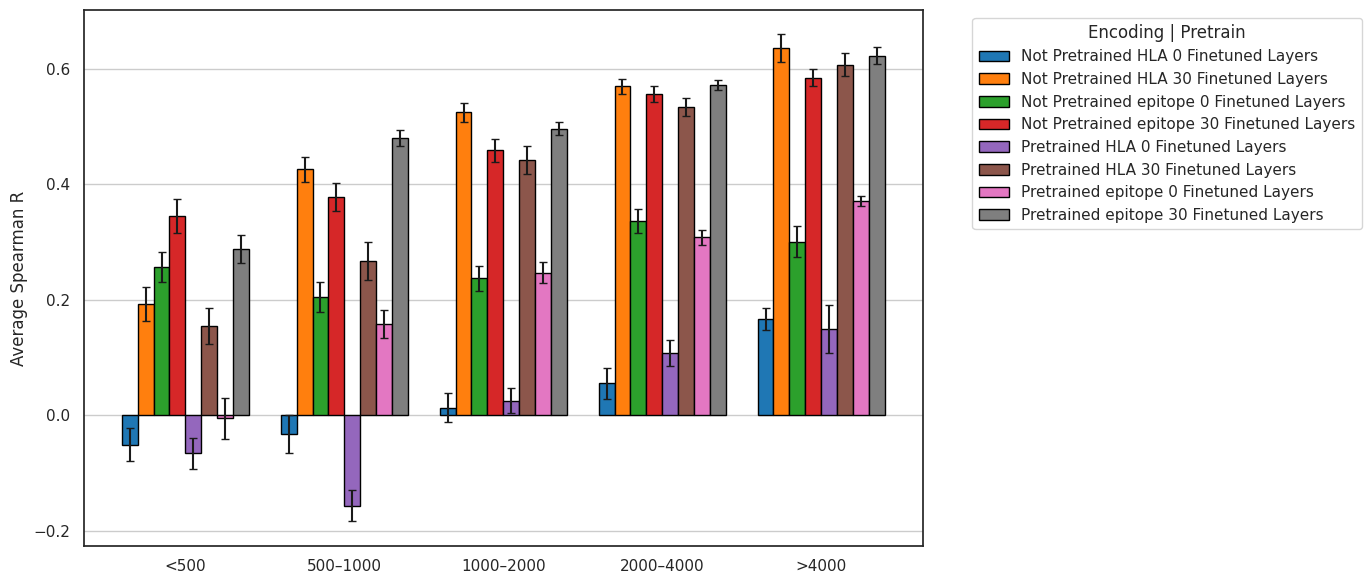

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Bin sizes
bins = [0, 500, 1000, 2000, 4000, np.inf]
labels = ['<500', '500–1000', '1000–2000', '2000–4000', '>4000']
evaluations_dt_plot['size_bin'] = pd.cut(evaluations_dt_plot['training_data'].astype('float'), bins=bins, labels=labels)

# Step 2: Aggregate means and SEM
agg = (
    evaluations_dt_plot[evaluations_dt_plot['spearman'] != 0]
    .groupby(['size_bin', 'encoding', 'pretrain','trained_blocks'])['spearman']
    .agg(['mean', 'count', 'std'])
    .reset_index()
)
agg['sem'] = agg['std'] / np.sqrt(agg['count'])

# Step 3: Build one label for each bar
agg['group_label'] =  agg['pretrain'] + ' ' + agg['encoding'] + ' ' + agg['trained_blocks'].astype('str') + ' Finetuned Layers' #.map({True: 'Pre-trained', False: 'Not pre-trained'})

# Step 4: Get unique bins and group labels
size_bins = agg['size_bin'].unique().tolist()
group_labels = agg['group_label'].unique().tolist()
group_labels = sorted(group_labels)
bar_width = 0.8 / len(group_labels)  # width per bar

# Step 5: Plot
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(size_bins))

# agg = agg.sort_values(by='pretrain')

for i, group in enumerate(group_labels):
    sub_df = agg[agg['group_label'] == group].set_index('size_bin')
    y = sub_df.reindex(size_bins)['mean']
    err = sub_df.reindex(size_bins)['sem']
    
    ax.bar(x + i * bar_width, y, width=bar_width, label=group, yerr=err, capsize=3, 
           alpha=1, edgecolor='black', color=plt.cm.tab10(i % 10))  # Use tab10 colormap for distinct colors

# Step 6: Format plot
ax.set_xticks(x + bar_width * (len(group_labels) - 1) / 2)
ax.set_xticklabels(size_bins)
ax.set_ylabel("Average Spearman R")
# ax.set_title("Effect of Pre-training and Encoding on Spearman R by Dataset Size")
ax.legend(title="Encoding | Pretrain", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [22]:
evaluations_dt_plot['group_label'] = (
    evaluations_dt_plot['pretrain'].map({'Pretrained': 'PT', 'Not Pretrained': 'Non-PT'}) + ' ' +
    evaluations_dt_plot['encoding'].map({'HLA': 'H', 'epitope': 'E'}) + ' ' +
    evaluations_dt_plot['trained_blocks'].map({0: '0L', 30: '30L'})
)



Unique group labels: ['PT H 0L' 'Non-PT H 0L' 'PT E 0L' 'Non-PT E 30L' 'Non-PT E 0L' 'PT H 30L'
 'Non-PT H 30L' 'PT E 30L']


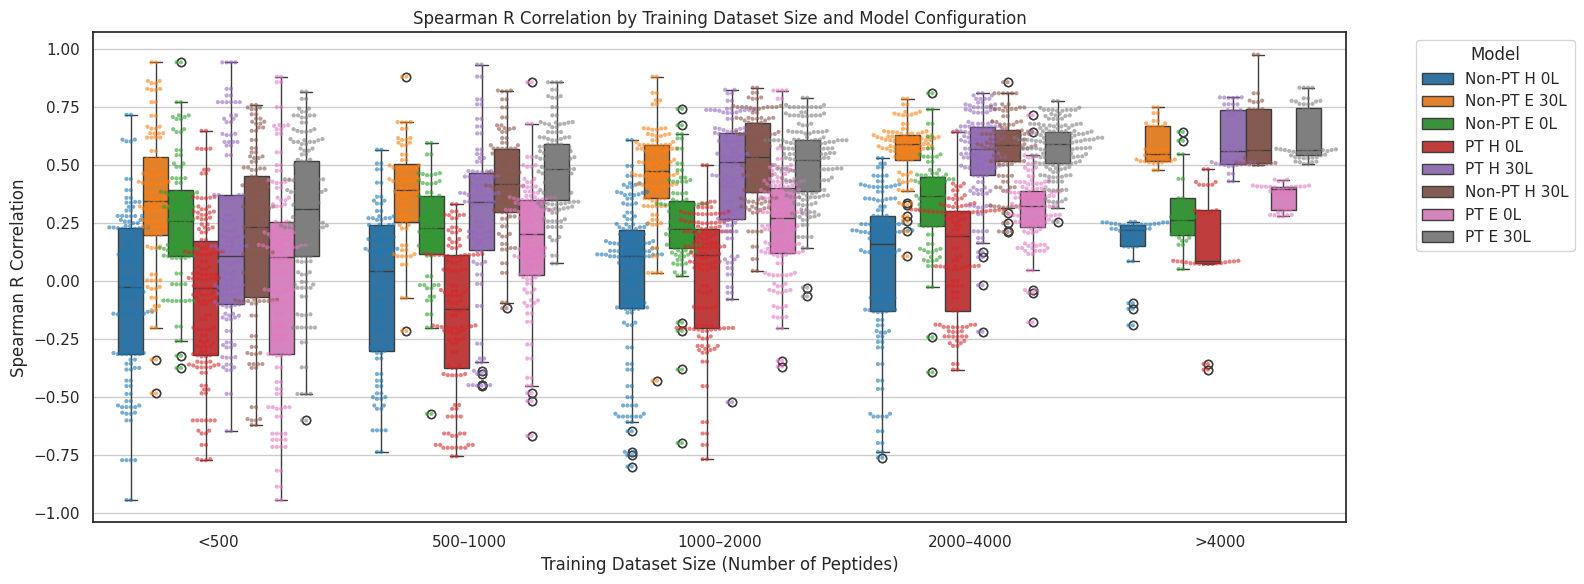

In [23]:
# Verify group_label values to ensure hue is set correctly
print("Unique group labels:", evaluations_dt_plot['group_label'].unique())

plt.figure(figsize=(16, 6))
# Simplified boxplot without boxprops to avoid the error
sns.boxplot(
    data=evaluations_dt_plot[evaluations_dt_plot['spearman'] != 0],
    x='size_bin',
    y='spearman',
    hue='group_label',
    palette='tab10',
    linewidth=1
)
sns.swarmplot(
    data=evaluations_dt_plot[evaluations_dt_plot['spearman'] != 0],
    x='size_bin',
    y='spearman',
    hue='group_label',
    dodge=True,
    size=3,
    alpha=0.6,
    palette='tab10'
)

# Fix overlapping legends (boxplot + swarmplot)
handles, labels = plt.gca().get_legend_handles_labels()
n = len(set(evaluations_dt_plot['group_label']))
plt.legend(handles[:n], labels[:n], bbox_to_anchor=(1.05, 1), loc='upper left', title="Model")

# Improved labels
plt.title("Spearman R Correlation by Training Dataset Size and Model Configuration")
plt.ylabel("Spearman R Correlation")
plt.xlabel("Training Dataset Size (Number of Peptides)")
plt.grid(axis='y')
plt.tight_layout()

# Save the figure with the HLA name in the specified folder (uncomment to use)
# out_dir = Path('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures_manuscript/')
# out_dir.mkdir(parents=True, exist_ok=True)      
# save_path = out_dir / f"fig_performances.pdf"
# fig = plt.gcf()
# fig.savefig(save_path, dpi=300, bbox_inches="tight")
# plt.close(fig)

plt.show()

In [24]:
evaluations_dt_plot['spearman'] = evaluations_dt_plot['spearman'].astype(float)
evaluations_dt_plot['size_bin'] = evaluations_dt_plot['size_bin'].astype(str)

In [25]:
# same aggregation you already had …
stats = (
    evaluations_dt_plot[evaluations_dt_plot['spearman'] != 0]
      .groupby(['size_bin', 'group_label'])['spearman']
      .agg(count  ='size',
           mean   ='mean')
      .reset_index()
)

stats

,size_bin,group_label,count,mean
0,1000–2000,Non-PT E 0L,114,0.237168
1,1000–2000,Non-PT E 30L,116,0.459185
2,1000–2000,Non-PT H 0L,168,0.012957
3,1000–2000,Non-PT H 30L,132,0.525028
4,1000–2000,PT E 0L,166,0.247023
5,1000–2000,PT E 30L,198,0.496661
6,1000–2000,PT H 0L,152,0.025456
7,1000–2000,PT H 30L,124,0.442668
8,2000–4000,Non-PT E 0L,106,0.336809
9,2000–4000,Non-PT E 30L,108,0.556623


In [26]:
# same aggregation you already had …
stats = (
    evaluations_dt_plot[evaluations_dt_plot['spearman'] != 0]
      .groupby(['size_bin', 'group_label'])['pearsonr']
      .agg(count  ='size',
           mean   ='mean')
      .reset_index()
)

stats

,size_bin,group_label,count,mean
0,1000–2000,Non-PT E 0L,114,0.263316
1,1000–2000,Non-PT E 30L,116,0.516684
2,1000–2000,Non-PT H 0L,168,0.046976
3,1000–2000,Non-PT H 30L,132,0.565711
4,1000–2000,PT E 0L,166,0.312647
5,1000–2000,PT E 30L,198,0.536533
6,1000–2000,PT H 0L,152,-0.007155
7,1000–2000,PT H 30L,124,0.502174
8,2000–4000,Non-PT E 0L,106,0.356562
9,2000–4000,Non-PT E 30L,108,0.616842


/tmp/ipykernel_1547190/1003824573.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1547190/1003824573.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1547190/1003824573.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1547190/1003824573.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1547190/1003824573.py:22: Fut

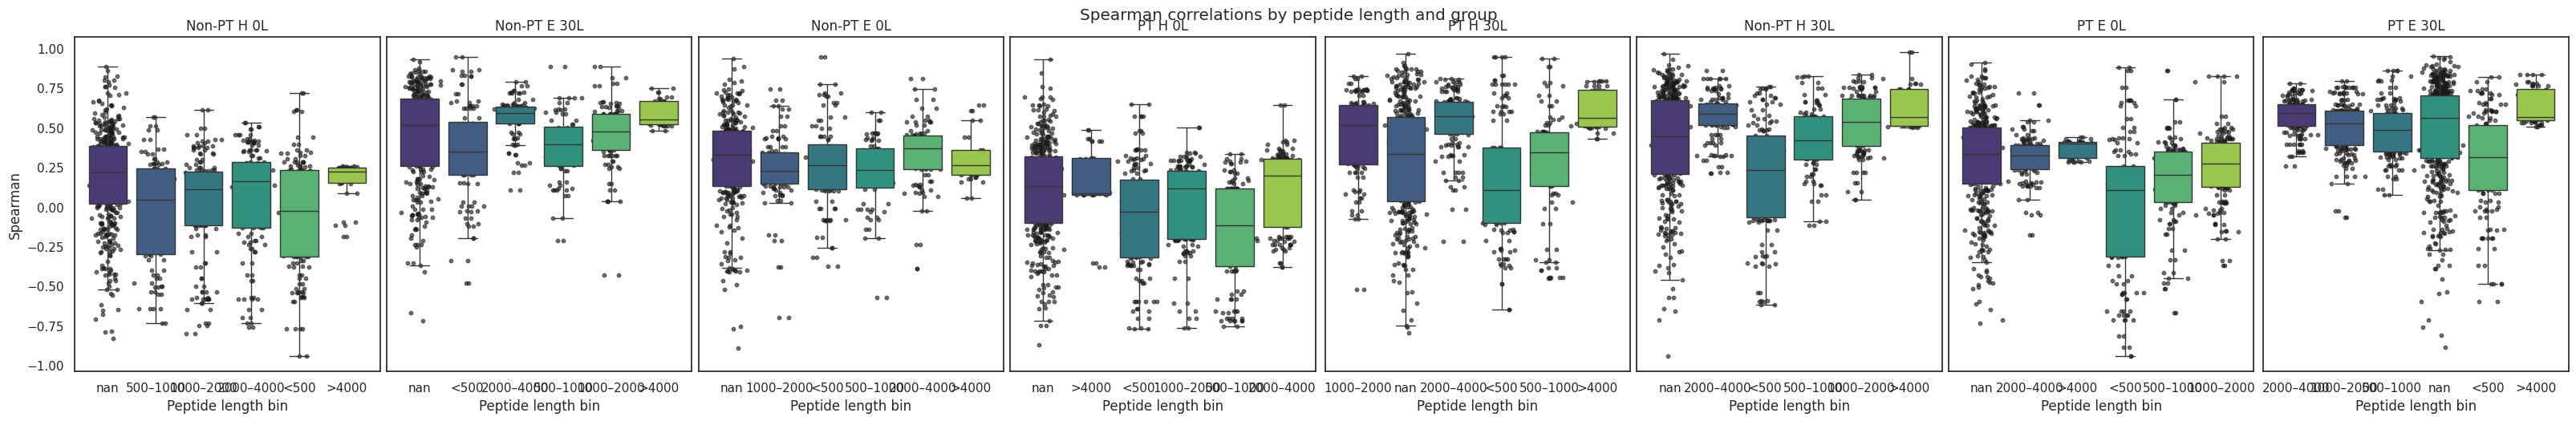

In [27]:
df_plot = evaluations_dt_plot[evaluations_dt_plot["spearman"] != 0]

# discover the groups in your data
groups = df_plot["group_label"].unique()
n_panels = len(groups)

fig, axes = plt.subplots(
    nrows=1,
    ncols=n_panels,
    figsize=(4 * n_panels, 5),
    sharey=True,
    constrained_layout=True,
)

if n_panels == 1:
    axes = [axes]      # make iterable when only one group

for ax, grp in zip(axes, groups):
    sub = df_plot[df_plot["group_label"] == grp]

    # main box plot
    sns.boxplot(
        data=sub,
        x="size_bin",
        y="spearman",
        ax=ax,
        palette="viridis",
        showfliers=False,
    )

    # jittered scatter overlay for each size_bin
    rng = np.random.default_rng(seed=42)
    jitter = 0.15
    for i, bin_name in enumerate(sub["size_bin"].unique()):
        y_vals = sub.loc[sub["size_bin"] == bin_name, "spearman"].values
        x_vals = rng.normal(loc=i, scale=jitter, size=len(y_vals))
        ax.scatter(x_vals, y_vals, color="k", s=10, alpha=0.6)

    ax.set_title(grp)
    ax.set_xlabel("Peptide length bin")
    ax.set_ylabel("Spearman" if ax is axes[0] else "")

plt.suptitle("Spearman correlations by peptide length and group", y=1.02)
plt.show()

In [28]:
evaluations_dt_plot.head()

,HLA,training_data,Losses,encoding,data_prop,trained_blocks,lr_transformer,lr_regression,n_evaluations,spearman,pearsonr,mse,mae,r2,rmse,time,path,Model,rank_mse,rank_corr,rank_sum,pretrain,size_bin,group_label
0,A0206,1181.2,Hubber,HLA,0.2,0,0.0001,0.0001,2,0.000000,0.000000,3.504787,1.868205,-298.601082,1.872108,2025-05-28 10:13:50,/global/scratch/users/sergiomar10/losses/ESMCB...,A0206 HLA,34.0,24.5,58.5,Pretrained,1000–2000,PT H 0L
1,A0206,1181.2,Hubber,HLA,0.2,0,0.0001,0.0001,2,0.000000,0.000000,3.504787,1.868205,-298.601082,1.872108,2025-05-28 10:13:50,/global/scratch/users/sergiomar10/losses/ESMCB...,A0206 HLA,34.0,24.5,58.5,Pretrained,1000–2000,PT H 0L
2,B1503,NaN,Hubber,HLA,0.6,0,NaN,2.0000,17,-0.223039,-0.039374,1.016435,0.793096,-0.040558,1.008184,2025-05-29 05:46:41,/global/scratch/users/sergiomar10/losses/ESMCB...,B1503 HLA,34.0,49.0,83.0,Not Pretrained,nan,Non-PT H 0L
3,B2704,NaN,Hubber,epitope,0.6,0,0.0001,0.0001,2,0.000000,0.000000,0.246127,0.357383,-1.150524,0.496111,2025-05-28 21:16:04,/global/scratch/users/sergiomar10/losses/ESMCB...,B2704 epitope,14.0,20.0,34.0,Pretrained,nan,PT E 0L
4,C1402,NaN,Hubber,epitope,0.8,30,NaN,5.0000,17,0.267157,0.430959,0.284107,0.419501,0.100739,0.533017,2025-05-28 12:53:07,/global/scratch/users/sergiomar10/losses/ESMCB...,C1402 epitope,7.0,31.0,38.0,Not Pretrained,nan,Non-PT E 30L


In [29]:
evaluations_dt_plot2 = evaluations_dt_plot[evaluations_dt_plot['n_evaluations'] > 100]

In [30]:
import numpy as np
import pandas as pd
from scipy.stats import t              # Student-t for the CI

# same aggregation you already had …
stats = (
    evaluations_dt_plot2 #[evaluations_dt_plot['spearman'] != 0]
      .groupby(['size_bin', 'group_label'])['spearman']
      .agg(count  ='size',
           mean   ='mean',
           std    ='std')
      .reset_index()
)

# standard error
stats['sem'] = stats['std'] / np.sqrt(stats['count'])

# 95 % CI for the mean:  mean ± t_(α/2, df) * sem
alpha  = 0.05
stats['ci_low']  = stats['mean'] - t.ppf(1-alpha/2, stats['count']-1) * stats['sem']
stats['ci_high'] = stats['mean'] + t.ppf(1-alpha/2, stats['count']-1) * stats['sem']

# Optional: round or re-order columns
stats = stats[['size_bin','group_label','count','mean','ci_low','ci_high']]
stats

,size_bin,group_label,count,mean,ci_low,ci_high
0,1000–2000,Non-PT E 0L,36,0.231134,0.194601,0.267667
1,1000–2000,Non-PT E 30L,36,0.461521,0.422930,0.500111
2,1000–2000,Non-PT H 0L,52,0.100802,0.056260,0.145344
3,1000–2000,Non-PT H 30L,40,0.486746,0.444716,0.528776
4,1000–2000,PT E 0L,50,0.233327,0.207258,0.259395
5,1000–2000,PT E 30L,62,0.484849,0.453337,0.516361
6,1000–2000,PT H 0L,48,0.065849,0.003774,0.127923
7,1000–2000,PT H 30L,36,0.464389,0.385230,0.543549
8,2000–4000,Non-PT E 0L,48,0.309728,0.271146,0.348310
9,2000–4000,Non-PT E 30L,48,0.576603,0.546638,0.606569


In [31]:
import numpy as np
import pandas as pd
from scipy.stats import t              # Student-t for the CI

# same aggregation you already had …
stats = (
    evaluations_dt_plot2[evaluations_dt_plot2['spearman'] != 0]
      .groupby(['size_bin', 'group_label'])['spearman']
      .agg(count  ='size',
           mean   ='mean',
           std    ='std')
      .reset_index()
)

# standard error
stats['sem'] = stats['std'] / np.sqrt(stats['count'])

# 95 % CI for the mean:  mean ± t_(α/2, df) * sem
alpha  = 0.05
stats['ci_low']  = stats['mean'] - t.ppf(1-alpha/2, stats['count']-1) * stats['sem']
stats['ci_high'] = stats['mean'] + t.ppf(1-alpha/2, stats['count']-1) * stats['sem']

# Optional: round or re-order columns
stats = stats[['size_bin','group_label','count','mean','ci_low','ci_high']]
stats.T


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47
size_bin,1000–2000,1000–2000,1000–2000,1000–2000,1000–2000,1000–2000,1000–2000,1000–2000,2000–4000,2000–4000,2000–4000,2000–4000,2000–4000,2000–4000,2000–4000,2000–4000,500–1000,500–1000,500–1000,500–1000,500–1000,500–1000,500–1000,500–1000,<500,<500,<500,<500,<500,<500,<500,<500,>4000,>4000,>4000,>4000,>4000,>4000,>4000,>4000,nan,nan,nan,nan,nan,nan,nan,nan
group_label,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L
count,36,36,52,40,50,62,48,36,48,48,64,58,70,82,70,68,16,16,20,24,28,32,26,20,8,8,10,12,16,14,10,6,32,32,38,32,30,52,30,38,14,14,19,18,19,25,19,22
mean,0.231134,0.461521,0.100802,0.486746,0.233327,0.484849,0.065849,0.464389,0.309728,0.576603,0.171764,0.559574,0.286572,0.572495,0.134286,0.586558,0.307119,0.402355,0.056088,0.375819,0.159786,0.45661,0.068133,0.363255,0.163397,0.299101,0.008697,0.306237,0.152247,0.296593,0.19091,0.172746,0.276178,0.573621,0.21469,0.604478,0.376361,0.606798,0.218897,0.591397,0.39427,0.774798,0.336545,0.785518,0.423768,0.772874,0.199708,0.75827
ci_low,0.194601,0.42293,0.05626,0.444716,0.207258,0.453337,0.003774,0.38523,0.271146,0.546638,0.124295,0.528145,0.264913,0.549616,0.083077,0.555133,0.241939,0.349067,-0.05727,0.310587,0.107795,0.42017,-0.013421,0.272472,0.126587,0.262407,-0.078788,0.245652,0.124757,0.268403,0.13121,0.143827,0.225288,0.544119,0.19998,0.564751,0.356303,0.579932,0.159704,0.551406,0.347265,0.726652,0.29208,0.744821,0.389946,0.735015,0.151476,0.710722
ci_high,0.267667,0.500111,0.145344,0.528776,0.259395,0.516361,0.127923,0.543549,0.34831,0.606569,0.219233,0.591003,0.308231,0.595375,0.185494,0.617983,0.372298,0.455644,0.169447,0.441052,0.211777,0.49305,0.149686,0.454039,0.200206,0.335796,0.096181,0.366821,0.179736,0.324783,0.25061,0.201666,0.327067,0.603122,0.229399,0.644205,0.396419,0.633664,0.27809,0.631388,0.441275,0.822943,0.38101,0.826215,0.45759,0.810733,0.24794,0.805818


In [32]:
stats[['size_bin', 'group_label', 'mean']].T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47
size_bin,1000–2000,1000–2000,1000–2000,1000–2000,1000–2000,1000–2000,1000–2000,1000–2000,2000–4000,2000–4000,2000–4000,2000–4000,2000–4000,2000–4000,2000–4000,2000–4000,500–1000,500–1000,500–1000,500–1000,500–1000,500–1000,500–1000,500–1000,<500,<500,<500,<500,<500,<500,<500,<500,>4000,>4000,>4000,>4000,>4000,>4000,>4000,>4000,nan,nan,nan,nan,nan,nan,nan,nan
group_label,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L
mean,0.231134,0.461521,0.100802,0.486746,0.233327,0.484849,0.065849,0.464389,0.309728,0.576603,0.171764,0.559574,0.286572,0.572495,0.134286,0.586558,0.307119,0.402355,0.056088,0.375819,0.159786,0.45661,0.068133,0.363255,0.163397,0.299101,0.008697,0.306237,0.152247,0.296593,0.19091,0.172746,0.276178,0.573621,0.21469,0.604478,0.376361,0.606798,0.218897,0.591397,0.39427,0.774798,0.336545,0.785518,0.423768,0.772874,0.199708,0.75827


In [33]:
import numpy as np
import pandas as pd
from scipy.stats import t              # Student-t for the CI

# same aggregation you already had …
stats = (
    evaluations_dt_plot2[evaluations_dt_plot2['spearman'] != 0]
      .groupby(['size_bin', 'group_label'])['pearsonr']
      .agg(count  ='size',
           mean   ='mean',
           std    ='std')
      .reset_index()
)

# standard error
stats['sem'] = stats['std'] / np.sqrt(stats['count'])

# 95 % CI for the mean:  mean ± t_(α/2, df) * sem
alpha  = 0.05
stats['ci_low']  = stats['mean'] - t.ppf(1-alpha/2, stats['count']-1) * stats['sem']
stats['ci_high'] = stats['mean'] + t.ppf(1-alpha/2, stats['count']-1) * stats['sem']

# Optional: round or re-order columns
stats = stats[['size_bin','group_label','count','mean','ci_low','ci_high']]
stats.T


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47
size_bin,1000–2000,1000–2000,1000–2000,1000–2000,1000–2000,1000–2000,1000–2000,1000–2000,2000–4000,2000–4000,2000–4000,2000–4000,2000–4000,2000–4000,2000–4000,2000–4000,500–1000,500–1000,500–1000,500–1000,500–1000,500–1000,500–1000,500–1000,<500,<500,<500,<500,<500,<500,<500,<500,>4000,>4000,>4000,>4000,>4000,>4000,>4000,>4000,nan,nan,nan,nan,nan,nan,nan,nan
group_label,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L
count,36,36,52,40,50,62,48,36,48,48,64,58,70,82,70,68,16,16,20,24,28,32,26,20,8,8,10,12,16,14,10,6,32,32,38,32,30,52,30,38,14,14,19,18,19,25,19,22
mean,0.235213,0.455026,0.111671,0.47443,0.23356,0.476168,0.050435,0.464523,0.31163,0.577222,0.179622,0.577948,0.290757,0.572197,0.114152,0.591282,0.320858,0.409135,0.064988,0.393221,0.163607,0.461745,0.061877,0.363725,0.176416,0.291177,0.001461,0.292487,0.150797,0.281335,0.206553,0.150166,0.258499,0.561205,0.210814,0.586075,0.362422,0.586271,0.19838,0.57118,0.393559,0.766107,0.340622,0.77524,0.418716,0.757843,0.213151,0.746172
ci_low,0.194429,0.413781,0.063548,0.423628,0.204034,0.439569,-0.012957,0.381956,0.271611,0.54394,0.124958,0.540128,0.264249,0.544442,0.062701,0.55534,0.247261,0.346606,-0.056233,0.317854,0.103865,0.415021,-0.025542,0.271081,0.122544,0.241445,-0.049912,0.218137,0.123706,0.252081,0.14644,0.120349,0.208365,0.530864,0.190722,0.545583,0.341919,0.558669,0.150827,0.531688,0.34622,0.724877,0.299891,0.736141,0.385884,0.723837,0.166359,0.702293
ci_high,0.275997,0.49627,0.159793,0.525232,0.263086,0.512767,0.113828,0.547091,0.351649,0.610504,0.234285,0.615769,0.317266,0.599951,0.165602,0.627224,0.394456,0.471664,0.186208,0.468588,0.223349,0.508469,0.149296,0.456368,0.230288,0.340908,0.052834,0.366837,0.177889,0.310588,0.266666,0.179983,0.308632,0.591545,0.230906,0.626568,0.382926,0.613873,0.245934,0.610671,0.440898,0.807337,0.381352,0.814338,0.451548,0.791848,0.259942,0.790051


In [34]:
# sns.set(style="white")

# # Plotting
# plt.figure(figsize=(8, 6))
# # sns.lineplot(data=evaluations_dt_plot[(evaluations_dt_plot['training_data'].notna()) & (evaluations_dt_plot['trained_blocks'] == '30')], x="training_data", y="spearman", hue="HLA", size= 'encoding', marker="o", palette="tab20")
# plt.title("Spearman Correlation vs Data Proportion for Each Model")
# plt.xlabel("Data Proportion")
# plt.ylabel("Spearman Correlation")
# plt.xscale('log')
# plt.tight_layout()
# plt.legend(title='HLA', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.show()

/tmp/ipykernel_1547190/2275976583.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=evaluations_dt_plot[(evaluations_dt_plot['training_data'].notna()) & (evaluations_dt_plot['trained_blocks'] == '0')], x="training_data", y="spearman", hue="HLA", size= 'encoding', marker="o", palette="tab20")


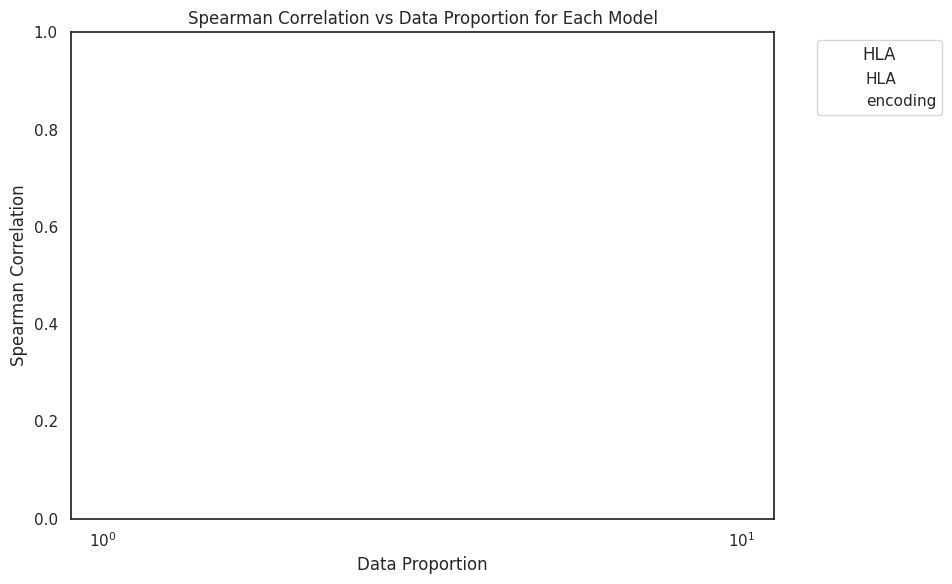

In [35]:
sns.set(style="white")

# Plotting
plt.figure(figsize=(8, 6))
sns.lineplot(data=evaluations_dt_plot[(evaluations_dt_plot['training_data'].notna()) & (evaluations_dt_plot['trained_blocks'] == '0')], x="training_data", y="spearman", hue="HLA", size= 'encoding', marker="o", palette="tab20")
plt.title("Spearman Correlation vs Data Proportion for Each Model")
plt.xlabel("Data Proportion")
plt.ylabel("Spearman Correlation")
plt.xscale('log')
plt.tight_layout()
plt.legend(title='HLA', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Recompute the spearman and pearson without the duplicates of the training data

In [36]:
results = []
test_datasets_list = []

# Get unique Model alleles
alleles = evaluations_dt_sorted['Model'].unique()

for allele in alleles:
    # Load training data for the current allele
    formatted_Model = allele.split(' ')[0] #.replace('*', '').replace(':', '')  # e.g., ModelB0801
    train_fasta = f"/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLA{formatted_Model}_final.csv"
    epitope_data = pd.read_csv(train_fasta, header=None)
    epitope_data.columns = ['sequence', 'ref_ID', 'submissionID', 'Epitope_ID', 'protein_origin', 
                            'ID_SOURCE', 'SOURCE_ORGANISM', 'IC50_nM', 'DESCRIPTION_BINDING', 'Year_submission']
    
    # Clean and filter the training data
    epitope_data['Year_submission'] = epitope_data['Year_submission'].astype(str).replace('\\N', '0').astype(int)
    epitope_data = epitope_data[epitope_data["Year_submission"] < 2019]

    # Load test data for the current allele
    test_path = evaluations_dt_sorted[evaluations_dt_sorted['Model'] == allele]['path'].values[0]
    test_dataset = pd.read_csv(test_path)
    
    # Remove training sequences from the test data
    test_dataset = test_dataset[~test_dataset['sequence'].isin(epitope_data['sequence'])]
    
    # If the filtered test dataset is empty, skip this allele
    if test_dataset.empty:
        continue

    # Store the test dataset with an added column for Model
    test_dataset = test_dataset.copy()  # Ensure we're not modifying the original DataFrame unexpectedly
    test_dataset['Model'] = allele
    test_datasets_list.append(test_dataset)
    
    # Only compute metrics if there is more than one sample
    if len(test_dataset) > 1:
        spearman_val = spearmanr(test_dataset['measured'], test_dataset['prediction'])[0]
        pearson_val = pearsonr(test_dataset['measured'], test_dataset['prediction'])[0]
        mse_val = mean_squared_error(test_dataset['measured'], test_dataset['prediction'])
        
        # Format to 2 significant figures
        spearman_str = f"{spearman_val:.2g}"
        pearson_str = f"{pearson_val:.2g}"
        mse_str = f"{mse_val:.2g}"
        
        results.append({
            "Model": allele,
            "HLA" : formatted_Model, 
            "spearman": spearman_str,
            "pearsonr": pearson_str,
            "mse": mse_str,
            "test_size": len(test_dataset),
            "path": test_path,
            "training_data": len(epitope_data)
        })

# Create a DataFrame with the metrics results
metrics_df = pd.DataFrame(results)

# Concatenate all test datasets into a single DataFrame
if test_datasets_list:
    test_datasets_df = pd.concat(test_datasets_list, ignore_index=True)
else:
    test_datasets_df = pd.DataFrame()  # empty DataFrame if no test datasets were stored

# Now you have:
# - metrics_df: contains the computed metrics for each Model allele.
# - test_datasets_df: contains all the filtered test datasets with an Model identifier.


In [37]:
# pd.merge(left=metrics_df, right=evaluations_dt_sorted[['HLA','time','rank_mse','rank_corr', 'rank_sum']], on='HLA', how='left').sort_values(by='time').reset_index(drop=True)

### Reported Evaluation from the Training Held out dataset

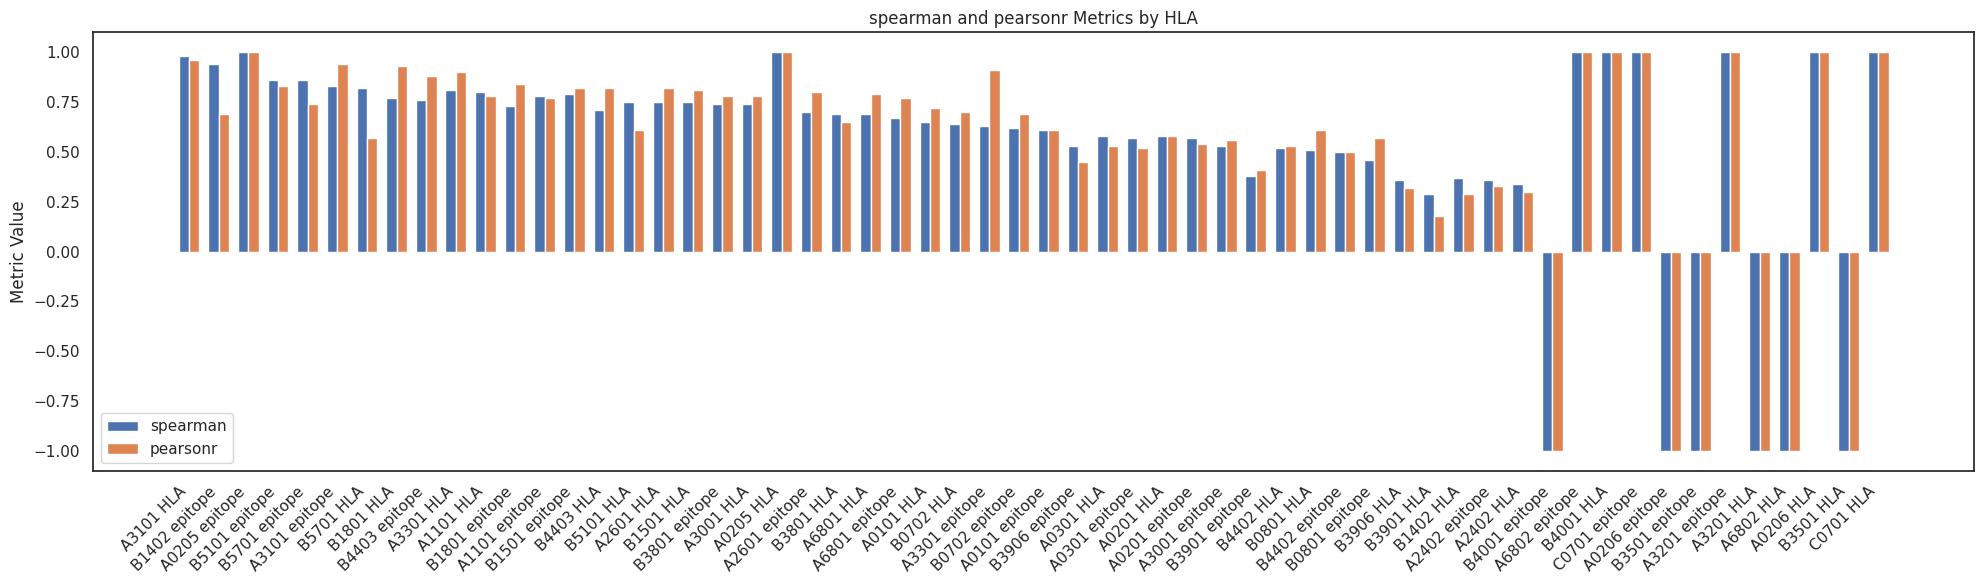

In [38]:
metrics_df['spearman'] = metrics_df['spearman'].astype(float)
metrics_df['pearsonr'] = metrics_df['pearsonr'].astype(float)

# Prepare data for plotting
hla_labels = metrics_df['Model']
spearman_vals = metrics_df['spearman']
pearsonr_vals = metrics_df['pearsonr']

x = np.arange(len(hla_labels))  # label positions
width = 0.35  # width of the bars

# Create the plot
fig, ax = plt.subplots(figsize=(20, 6))
rects1 = ax.bar(x - width/2, spearman_vals, width, label='spearman')
rects2 = ax.bar(x + width/2, pearsonr_vals, width, label='pearsonr')

# Customization: labels and title
ax.set_ylabel('Metric Value')
ax.set_title('spearman and pearsonr Metrics by HLA')
ax.set_xticks(x)
ax.set_xticklabels(hla_labels, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

In [39]:
metrics_df['mse'] = metrics_df['mse'].astype(float)

In [40]:
metrics_df['encoding'] = metrics_df['Model'].str.split(' ', expand = True)[1]

In [41]:
metrics_df.sort_values(by='training_data', ascending=False)

,Model,HLA,spearman,pearsonr,mse,test_size,path,training_data,encoding
34,A0201 epitope,A0201,0.57,0.54,1.700,472,/global/scratch/users/sergiomar10/losses/ESMCB...,16550,epitope
33,A0201 HLA,A0201,0.58,0.58,1.800,472,/global/scratch/users/sergiomar10/losses/ESMCB...,16550,HLA
54,A6802 HLA,A6802,-1.00,-1.00,0.120,2,/global/scratch/users/sergiomar10/losses/ESMCB...,6622,HLA
47,A6802 epitope,A6802,1.00,1.00,1.300,2,/global/scratch/users/sergiomar10/losses/ESMCB...,6622,epitope
32,A0301 epitope,A0301,0.57,0.52,1.800,220,/global/scratch/users/sergiomar10/losses/ESMCB...,6278,epitope
31,A0301 HLA,A0301,0.58,0.53,2.000,220,/global/scratch/users/sergiomar10/losses/ESMCB...,6278,HLA
55,A0206 HLA,A0206,1.00,1.00,0.170,2,/global/scratch/users/sergiomar10/losses/ESMCB...,5906,HLA
50,A0206 epitope,A0206,-1.00,-1.00,0.190,2,/global/scratch/users/sergiomar10/losses/ESMCB...,5906,epitope
10,A1101 HLA,A1101,0.80,0.78,0.780,107,/global/scratch/users/sergiomar10/losses/ESMCB...,5717,HLA
12,A1101 epitope,A1101,0.78,0.77,0.770,107,/global/scratch/users/sergiomar10/losses/ESMCB...,5717,epitope


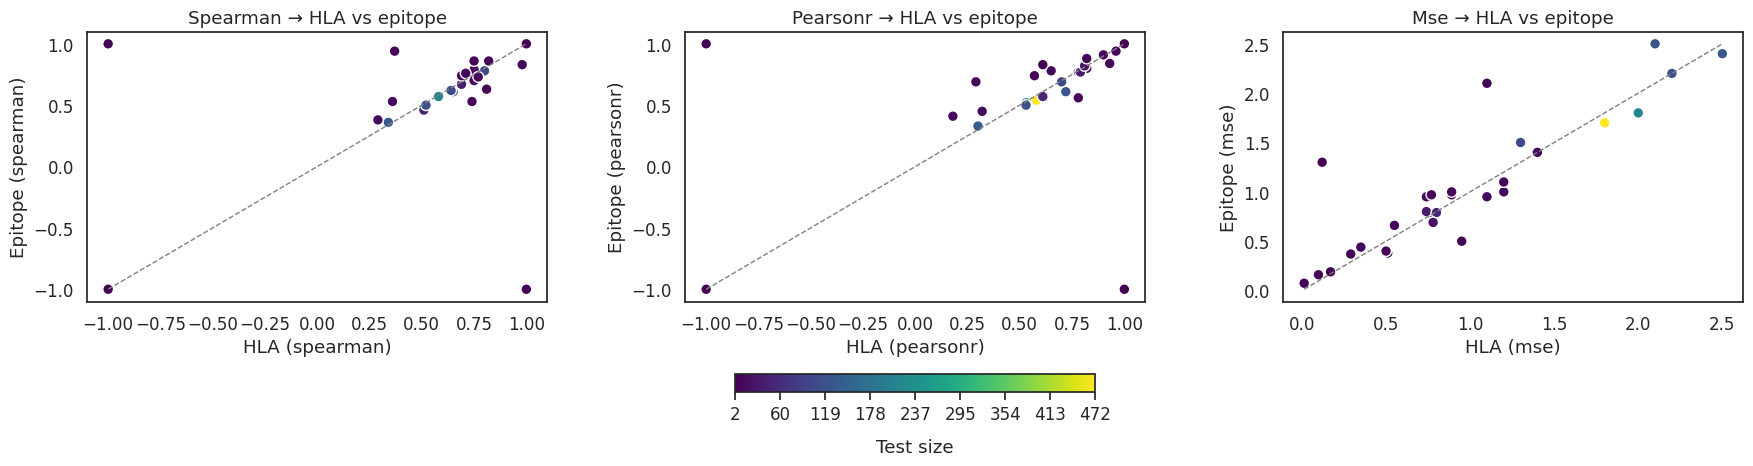

In [42]:
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Build the pivots without aggregation errors
keys    = ['HLA', 'test_size', 'training_data']
metrics = ['spearman','pearsonr','mse']
pivots  = {}

for m in metrics:
    pivots[m] = (
        metrics_df
          .pivot(
             index=keys,
             columns='encoding',
             values=m
          )
          .dropna()  # only keep combos where both encodings exist
          .rename(columns={
              'HLA':     'HLA_val',
              'epitope': 'epitope_val'
           })
          .reset_index()
    )

# 2) Set up normalization & colormap
norm = Normalize(
    vmin=metrics_df['test_size'].min(),
    vmax=metrics_df['test_size'].max()
)
cmap = plt.cm.viridis

# 3) Plot
sns.set(style='white', font_scale=1.1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False, sharey=False)

for ax, m in zip(axes, metrics):
    pv = pivots[m]
    sc = ax.scatter(
        pv['HLA_val'], pv['epitope_val'],
        c=pv['test_size'], cmap=cmap, norm=norm,
        s=60, edgecolor='w'
    )

    # diagonal
    mn = min(pv['HLA_val'].min(), pv['epitope_val'].min())
    mx = max(pv['HLA_val'].max(), pv['epitope_val'].max())
    ax.plot([mn, mx], [mn, mx], '--', color='gray', lw=1)

    ax.set_title(f"{m.capitalize()} → HLA vs epitope")
    ax.set_xlabel(f"HLA ({m})")
    ax.set_ylabel(f"Epitope ({m})")

# 4) Adjust layout so nothing overlaps
fig.subplots_adjust(left=0.05, right=0.97, top=0.90, bottom=0.18, wspace=0.3)

# 5) Single horizontal colorbar underneath
cbar = fig.colorbar(
    sc, ax=axes.tolist(),
    orientation='horizontal',
    fraction=0.05,
    pad=0.2
)
# more granular ticks
levels = np.linspace(norm.vmin, norm.vmax, 9)
cbar.set_ticks(levels)
cbar.set_ticklabels([int(v) for v in levels])
cbar.set_label('Test size', labelpad=11)

plt.show()


In [43]:
import glob
import pandas as pd
import os
from collections import defaultdict

# Directory containing benchmark results
csv_dir = '/global/scratch/users/sergiomar10/data/benchmark_02062025'
files_to_process = glob.glob(os.path.join(csv_dir, '*.csv'))

# Dictionary of allele → list of DataFrames
allele_frames = defaultdict(list)
metadata_records = []

# Loop through all CSV files
for test_f in files_to_process:
    fname = os.path.basename(test_f)

    # Example filename:
    # A6801-ESMCBA_epitope_0.2_30_ESMMASK_epitope_FT_...csv

    try:
        df = pd.read_csv(test_f)
    except Exception as e:
        print(f"❌ Error reading {fname}: {e}")
        continue

    if 'sequence' not in df.columns or 'prediction' not in df.columns:
        print(f"⚠️ Skipping {fname} (missing 'sequence' or 'prediction')")
        continue

    # Extract metadata components
    allele = fname.split('-')[0]                               # e.g., A6801
    pretrained = not ('False-Full_pretraining' in fname)       # True if not explicitly False
    encoding = 'HLA' if '_HLA_' in fname else 'epitope'        # infer from filename
    finetune_depth = 30 if '_30_' in fname else 0              # infer fine-tuning depth

    # Append metadata row
    metadata_records.append({
        'file_name': fname,
        'allele': allele,
        'pretrained': pretrained,
        'encoding': encoding,
        'finetune_depth': finetune_depth
    })

    # Rename prediction column to filename and keep sequence
    renamed = df[['sequence', 'prediction']].copy()
    renamed.columns = ['sequence', fname]  # Label prediction column with filename
    allele_frames[allele].append(renamed)

# Merge prediction DataFrames and finalize metadata
combined_by_allele = {}
metadata_df = pd.DataFrame(metadata_records)

for allele, dfs in allele_frames.items():
    print(f"🔗 Combining {len(dfs)} files for allele {allele}")
    df_merged = dfs[0]
    for df in dfs[1:]:
        df_merged = df_merged.merge(df, on='sequence', how='outer')

    combined_by_allele[allele] = df_merged
    print(f"✅ Combined shape for {allele}: {df_merged.shape}")

# Save example
# combined_by_allele['A6801'].to_csv('A6801_merged_predictions.csv', index=False)
# metadata_df.to_csv('metadata_table.csv', index=False)


🔗 Combining 12 files for allele A0201
✅ Combined shape for A0201: (488, 13)
🔗 Combining 12 files for allele B0702
✅ Combined shape for B0702: (109, 13)
🔗 Combining 12 files for allele A2601
✅ Combined shape for A2601: (15, 13)
🔗 Combining 10 files for allele B0801
✅ Combined shape for B0801: (53, 11)
🔗 Combining 12 files for allele B1801
✅ Combined shape for B1801: (12, 13)
🔗 Combining 12 files for allele A3001
✅ Combined shape for A3001: (10, 13)
🔗 Combining 12 files for allele A0101
✅ Combined shape for A0101: (128, 13)
🔗 Combining 12 files for allele A6801
✅ Combined shape for A6801: (38, 13)
🔗 Combining 8 files for allele A3101
✅ Combined shape for A3101: (8, 9)
🔗 Combining 12 files for allele B4402
✅ Combined shape for B4402: (117, 13)
🔗 Combining 12 files for allele A0301
✅ Combined shape for A0301: (218, 13)
🔗 Combining 11 files for allele B3801
✅ Combined shape for B3801: (12, 12)
🔗 Combining 7 files for allele B3906
✅ Combined shape for B3906: (13, 8)
🔗 Combining 12 files for 

In [44]:
for allele, dfs in allele_frames.items():
    print(f"🔗 Combining {len(dfs)} files for allele {allele}")
    df_merged = dfs[0]
    for df in dfs[1:]:
        df_merged = df_merged.merge(df, on='sequence', how='outer')

    # Append measured IC50 values (if available)
    try:
        file_path = f"/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLA{allele}_final.csv"
        epitope_data = pd.read_csv(file_path, header=None)
        epitope_data.columns = [
            'sequence', 'ref_ID', 'submissionID', 'Epitope_ID', 'protein_origin',
            'ID_SOURCE', 'SOURCE_ORGANISM', 'IC50_nM', 'DESCRIPTION_BINDING', 'Year_submission'
        ]

        epitope_data['Year_submission'] = epitope_data['Year_submission'].astype(str).replace('\\N', '0').astype(int)
        epitope_data = epitope_data[epitope_data['Year_submission'] > 2019]
        epitope_data['IC50_nM'] =  epitope_data['IC50_nM'].astype(str).replace('\\N', '0').astype(float) + 1
        epitope_data['IC50_nM'] =  epitope_data['IC50_nM'].apply(np.log10)
        
        ic50_df = (
            epitope_data[['sequence', 'IC50_nM']]
            .dropna()
            .sort_values('IC50_nM')
            .drop_duplicates(subset='sequence', keep='first')
            .copy()
        )
        ic50_df.columns = ['sequence', 'measured']
        df_merged = df_merged.merge(ic50_df, on='sequence', how='left')
        print(f"📏 Added measured IC50s to {allele}: {ic50_df.shape[0]} entries")

    except Exception as e:
        print(f"❌ Could not load IC50 for {allele}: {e}")

    combined_by_allele[allele] = df_merged
    print(f"✅ Combined shape for {allele}: {df_merged.shape}")



🔗 Combining 12 files for allele A0201
📏 Added measured IC50s to A0201: 518 entries
✅ Combined shape for A0201: (488, 14)
🔗 Combining 12 files for allele B0702
📏 Added measured IC50s to B0702: 115 entries
✅ Combined shape for B0702: (109, 14)
🔗 Combining 12 files for allele A2601
📏 Added measured IC50s to A2601: 17 entries
✅ Combined shape for A2601: (15, 14)
🔗 Combining 10 files for allele B0801
📏 Added measured IC50s to B0801: 53 entries
✅ Combined shape for B0801: (53, 12)
🔗 Combining 12 files for allele B1801
📏 Added measured IC50s to B1801: 12 entries
✅ Combined shape for B1801: (12, 14)
🔗 Combining 12 files for allele A3001
📏 Added measured IC50s to A3001: 10 entries
✅ Combined shape for A3001: (10, 14)
🔗 Combining 12 files for allele A0101
📏 Added measured IC50s to A0101: 128 entries
✅ Combined shape for A0101: (128, 14)
🔗 Combining 12 files for allele A6801
📏 Added measured IC50s to A6801: 39 entries
✅ Combined shape for A6801: (38, 14)
🔗 Combining 8 files for allele A3101
📏 Add

In [45]:
from scipy.stats import spearmanr, pearsonr

perf_records = []

# Loop through alleles
for allele, df in combined_by_allele.items():
    # Columns: sequence, measured, [model predictions...]
    if 'measured' not in df.columns:
        continue

    for col in df.columns:
        if col in ['sequence', 'measured']:
            continue

        # Drop missing
        sub = df[['measured', col]].dropna()
        if sub.shape[0] < 10:
            continue

        rho, _ = spearmanr(sub['measured'], sub[col])
        r, _ = pearsonr(sub['measured'], sub[col])

        # Pull metadata
        meta = metadata_df[metadata_df['file_name'] == col].iloc[0]

        perf_records.append({
            'allele': allele,
            'model_file': col,
            'encoding': meta['encoding'],
            'pretrained': meta['pretrained'],
            'finetune_depth': meta['finetune_depth'],
            'spearman': rho,
            'pearson': r,
        })

perf_df = pd.DataFrame(perf_records)


In [46]:
perf_df = perf_df[perf_df['finetune_depth'] == 30].sort_values(by='spearman', ascending=False)
 

In [47]:
perf_df['data_size'] = perf_df['model_file'].str.split('_',expand = True)[2]

<Axes: >

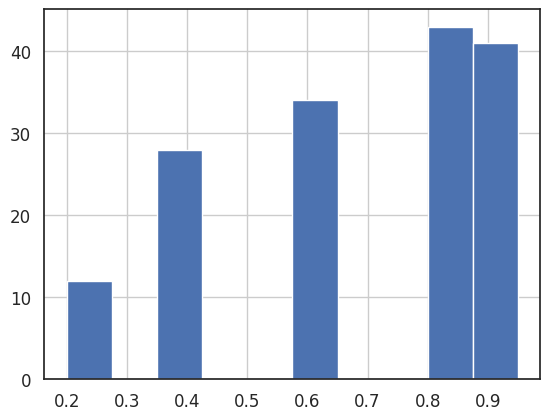

In [48]:
perf_df['data_size'].astype('float').hist()

KeyError: "['measured'] not in index"

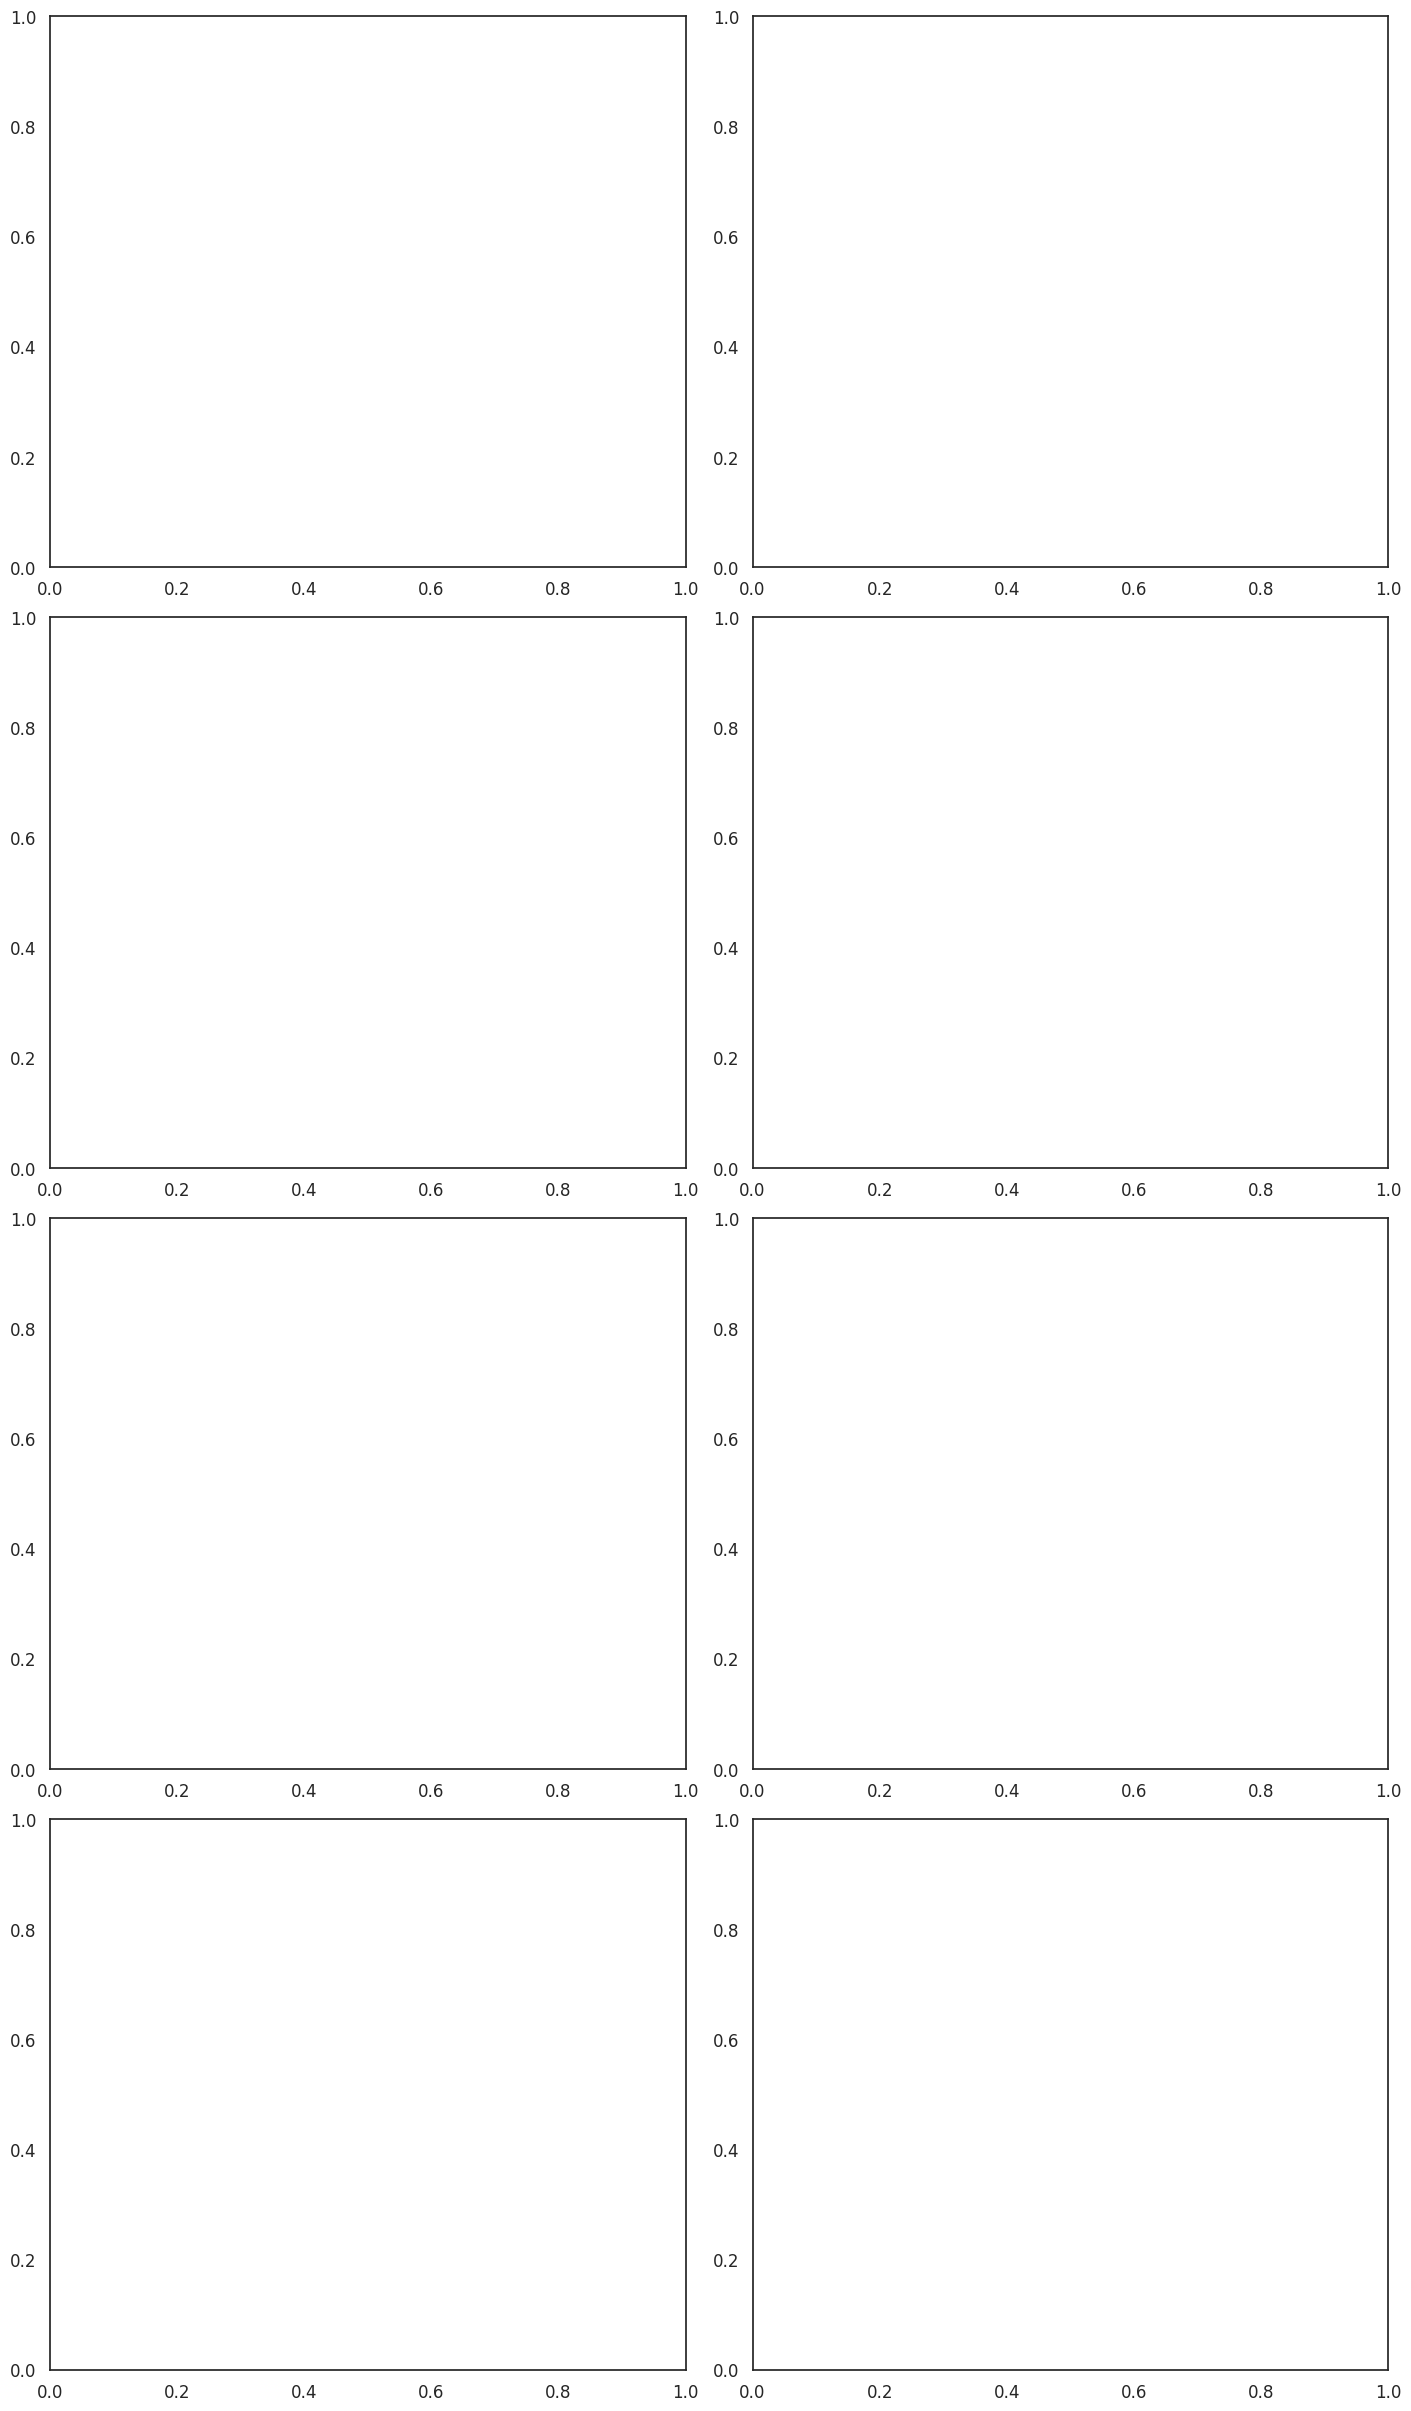

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Sample selection (replace with your actual DataFrame keys)
selected_alleles = list(combined_by_allele.keys())[:8]  # Adjust number to match layout

# Calculate number of rows needed for 2-column layout
n_cols = 2
n_rows = int(np.ceil(len(selected_alleles) / n_cols))

# Set up the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 6), constrained_layout=True)
axes = axes.flatten()  # Flatten in case of 1D row/column

vmin, vmax = -1, 1
cmap = 'coolwarm'

for i, allele in enumerate(selected_alleles):
    df = combined_by_allele[allele].copy()
    ax = axes[i]

    pred_cols = [col for col in df.columns if col != 'sequence']
    df_corr = df[pred_cols].dropna(axis=0, how='any')

    if df_corr.shape[1] < 2 or df_corr.shape[0] < 5:
        ax.axis('off')
        continue

    # Compute correlation
    corr = df_corr.corr(method='spearman')
    corr =corr[corr.columns.str.contains('30')]
    # break
    # Build label map
    label_map = {}
    for col in corr.columns:
        if col == 'measured':
            tag = 'measured'
        else:
            try:
                meta = metadata_df[metadata_df['file_name'] == col].iloc[0]
                tag = f"{'PT' if meta['pretrained'] else 'Non-PT'} {meta['encoding']} {meta['finetune_depth']}L"
            except:
                tag = col[:12]
        label_map[col] = tag

    sorted_keys = sorted(label_map.items(), key=lambda x: (x[1] != 'measured', x[1]))
    sorted_cols = [k for k, v in sorted_keys]
    sorted_labels = [v for k, v in sorted_keys]
    corr = corr.loc[sorted_cols, sorted_cols]
    corr.columns = sorted_labels
    corr.index = sorted_labels

    mask = np.triu(np.ones_like(corr, dtype=bool), k=0)

    sns.heatmap(
        corr, mask=mask, ax=ax, # annot=True, fmt=".1f",
        cmap=cmap, center=0, vmin=vmin, vmax=vmax,
        square=True, cbar=False,
        xticklabels=True, yticklabels=True
    )

    ax.set_title(f"HLA-{allele}", fontsize=16)
    ax.tick_params(axis='x', labelsize=16, rotation=90)
    ax.tick_params(axis='y', labelsize=16)

# Turn off any unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Add colorbar
cbar_ax = fig.add_axes([0.94, 0.3, 0.015, 0.4])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cb = fig.colorbar(sm, cax=cbar_ax)
cb.set_label('Spearman ρ', fontsize=14)
cb.ax.tick_params(labelsize=16)

# # Save
# out_dir = Path('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures_manuscript/')
# out_dir.mkdir(parents=True, exist_ok=True)
# fig.savefig(out_dir / "Matrix_correlations_2col_annot.pdf", dpi=300, bbox_inches="tight")
# plt.close(fig)


In [ ]:
import pandas as pd
from collections import defaultdict

model_to_corrs = defaultdict(list)

# Loop over each allele's correlation matrix
for i, allele in enumerate(selected_alleles):
    df = combined_by_allele[allele].copy()
    pred_cols = [col for col in df.columns if col != 'sequence']
    df_corr = df[pred_cols].dropna(axis=0, how='any')

    if df_corr.shape[1] < 2 or df_corr.shape[0] < 5:
        continue

    corr = df_corr.corr(method='spearman')

    # Build label map
    label_map = {}
    for col in corr.columns:
        if col == 'measured':
            tag = 'measured'
        else:
            try:
                meta = metadata_df[metadata_df['file_name'] == col].iloc[0]
                tag = f"{'PT' if meta['pretrained'] else 'Non-PT'} {meta['encoding']} {meta['finetune_depth']}L"
            except:
                tag = col[:12]
        label_map[col] = tag

    for raw_col, label in label_map.items():
        if label != 'measured' and 'measured' in corr.columns and raw_col in corr.columns:
            try:
                rho = corr.loc['measured', raw_col]
                model_to_corrs[label].append(float(rho))
            except:
                continue

# --- Long-form DataFrame ---
records = []
for model, rhos in model_to_corrs.items():
    for rho in rhos:
        records.append({'Model': model, 'Spearman': rho})

long_df = pd.DataFrame(records)

# --- Aggregate results ---
overall_corr_df = (
    long_df
    .groupby("Model")["Spearman"]
    .agg(['mean', 'median', 'count'])
    .rename(columns={'mean': 'Mean Spearman', 'median': 'Median Spearman', 'count': 'N Alleles'})
    .sort_values("Mean Spearman", ascending=False)
    .reset_index()
)


NameError: name 'selected_alleles' is not defined

In [ ]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
# metrics_df.to_csv('../../performances/models_performances_23042025.csv', index=False)

In [ ]:
import numpy as np

for m in ['spearman','pearsonr','mse']:
    pv = pivots[m]
    total = len(pv)

    if m == 'mse':
        # for errors: epitope_val “wins” when its MSE is LOWER than HLA’s
        wins = np.sum(pv['epitope_val'] < pv['HLA_val'])
    else:
        # for scoring metrics: epitope_val wins when its score is HIGHER
        wins = np.sum(pv['epitope_val'] > pv['HLA_val'])

    print(f"{m}: {wins}/{total} ({wins/total:.1%}) settings where epitope_val wins")


NameError: name 'pivots' is not defined

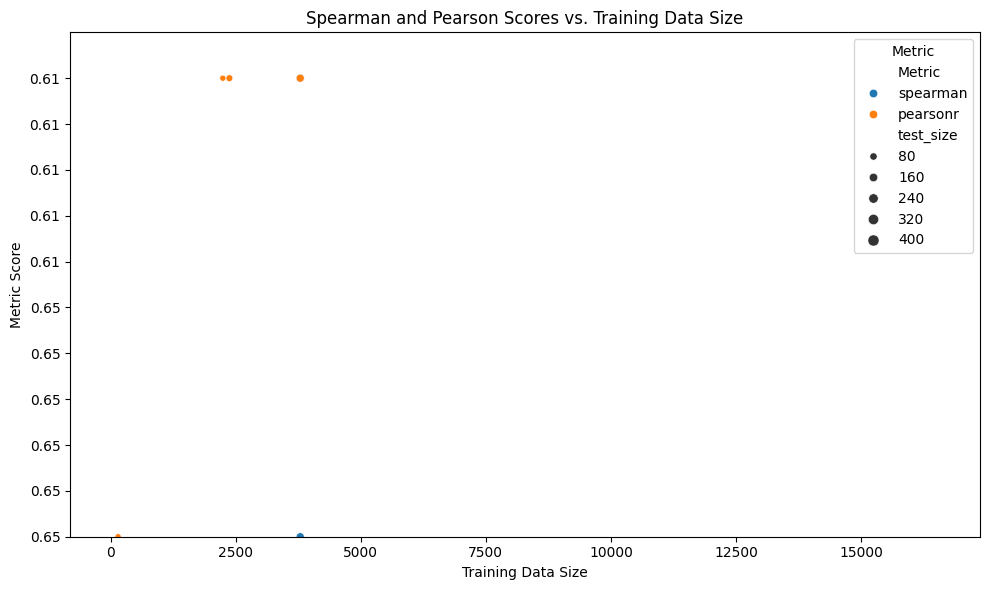

In [ ]:
df_melted = metrics_df.melt(id_vars=['HLA', 'training_data', 'test_size'], 
                            value_vars=['spearman', 'pearsonr'], 
                            var_name='Metric', 
                            value_name='Score')

# Create the scatter plot using seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_melted, 
                x='training_data', 
                y='Score', 
                hue='Metric', 
                size='test_size')

# plt.xscale('log10')
plt.ylim(0, 1.1)
plt.yticks(np.arange(0, 1.1, 0.1))

plt.xlabel('Training Data Size')
plt.ylabel('Metric Score')
plt.title('Spearman and Pearson Scores vs. Training Data Size')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

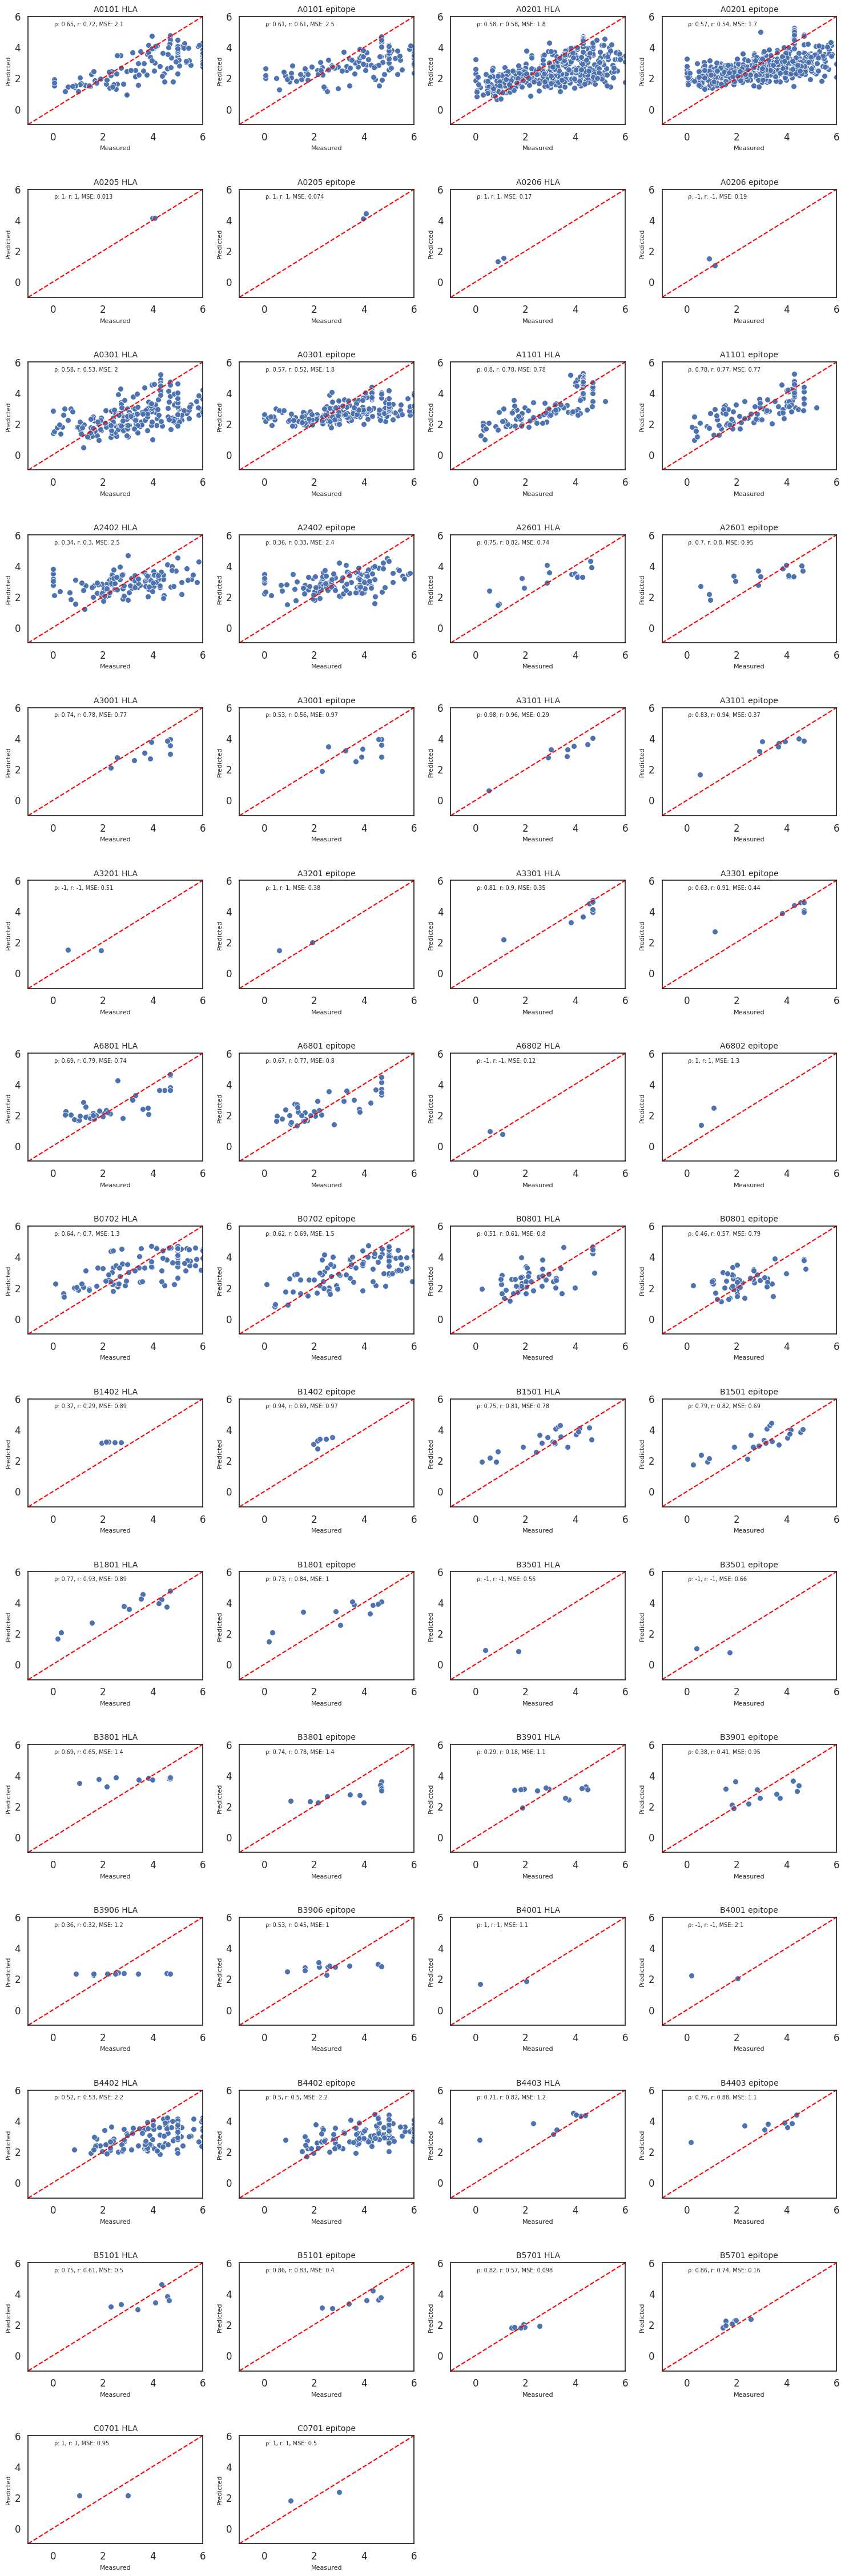

In [ ]:
# Get the unique alleles from evaluations_dt_sorted
alleles = metrics_df.sort_values(by=['HLA', 'encoding'])['Model'].unique()

# Set up a grid: 11 rows x 5 columns
n_rows = 20
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 60))
axes = axes.flatten()

for i, allele in enumerate(alleles):
    if i >= len(axes):
        break

    ax = axes[i]

    # Filter the pre-stored test datasets for the current allele
    test_dataset = test_datasets_df[test_datasets_df['Model'] == allele]

    # If no test data is found, hide this subplot and continue
    if test_dataset.empty:
        ax.set_visible(False)
        continue

    # Create the scatter plot
    sns.scatterplot(data=test_dataset, x='measured', y='prediction', ax=ax, s=50)
    ax.plot([-1, 9], [-1, 9], color='red', linestyle='--', label='Identity Line')
    ax.set_ylim(-1, 6)
    ax.set_xlim(-1, 6)
    ax.set_title(f'{allele}', fontsize=10)
    ax.set_xlabel('Measured', fontsize=8)
    ax.set_ylabel('Predicted', fontsize=8)

    # Compute and annotate the metrics if there is more than one sample
    if len(test_dataset) > 1:
        spearman_val = spearmanr(test_dataset['measured'], test_dataset['prediction'])[0]
        pearson_val = pearsonr(test_dataset['measured'], test_dataset['prediction'])[0]
        mse_val = mean_squared_error(test_dataset['measured'], test_dataset['prediction'])
        
        # Format the values to 2 significant figures
        spearman_str = f"{spearman_val:.2g}"
        pearson_str = f"{pearson_val:.2g}"
        mse_str = f"{mse_val:.2g}"
        # Annotate the metrics on the plot
        ax.text(0.05, 5.4, f"ρ: {spearman_str}, r: {pearson_str}, MSE: {mse_str}", fontsize=7)

# # Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(hspace=0.6)
plt.show()

### Testing the performance in MS Eluded Peptides (No Binding Affinity measurements)

In [ ]:
# Load Data S2: Monoallelic benchmark dataset with predictions
# test_data = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/Data_S2.csv')

In [ ]:
# subset = test_data[
#     (test_data['hla'] == 'HLA-A*02:03')
# ]

In [ ]:
# _ = pd.read_csv('/global/scratch/users/sergiomar10/benchmark/MSE_loss/FinetunedESM/evaluation_HLAA0203_mhcflurry_unique.csv')
# _ = _[_['prediction'] != 'prediction']

In [ ]:
# # Step 2: Melt to long format
# melted = subset_plot.melt(
#     id_vars='hit',
#     value_vars=['netmhcpan4.ba', 'mixmhcpred', 'mhcflurry2.mono_held_out.ba', 'prediction'],
#     var_name='PredictionTool',
#     value_name='BindingAffinity'
# )

# # Step 3: Apply log10 transformation
# melted['log10(BA)'] = np.log10(melted['BindingAffinity'].replace(0, np.nan))  # avoid log10(0)

# # Step 4: Plot violinplot split by 'hit'
# plt.figure(figsize=(10, 6))
# sns.boxplot(data=melted, x='PredictionTool', y='log10(BA)', hue='hit') #, split=True)
# plt.title('Binding Affinity (log10) by Predictor and Hit Status\n(HLA-A*02:03)')
# plt.ylabel('log10(Predicted Affinity)')
# plt.xlabel('Prediction Tool')
# plt.legend(title='Hit', loc='best')
# plt.tight_layout()
# plt.show()


### Testing on BA Affinity with epitopes - Epitopes observed in the training set of MHC Flurry were excluded by loading the S2 file

In [ ]:
test_datasets_df['HLA'] = test_datasets_df['Model'].str.split(' ', expand = True)[0]

KeyError: 'Model'

In [ ]:
def compute_ppv(y_true, y_pred, threshold=np.log10(500)):
    return np.mean((y_true < threshold) & (y_pred < threshold))

# Paths
eval_base = '/global/scratch/users/sergiomar10/benchmark/MSE_loss/FinetunedESM/evaluation_'
mhcflurry_base = '/global/scratch/users/sergiomar10/benchmark/MSE_loss/MHCFlurry/'
netmhc_base = '/global/scratch/users/sergiomar10/benchmark/MSE_loss/NETMHCSPAN4/'

# Storage
combined_metrics = []
merged_dfs_by_HLA = {}
merged_dfs_training = {}

# Loop through unique HLAs
test_datasets_df['allele'] = test_datasets_df['HLA'].str.split(' ', expand =True)[0]

for HLA in test_datasets_df['allele'].unique():
    try:
        formatted_HLA = 'HLA' +  HLA #.replace("HLA-", "").replace("*", "").replace(":", "")
        mhc_path = f"{mhcflurry_base}{formatted_HLA}_mhc_flurry.csv"

        netmhc_path_name = formatted_HLA.replace('HLA','HLA-')
        netmhc_path_name = 'HLA-' +  HLA

        netmhc_path = f"{netmhc_base}{netmhc_path_name}_netmhc.xls"

        # Start from the ground truth + ESMC predictions
        fine_tuned_df = test_datasets_df[test_datasets_df['allele'] == HLA].copy()
        merged_df = fine_tuned_df.copy()

        # Try loading and merging MHCflurry
        if os.path.exists(mhc_path):
            mhc_pred = pd.read_csv(mhc_path)
            if 'affinity' in mhc_pred.columns:
                mhc_pred = mhc_pred.rename(columns={'affinity': 'mhcflurry_affinity'})
            merged_df = pd.merge(merged_df, mhc_pred, left_on='sequence', right_on='peptide', how='left')
            merged_df['mhc_log'] = merged_df['mhcflurry_affinity'].replace(0, np.nan).apply(np.log10)
        else:
            print(f"⚠️ MHCflurry file missing for {HLA}, skipping MHCflurry metrics.")

        # Try loading and merging NetMHCpan
        if os.path.exists(netmhc_path):
            netmhc_df = pd.read_csv(netmhc_path, sep='\t', header=1)
            netmhc_df.columns = netmhc_df.columns.str.strip()
            if 'Peptide' in netmhc_df.columns and 'BA_Rank' in netmhc_df.columns:
                netmhc_df['netmhc_log'] = netmhc_df['BA_Rank'] #.replace(0, np.nan).apply(np.log10)
                merged_df = pd.merge(merged_df, netmhc_df[['Peptide', 'netmhc_log']],
                                     left_on='sequence', right_on='Peptide', how='left')
        else:
            print(f"⚠️ NetMHCpan file missing for {HLA}, skipping NetMHCpan metrics.")

        # Clean
        merged_df = merged_df.drop_duplicates('sequence')
        merged_df = merged_df.dropna(subset=['measured', 'prediction'])

        if len(merged_df) == 0:
            print(f"⚠️ No usable data for {HLA}")
            continue

        label = formatted_HLA

        # --------- Fine-tuned ESMC ---------
        sp_esmc, _ = spearmanr(merged_df['measured'], merged_df['prediction'])
        pr_esmc, _ = pearsonr(merged_df['measured'], merged_df['prediction'])
        ppv_esmc = compute_ppv(merged_df['measured'], merged_df['prediction'])

        combined_metrics.append({
            'allele': formatted_HLA,
            'model': 'Fine-tuned ESMC',
            'label': label,
            'spearman': sp_esmc,
            'spearman_std': 0,
            'pearson': pr_esmc,
            'pearson_std': 0,
            'ppv': ppv_esmc,
            'ppv_std': 0
        })

        # --------- MHCflurry ---------
        if 'mhc_log' in merged_df.columns:
            mhc_valid = merged_df.dropna(subset=['mhc_log'])
            if len(mhc_valid) > 0:
                sp_mhc, _ = spearmanr(mhc_valid['measured'], mhc_valid['mhc_log'])
                pr_mhc, _ = pearsonr(mhc_valid['measured'], mhc_valid['mhc_log'])
                ppv_mhc = compute_ppv(mhc_valid['measured'], mhc_valid['mhc_log'])

                combined_metrics.append({
                    'allele': formatted_HLA,
                    'model': 'MHC Flurry',
                    'label': label,
                    'spearman': sp_mhc,
                    'spearman_std': 0,
                    'pearson': pr_mhc,
                    'pearson_std': 0,
                    'ppv': ppv_mhc,
                    'ppv_std': 0
                })

        # --------- NetMHCpan ---------
        if 'netmhc_log' in merged_df.columns:
            netmhc_valid = merged_df.dropna(subset=['netmhc_log'])
            if len(netmhc_valid) > 0:
                sp_net, _ = spearmanr(netmhc_valid['measured'], netmhc_valid['netmhc_log'])
                pr_net, _ = pearsonr(netmhc_valid['measured'], netmhc_valid['netmhc_log'])
                ppv_net = compute_ppv(netmhc_valid['measured'], netmhc_valid['netmhc_log'])

                combined_metrics.append({
                    'allele': formatted_HLA,
                    'model': 'NetMHCpan',
                    'label': label,
                    'spearman': sp_net,
                    'spearman_std': 0,
                    'pearson': pr_net,
                    'pearson_std': 0,
                    'ppv': ppv_net,
                    'ppv_std': 0
                })

        # Store merged data
        merged_dfs_by_HLA[formatted_HLA] = merged_df
        merged_dfs_training[formatted_HLA] = fine_tuned_df

    except Exception as e:
        print(f"❌ Error processing {HLA}: {e}")

# Combine your core predictions
all_predictions = pd.concat(merged_dfs_by_HLA).reset_index()

# Load additional model predictions
mhc_nuggets = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/other/mhcnuggets_predictions_all_HLAs.csv')
mixmhc = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/other/mixmhcpred_predictions_all_HLAs.csv')

# Harmonize keys (assuming 'allele' and 'peptide' are shared)
for df in [mhc_nuggets, mixmhc]:
    df.columns = [c.lower() for c in df.columns]  # lowercase for consistency

# Rename for merge compatibility
mhc_nuggets = mhc_nuggets.rename(columns={'allele': 'Allele', 'peptide': 'peptide', 'ic50': 'mhcnuggets_log'})
mixmhc = mixmhc.rename(columns={'allele': 'Allele', 'sequence': 'peptide', 'mixmhcpred_%rank': 'mixmhc_rank'})

# Merge in new predictions
all_predictions = all_predictions.merge(mhc_nuggets[[ 'peptide', 'mhcnuggets_log']], on=[ 'peptide'], how='left')
all_predictions = all_predictions.merge(mixmhc[[ 'peptide', 'mixmhc_rank']], on=['peptide'], how='left')

# Log-transform MHCnuggets IC50
all_predictions['mhcnuggets_log'] = np.log10(all_predictions['mhcnuggets_log'] + 1 )

# Load and z-score HLA-Apollo
hla_apollo = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/data/SENSITIVIYTYH_HLAPOLLO.csv')
hla_apollo['z_score_apollo'] = (
    (hla_apollo['mhc_pred_0'] * -1  ))#)- hla_apollo['mhc_pred_0'].mean()) / hla_apollo['mhc_pred_0'].std()) * -1  # Flip score direction

# Merge into main df on peptide
all_predictions = all_predictions.merge(
    hla_apollo[['peptide', 'z_score_apollo']], on='peptide', how='left'
)

# Load and z-score HLA-Athena
hlathena = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/data/predictions_20250527.072827.tsv', sep='\t')
# Assume HLA-A*02:01 for now – generalize later
# hlathena['MSi_A0201'] = (
#     (hlathena['MSi_A0201'] - hlathena['MSi_A0201'].mean()) / hlathena['MSi_A0201'].std()
# ) * -1

# # Merge Athena into df on peptide
all_predictions = all_predictions.merge(
    hlathena[['pep', 'best.MSi']].rename(columns={'pep': 'peptide'}),
    on='peptide', how='left'
)

all_predictions = all_predictions.drop_duplicates('sequence')
all_predictions['best.MSi'] = all_predictions['best.MSi'] * -1

⚠️ MHCflurry file missing for B1402, skipping MHCflurry metrics.
⚠️ NetMHCpan file missing for B1402, skipping NetMHCpan metrics.
⚠️ MHCflurry file missing for A0205, skipping MHCflurry metrics.
⚠️ NetMHCpan file missing for A0205, skipping NetMHCpan metrics.
⚠️ MHCflurry file missing for B5301, skipping MHCflurry metrics.
⚠️ NetMHCpan file missing for B5301, skipping NetMHCpan metrics.
❌ Error processing B5301: `x` and `y` must have length at least 2.
⚠️ MHCflurry file missing for C0602, skipping MHCflurry metrics.
⚠️ NetMHCpan file missing for C0602, skipping NetMHCpan metrics.
❌ Error processing C0602: `x` and `y` must have length at least 2.
❌ Error processing A0206: `x` and `y` must have length at least 2.


In [ ]:
# all_predictions.to_csv('ROC_Curve_peptides.csv')
all_predictions['level_0'].nunique()

25

In [ ]:
all_predictions

,level_0,level_1,sequence,prediction,measured,HLA,allele_x,allele_y,peptide,mhcflurry_affinity,mhcflurry_affinity_percentile,mhcflurry_processing_score,mhcflurry_presentation_score,mhcflurry_presentation_percentile,mhc_log,Peptide,netmhc_log,allele,mhcnuggets_log,mixmhc_rank,z_score_apollo,best.MSi
0,HLAA3101,0,GRAKLLGAEEK,3.299766,3.687131,A3101 HLA,A3101,HLAA3101,GRAKLLGAEEK,19644.475306,8.609000,0.151088,0.008630,27.617391,4.293240,GRAKLLGAEEK,14.2307,NaN,4.533316,76.052802,39.061070,-0.002645
6561,HLAA3101,1,RAKLLGAEEK,2.764861,2.912907,A3101 HLA,A3101,HLAA3101,RAKLLGAEEK,3297.967181,2.441750,0.044665,0.032703,7.558261,3.518246,RAKLLGAEEK,3.0980,NaN,4.493948,54.621953,35.355272,-0.147629
13122,HLAA3101,3,HVKITDFGL,2.834808,3.669339,A3101 HLA,A3101,HLAA3101,HVKITDFGL,20067.408634,8.901250,0.258663,0.012322,18.617989,4.302491,HVKITDFGL,13.1592,NaN,4.094945,18.364721,41.699907,-0.017426
19683,HLAA3101,4,FGLAKLLGA,3.498930,3.926835,A3101 HLA,A3101,HLAA3101,FGLAKLLGA,22757.374692,11.231500,0.350082,0.015028,15.160951,4.357122,FGLAKLLGA,29.5296,NaN,3.805853,47.529591,40.498808,-0.090378
26244,HLAA3101,5,GLAKLLGAEEK,3.297620,3.025883,A3101 HLA,A3101,HLAA3101,GLAKLLGAEEK,15497.300734,6.358750,0.151236,0.010846,22.192310,4.190256,GLAKLLGAEEK,19.2857,NaN,4.339979,33.447771,36.545142,-0.123628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564813,HLAA6802,1,QLSAIALGV,2.469157,1.079181,A6802 epitope,A6802,HLAA6802,QLSAIALGV,116.891819,0.366875,0.119363,0.530308,0.757337,2.067784,QLSAIALGV,1.0617,NaN,1.271842,8.908796,33.464019,-0.584952
564829,HLAC0701,0,KRPTPTFHS,2.336926,3.000434,C0701 epitope,C0701,HLAC0701,KRPTPTFHS,3817.317901,4.513750,0.021717,0.026332,9.155353,3.581758,KRPTPTFHS,10.0084,NaN,3.856792,1.263511,36.142435,-0.008275
564830,HLAC0701,1,KRPTPTFHF,1.795441,1.041393,C0701 epitope,C0701,HLAC0701,KRPTPTFHF,37.002228,0.023125,0.548795,0.940368,0.061793,1.568228,KRPTPTFHF,0.2089,NaN,3.694755,0.026450,3.257400,-0.792239
564831,HLAB3501,0,FAFRDLCIVY,0.750190,1.716003,B3501 epitope,B3501,HLAB3501,FAFRDLCIVY,90.557553,0.270000,0.544947,0.867048,0.173424,1.956925,FAFRDLCIVY,0.0535,NaN,4.531258,0.045612,7.446882,-0.090873


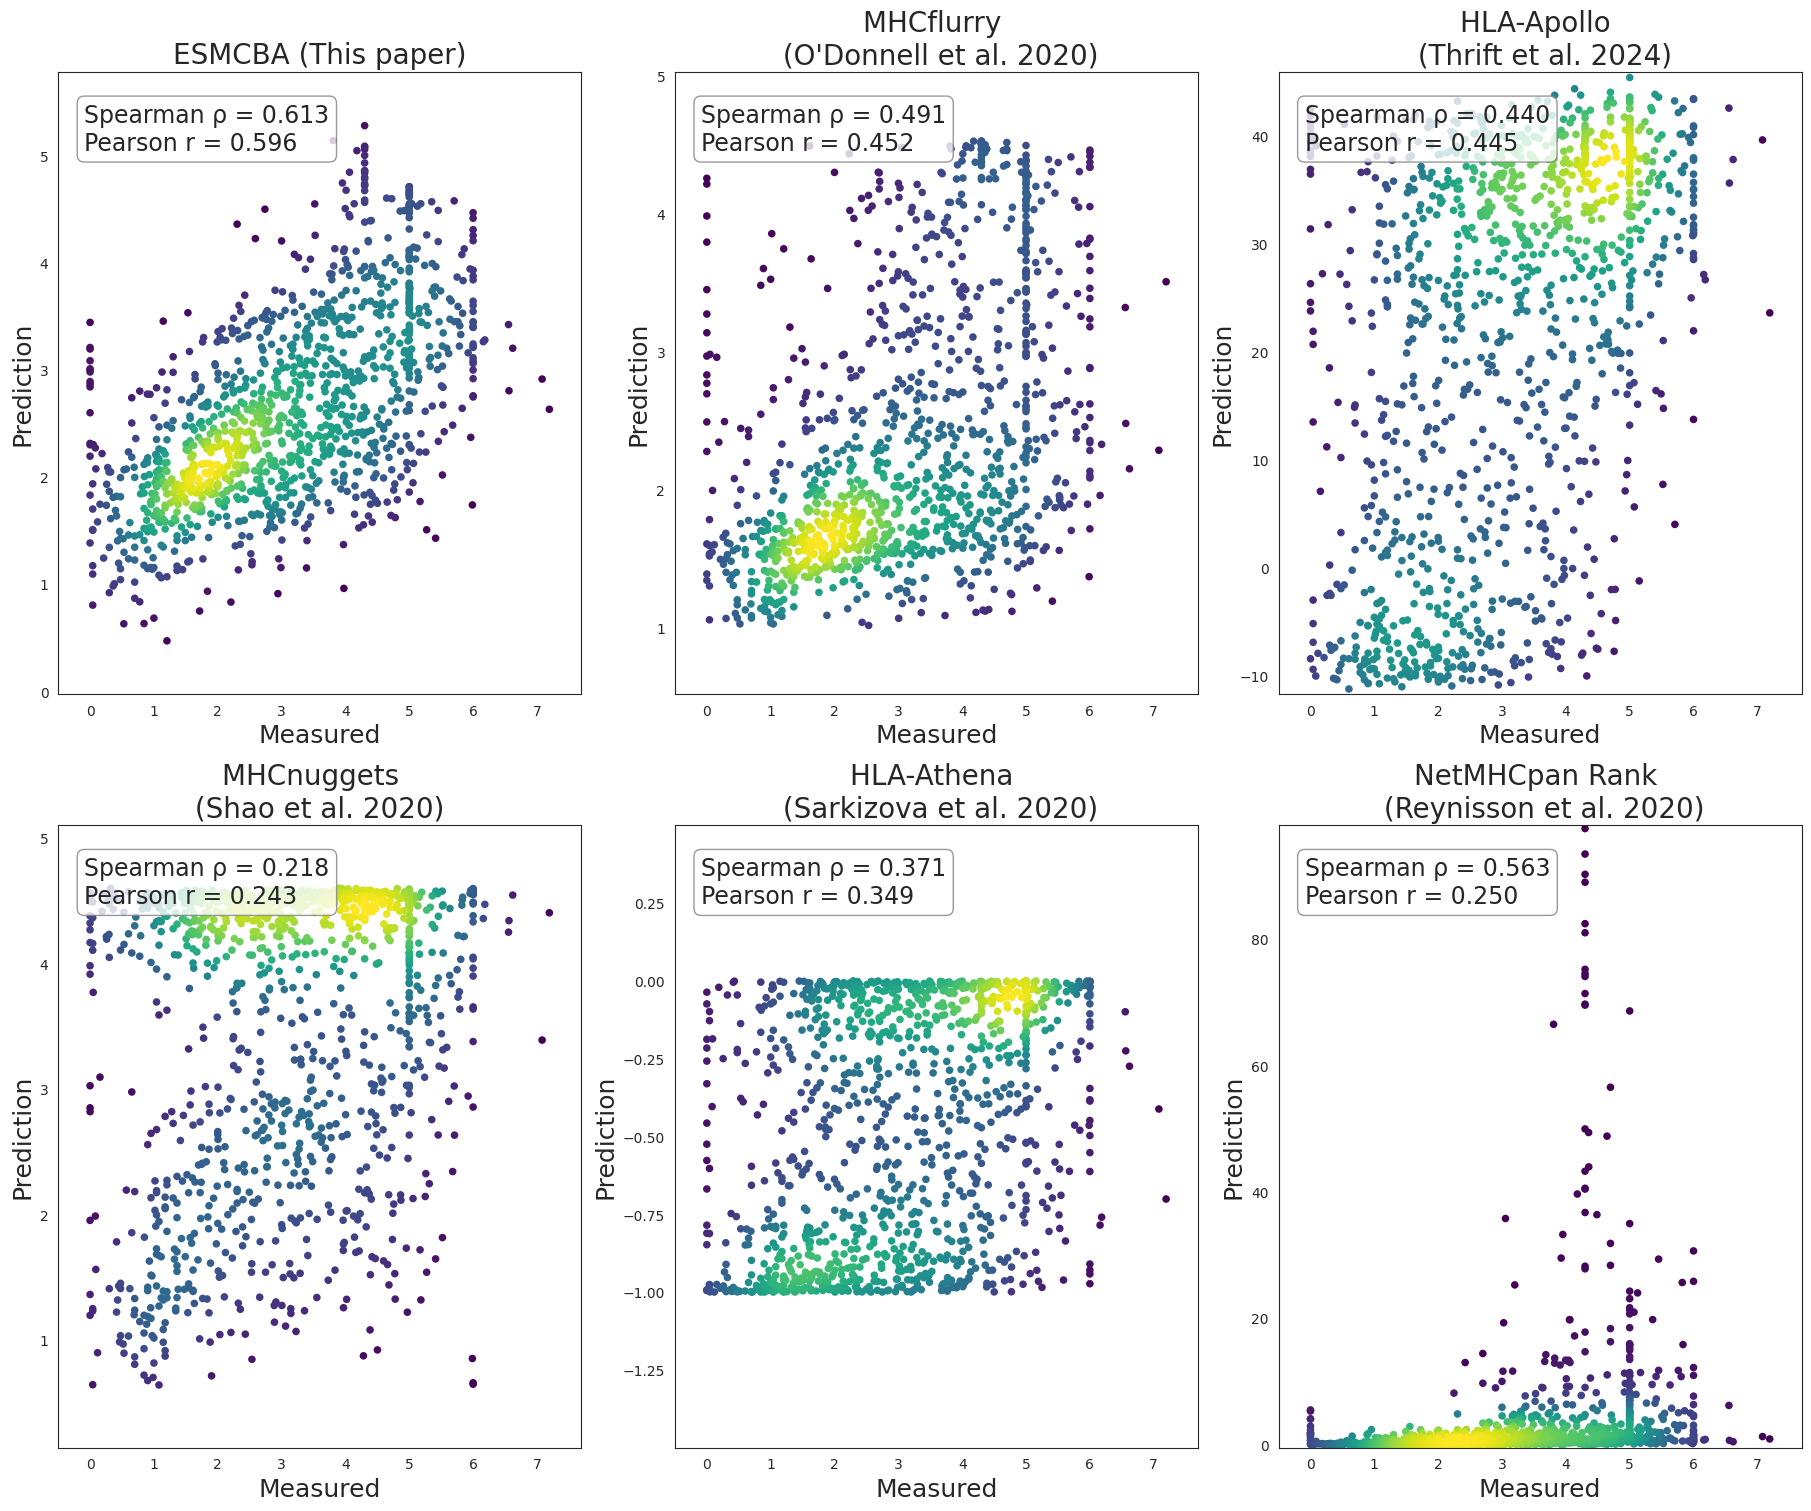

In [ ]:
plot_pairs = [
    ('prediction', 'ESMCBA (This paper)'),
    ('mhc_log', "MHCflurry \n (O'Donnell et al. 2020)"),
    ('z_score_apollo', 'HLA-Apollo \n (Thrift et al. 2024)'),
    ('mhcnuggets_log', 'MHCnuggets  \n (Shao et al. 2020) '),
    ('best.MSi', 'HLA-Athena \n (Sarkizova et al. 2020)'),
    ('netmhc_log', 'NetMHCpan Rank \n (Reynisson et al. 2020)'),
    # ('mixmhc_rank', 'MixMHCpred (%Rank)'),
]


sns.set_style('white')

fig, axs = plt.subplots(2, 3, figsize=(18, 15), constrained_layout=True)
axs = axs.flatten()


for ax, (col, title) in zip(axs, plot_pairs):
    x = all_predictions['measured']
    y = all_predictions[col]

    # Drop NA
    valid = x.notna() & y.notna()
    x, y = x[valid], y[valid]

    # Density
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)
    idx = z.argsort()
    x, y, z = x.iloc[idx], y.iloc[idx], z[idx]

    # Plot
    sc = ax.scatter(x, y, c=z, cmap='viridis', s=30, edgecolor='none')
    spearman_rho, _ = spearmanr(x, y)
    pearson_r, _ = pearsonr(x, y)

    # Axis limits
    max_val = max(x.max(), y.max()) + 0.5
    ax.set_xlim(x.min()- 0.5, x.max() + 0.5)
    ax.set_ylim(y.min()- 0.5, y.max()+ 0.5)

    ax.set_title(title, fontsize=20)
    ax.set_xlabel('Measured', fontsize=18)
    ax.set_ylabel('Prediction', fontsize=18)
    
    # Correlation text with background box
    text_str = f'Spearman ρ = {spearman_rho:.3f}\nPearson r = {pearson_r:.3f}'
    ax.text(
        0.05, 0.95, text_str,
        transform=ax.transAxes,
        fontsize=17,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
    )

    for j in range(len(plot_pairs), len(axs)):
        axs[j].axis('off')

# from pathlib import Path
# out_dir = Path('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures_manuscript/')
# out_dir.mkdir(parents=True, exist_ok=True)
# fig.savefig(out_dir / "Scatterplot_models.pdf", dpi=300, bbox_inches="tight")
# plt.close(fig)

plt.show()


In [ ]:
import pandas as pd

IEDB_full = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/mhc_ligand_table_export_1727815227.tsv', sep = '\t', header = 0)
IEDB_full['allele'] = IEDB_full['MHC Restriction - Name'].str.replace('*','').str.replace('HLA-','').str.replace(':','')
IEDB_full.head()

In [ ]:
test_datasets_df['HLA'] = test_datasets_df['Model'].str.split(' ', expand = True)[0]

In [ ]:
test_datasets_df['HLA'].unique()


array(['A3101 HLA', 'B1402 epitope', 'A0205 epitope', 'B5101 epitope',
       'B5701 epitope', 'A3101 epitope', 'B5701 HLA', 'B1801 HLA',
       'B4403 epitope', 'A3301 HLA', 'A1101 HLA', 'B1801 epitope',
       'A1101 epitope', 'B1501 epitope', 'B4403 HLA', 'B5101 HLA',
       'A2601 HLA', 'B1501 HLA', 'B3801 epitope', 'A3001 HLA',
       'A0205 HLA', 'A2601 epitope', 'B3801 HLA', 'A6801 HLA',
       'A6801 epitope', 'A0101 HLA', 'B0702 HLA', 'A3301 epitope',
       'B5301 HLA', 'B0702 epitope', 'A0101 epitope', 'B3906 epitope',
       'C0602 HLA', 'A0301 HLA', 'A0301 epitope', 'A0201 HLA',
       'A0201 epitope', 'A3001 epitope', 'B3901 epitope', 'B4402 HLA',
       'B0801 HLA', 'B4402 epitope', 'B0801 epitope', 'B3906 HLA',
       'B3901 HLA', 'B1402 HLA', 'A2402 epitope', 'A2402 HLA',
       'B4001 epitope', 'A6802 epitope', 'B4001 HLA', 'C0701 epitope',
       'A0206 epitope', 'B3501 epitope', 'A3201 epitope', 'A3201 HLA',
       'A6802 HLA', 'A0206 HLA', 'B3501 HLA', 'C0701 HLA']

In [ ]:
import os
import glob
import pandas as pd
import numpy as np

# Paths
eval_base = '/global/scratch/users/sergiomar10/ESMCBA/benchmark'
mhcflurry_base = eval_base
netmhc_base = eval_base

# Storage
merged_dfs_by_HLA = {}

test_datasets_df['allele'] = test_datasets_df['HLA']

for HLA in test_datasets_df['HLA'].unique():

    # if HLA not in 'A0201':
    #     continue

    try:
        formatted_HLA = HLA.replace("*", "").replace(":", "")
        print(f"\n🔍 Processing {HLA}")

        # Find all ESMCBA predictions for this allele
        esmc_files = glob.glob(f"{eval_base}/*epitope*{HLA}*umap*.csv") #, recursive=True)
        # esmc_files = [f for f in esmc_files if "umap" not in f and "mhc_flurry" not in f and "netmhc" not in f]
        if len(esmc_files) == 0:
            print(f"⚠️ No ESMCBA predictions found for {HLA}")
            continue

        # Load first valid ESMCBA prediction file
        for esmc_path in esmc_files:
            try:
                fine_tuned_df = pd.read_csv(esmc_path)
                if 'sequence' not in fine_tuned_df.columns:
                    continue
                break
            except Exception:
                continue
        else:
            print(f"❌ Could not read any valid ESMCBA file for {HLA}")
            continue

        merged_df = fine_tuned_df.copy()

        # MHCflurry
        mhc_path = f"{mhcflurry_base}/{formatted_HLA}_mhcflurry.csv"
        if os.path.exists(mhc_path):
            mhc_pred = pd.read_csv(mhc_path)
            if 'affinity' in mhc_pred.columns:
                mhc_pred = mhc_pred.rename(columns={'affinity': 'mhcflurry_affinity'})
            merged_df = pd.merge(merged_df, mhc_pred, left_on='sequence', right_on='peptide', how='left')
            merged_df['mhc_log'] = merged_df['mhcflurry_affinity'].replace(0, np.nan).apply(np.log10)
        else:
            print(f"⚠️ MHCflurry missing for {HLA}")

        # NetMHCpan
        netmhc_path = f"{netmhc_base}/netmhc_{formatted_HLA}.xls"
        if os.path.exists(netmhc_path):
            try:
                netmhc_df = pd.read_csv(netmhc_path, sep='\t', header=1)
                netmhc_df.columns = netmhc_df.columns.str.strip()
                if 'Peptide' in netmhc_df.columns and 'BA_Rank' in netmhc_df.columns:
                    netmhc_df['netmhc_log'] = netmhc_df['BA_Rank']#.replace(0, np.nan).apply(np.log10)
                    merged_df = pd.merge(merged_df, netmhc_df[['Peptide', 'netmhc_log']],
                                         left_on='sequence', right_on='Peptide', how='left')
            except Exception:
                print(f"❌ Could not parse NetMHCpan file for {HLA}")
        else:
            print(f"⚠️ NetMHCpan missing for {HLA}")

        # Finalize
        merged_df = merged_df.drop_duplicates('sequence')

        if len(merged_df.columns) > 12:
            merged_dfs_by_HLA[HLA] = merged_df
        # break

    except Exception as e:
        print(f"❌ Error processing {HLA}: {e}")



🔍 Processing A3101 HLA
⚠️ No ESMCBA predictions found for A3101 HLA

🔍 Processing B1402 epitope
⚠️ No ESMCBA predictions found for B1402 epitope

🔍 Processing A0205 epitope
⚠️ No ESMCBA predictions found for A0205 epitope

🔍 Processing B5101 epitope
⚠️ No ESMCBA predictions found for B5101 epitope

🔍 Processing B5701 epitope
⚠️ No ESMCBA predictions found for B5701 epitope

🔍 Processing A3101 epitope
⚠️ No ESMCBA predictions found for A3101 epitope

🔍 Processing B5701 HLA
⚠️ No ESMCBA predictions found for B5701 HLA

🔍 Processing B1801 HLA
⚠️ No ESMCBA predictions found for B1801 HLA

🔍 Processing B4403 epitope
⚠️ No ESMCBA predictions found for B4403 epitope

🔍 Processing A3301 HLA
⚠️ No ESMCBA predictions found for A3301 HLA

🔍 Processing A1101 HLA
⚠️ No ESMCBA predictions found for A1101 HLA

🔍 Processing B1801 epitope
⚠️ No ESMCBA predictions found for B1801 epitope

🔍 Processing A1101 epitope
⚠️ No ESMCBA predictions found for A1101 epitope

🔍 Processing B1501 epitope
⚠️ No ESMCB

In [ ]:
all_predictions = pd.concat(merged_dfs_by_HLA).reset_index()

ValueError: No objects to concatenate

In [ ]:
mhc_nuggets = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/other/ROC_curve_mhcnuggets.csv')
mixmhc = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/other/ROC_curve_mixmhcpred.csv')
hla_athena = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/other/ROC_Peptides_HLAthena_combined.csv', sep=',')
hla_apollo = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/other/ROC_curve_HLApollo_final.csv')

In [ ]:
# Merge with MHC Nuggets
all_predictions = pd.merge(
    all_predictions,
    mhc_nuggets[['peptide', 'ic50']],
    on=['peptide'],
    how='left'
).drop_duplicates(['sequence','level_0'])


# Merge with HLA Apollo
all_predictions = pd.merge(
    all_predictions,
    hla_apollo[['peptide', 'mhc_pred_0_rank']],
    on='peptide',
    how='left'
).drop_duplicates(['sequence','level_0'])



# Merge with HLA Athena (key 'sequence' matches 'pep')
all_predictions = pd.merge(
    all_predictions,
    hla_athena[['pep', 'prank.MSi']],
    left_on='sequence',
    right_on='pep',
    how='left'
).drop(columns='pep')  # Drop extra 'pep' column after merge

# Merge with MixMHCpred
all_predictions = pd.merge(
    all_predictions,
    mixmhc[['sequence', 'MixMHCpred_%Rank']],
    on='sequence',
    how='left'
).drop_duplicates(['sequence','level_0'])


# Optional: Drop duplicates if necessary
all_predictions = all_predictions.drop_duplicates(['sequence','level_0'])



In [ ]:
# all_predictions.to_csv('ROC_Curve_peptides.csv')
all_predictions['level_0'].nunique()

28

In [ ]:
merged_df

,sequence,prediction,measured,Model,HLA,allele_x,allele_y,peptide,mhcflurry_affinity,mhcflurry_affinity_percentile,mhcflurry_processing_score,mhcflurry_presentation_score,mhcflurry_presentation_percentile,mhc_log,Peptide,netmhc_log
0,KVKNEVASF,1.455375,0.591065,A3201 epitope,A3201,A3201,HLAA3201,KVKNEVASF,36.772133,0.055125,0.677334,0.961541,0.031549,1.565519,KVKNEVASF,0.1401
1,QLSAIALGV,1.981942,1.913814,A3201 epitope,A3201,A3201,HLAA3201,QLSAIALGV,3359.750796,3.122250,0.119363,0.041456,6.047908,3.526307,QLSAIALGV,3.3476


In [ ]:
# sns.set(style="white")

# # Define columns and titles
# hue_columns = ['prediction', 'mhc_log', 'netmhc_log']
# titles = ['ESMCBA Prediction', 'MHCflurry log10(Affinity)', 'NetMHCpan']

# for n in merged_dfs_by_HLA.keys():
#     # Create subplots
#     fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

#     # Loop through each panel
#     for i, (hue, title) in enumerate(zip(hue_columns, titles)):
#         sns.scatterplot(
#             data=merged_dfs_by_HLA[n],
#             x='UMAP_1', y='UMAP_2',
#             hue=hue,
#             ax=axs[i],
#             palette='viridis',
#             s=100
#         )
#         axs[i].set_title(f'{n} {title}')
#         axs[i].legend(title=hue, loc='best')

#     plt.tight_layout()
#     plt.show()
#     # break


In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import roc_curve, auc
# import numpy as np

# merged_dfs_by_HLA['A0201'] = pd.merge(left=merged_dfs_by_HLA['A0201'], right=IEDB_full[(IEDB_full['allele'] == 'A0201')][['Assay - Qualitative Measurement', 'Epitope - Name']], left_on = 'sequence', right_on = 'Epitope - Name', how = 'left')

# # Data and models
# df = merged_dfs_by_HLA['A0201'].drop_duplicates('sequence')

# models = {
#     'prediction': 'ESMCBA',
#     'mhc_log': 'MHCflurry',
#     'netmhc_log': 'NetMHCpan'
# }

# # Define only the useful class pairs to compare
# pairs_to_plot = [
#     ('Negative', 'Positive'),
#     ('Negative', 'Positive-Low'),
#     ('Negative', 'Positive-Intermediate'),
#     ('Negative', 'Positive-High'),
#     # ('Positive-Low', 'Positive-High'),
#     ('Positive-Intermediate', 'Positive-High'),
#     ('Positive-Low', 'Positive-Intermediate'),
# ]

# # Prepare subplots
# n_panels = len(pairs_to_plot)
# ncols = 3
# nrows = int(np.ceil(n_panels / ncols))

# fig, axs = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), sharex=True, sharey=True)
# axs = axs.flatten()

# # Plot each comparison
# for idx, (cat1, cat2) in enumerate(pairs_to_plot):
#     ax = axs[idx]
#     subset = df[df['Assay - Qualitative Measurement'].isin([cat1, cat2])].copy()
#     subset['label'] = (subset['Assay - Qualitative Measurement'] == cat1).astype(int)

#     if subset['label'].nunique() < 2 or subset.empty:
#         ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
#         ax.set_title(f'{cat1} vs {cat2}')
#         ax.axis('off')
#         continue

#     for col, model_label in models.items():
#         if subset[col].isnull().all():
#             continue
#         try:
#             fpr, tpr, _ = roc_curve(subset['label'], subset[col])
#             roc_auc = auc(fpr, tpr)
#             ax.plot(fpr, tpr, label=f'{model_label} ({roc_auc:.2f})')
#         except Exception:
#             continue

#     ax.plot([0, 1], [0, 1], 'k--', lw=0.5)
#     ax.set_xlim([0, 1])
#     ax.set_ylim([0, 1])
#     ax.set_title(f'{cat1} vs {cat2}')
#     ax.legend(loc='lower right', fontsize=8)

# # Hide any unused subplots
# for i in range(len(pairs_to_plot), len(axs)):
#     axs[i].axis('off')

#     # # Save the figure with the HLA name in the specified folder (uncomment to use)
# # out_dir = Path('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures_manuscript/')
# # out_dir.mkdir(parents=True, exist_ok=True)      
# # save_path = out_dir / f"A0201ROC.pdf"
# # fig = plt.gcf()
# # fig.savefig(save_path, dpi=300, bbox_inches="tight")
# # plt.close(fig)

# plt.tight_layout()
# plt.show()


In [ ]:
models = {
    'prediction': 'ESMCBA',
    'mhc_log': 'MHCflurry',
    'netmhc_log': 'NetMHCpan',
    'mhc_pred_0_rank': 'HLA-Apollo',
    'prank.MSi': 'HLA-Athena',
    'ic50': 'MHCnuggets',
    'MixMHCpred_%Rank': 'MixMHCpred',
}

# Define only the useful class pairs to compare
pairs_to_plot = [
    ('Negative', 'Positive'),
    ('Negative', 'Positive-Low'),
    ('Negative', 'Positive-Intermediate'),
    ('Negative', 'Positive-High'),
    # ('Positive-Low', 'Positive-High'),m ,
    ('Positive-Intermediate', 'Positive-High'),
    ('Positive-Low', 'Positive-Intermediate'),
]

In [ ]:
from sklearn.metrics import roc_curve, auc

# Store AUCs per allele and per comparison
roc_results = {pair: {'ESMCBA': [], 'MHCflurry': [], 'NetMHCpan': [],
                         'HLA-Apollo': [], 'HLA-Athena': [],
                             'MHCnuggets':[],'MixMHCpred':[],  } for pair in pairs_to_plot}

# Loop over all merged dataframes by allele
for allele in all_predictions['allele'].unique():
    # print(f"🔍 Processing allele {
    df = all_predictions[all_predictions['allele'] == allele].copy()
    # Merge in IEDB metadata
    meta = IEDB_full[IEDB_full['allele'] == allele]
    df = pd.merge(df, meta[['Epitope - Name', 'Assay - Method', 'Assay - Qualitative Measurement']],
                  left_on='sequence', right_on='Epitope - Name', how='left')
    
    # Skip if assay info is missing
    if 'Assay - Qualitative Measurement' not in df.columns:
        continue

    for cat1, cat2 in pairs_to_plot:
        subset = df[df['Assay - Qualitative Measurement'].isin([cat1, cat2])].copy()
        if subset.empty or subset['Assay - Qualitative Measurement'].nunique() < 2:
            continue
        subset['label'] = (subset['Assay - Qualitative Measurement'] == cat1).astype(int)

        # Compute ROC for each model
        for col, label in [('prediction', 'ESMCBA'), ('mhc_log', 'MHCflurry'), ('netmhc_log', 'NetMHCpan'), ('mhc_pred_0_rank', 'HLA-Apollo'), ('prank.MSi', 'HLA-Athena'), ('ic50', 'MHCnuggets'), ('MixMHCpred_%Rank', 'MixMHCpred')]:
            if col not in subset or subset[col].isnull().all():
                continue
            try:
                fpr, tpr, _ = roc_curve(subset['label'], subset[col])
                score = auc(fpr, tpr)
                roc_results[(cat1, cat2)][label].append({'allele': allele, 'auc': score})
            except Exception:
                print(f"❌ Error computing ROC for {allele} {col} in {cat1} vs {cat2}")
                continue

records = []
for (cat1, cat2), model_scores in roc_results.items():
    for model, entries in model_scores.items():
        for entry in entries:
            records.append({
                'Comparison': f'{cat1} vs {cat2}',
                'Model': model,
                'AUC': entry['auc'],
                'Allele': entry['allele']
            })

auc_df = pd.DataFrame(records)



NameError: name 'IEDB_full' is not defined

In [ ]:
model_order

['ESMCBA',
 'HLA-Apollo',
 'HLA-Athena',
 'MHCflurry',
 'MHCnuggets',
 'MixMHCpred',
 'NetMHCpan']

In [ ]:
# Define consistent model and comparison order
model_order = sorted(auc_df['Model'].unique())
comparison_order = sorted(auc_df['Comparison'].unique())

# Set up subplot grid
n_cols = 3
n_rows = int(np.ceil(len(comparison_order) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

# Random jitter setup
rng = np.random.default_rng(seed=42)
jitter = 0.15

# Plot each panel
for idx, comparison in enumerate(comparison_order):
    row, col = divmod(idx, n_cols)
    ax = axes[row][col]

    sub_df = auc_df[auc_df['Comparison'] == comparison]

    # Boxplot
    sns.boxplot(
        data=sub_df,
        x='Model',
        y='AUC',
        ax=ax,
        order=model_order,
        palette='viridis',
        showfliers=False
    )

    # Jittered scatter
    for i, model in enumerate(model_order):
        y_vals = sub_df[sub_df['Model'] == model]['AUC'].values
        x_vals = rng.normal(loc=i, scale=jitter, size=len(y_vals))
        ax.scatter(x_vals, y_vals, s=20, color='black', alpha=0.7, zorder=3)

    ax.set_title(comparison, fontsize=18)
    ax.set_xlabel('')
    ax.set_ylim(0.0, 1.05)
    ax.set_ylabel('AUC', fontsize=15)
    ax.set_xticks(np.arange(len(model_order))) #, fontsize=15)
    ax.set_xticklabels(model_order, fontsize=15, rotation=45, ha='right')

    # ax.set_xticks(rotation=45, ha='right')

# Turn off empty panels
for idx in range(len(comparison_order), n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row][col].axis('off')

# #     # Save the figure with the HLA name in the specified folder (uncomment to use)
out_dir = Path('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures_manuscript/')
out_dir.mkdir(parents=True, exist_ok=True)      
save_path = out_dir / f"AUCROC_done.pdf"
fig = plt.gcf()
fig.tight_layout(pad=3.0)  
fig.savefig(save_path, dpi=300) #, bbox_inches="tight")
plt.close(fig)


# # fig.suptitle("AUC per Model Across Comparisons", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


/tmp/ipykernel_2817543/669436385.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2817543/669436385.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2817543/669436385.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2817543/669436385.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2817543/669436385.py:22: FutureWa

<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np

# ── mean (and optional SEM) AUC per model × comparison ─────────────────────────
summary = (
    auc_df
      .groupby(['Comparison', 'Model'])['AUC']
      .agg(['mean', 'std', 'count'])       # mean AUC plus sample stats
      .rename(columns={'mean': 'mean_auc'})  # clearer column name
)

summary['sem'] = summary['std'] / np.sqrt(summary['count'])  # standard error

# If you prefer a wide “heat-map” layout (comparisons as rows, models as columns):
wide_mean = summary['mean_auc'].unstack()      # or .pivot_table(..., aggfunc='mean')

print(summary.reset_index())   # long form
print(wide_mean)               # wide form
wide_mean

                                Comparison       Model  mean_auc       std  \
0                     Negative vs Positive      ESMCBA  0.825212  0.093256   
1                     Negative vs Positive  HLA-Apollo  0.795710  0.103468   
2                     Negative vs Positive  HLA-Athena  0.783558  0.140350   
3                     Negative vs Positive   MHCflurry  0.858588  0.081545   
4                     Negative vs Positive  MHCnuggets  0.533518  0.186176   
5                     Negative vs Positive  MixMHCpred  0.783624  0.139132   
6                     Negative vs Positive   NetMHCpan  0.892561  0.080245   
7                Negative vs Positive-High      ESMCBA  0.969587  0.042121   
8                Negative vs Positive-High  HLA-Apollo  0.825759  0.066234   
9                Negative vs Positive-High  HLA-Athena  0.856564  0.084051   
10               Negative vs Positive-High   MHCflurry  0.967221  0.022867   
11               Negative vs Positive-High  MHCnuggets  0.578413

Model,ESMCBA,HLA-Apollo,HLA-Athena,MHCflurry,MHCnuggets,MixMHCpred,NetMHCpan
Comparison,,,,,,,
Negative vs Positive,0.825212,0.795710,0.783558,0.858588,0.533518,0.783624,0.892561
Negative vs Positive-High,0.969587,0.825759,0.856564,0.967221,0.578413,0.847046,0.991891
Negative vs Positive-Intermediate,0.956361,0.719121,0.774463,0.908451,0.558474,0.746335,0.951609
Negative vs Positive-Low,0.790924,0.617841,0.692013,0.780509,0.557544,0.668073,0.847671
Positive-Intermediate vs Positive-High,0.754477,0.657748,0.652815,0.698883,0.550658,0.677594,0.817995
Positive-Low vs Positive-Intermediate,0.901332,0.615648,0.635359,0.729712,0.527962,0.603811,0.790825


In [ ]:
0.901332 - 0.790825


0.11050700000000002

In [ ]:
break

level_0
A3101    1000
B5101    1000
B0801    1000
B4402    1000
B3901    1000
A0201    1000
A0301    1000
B5301    1000
B0702    1000
A0101    1000
A6801    1000
A3001    1000
A2601    1000
B1501    1000
A1101    1000
B1801    1000
B5701    1000
A3201     838
C0602     221
B3801     165
B3906      45
Name: count, dtype: int64

In [ ]:
fwefwef

NameError: name 'fwefwef' is not defined

In [ ]:
# test_datasets_df{}{{{casclkma,spcmaspcd,pqwomcpowemfcolewkmlofew lofew{}}}

In [ ]:
combined_df = pd.DataFrame(combined_metrics)

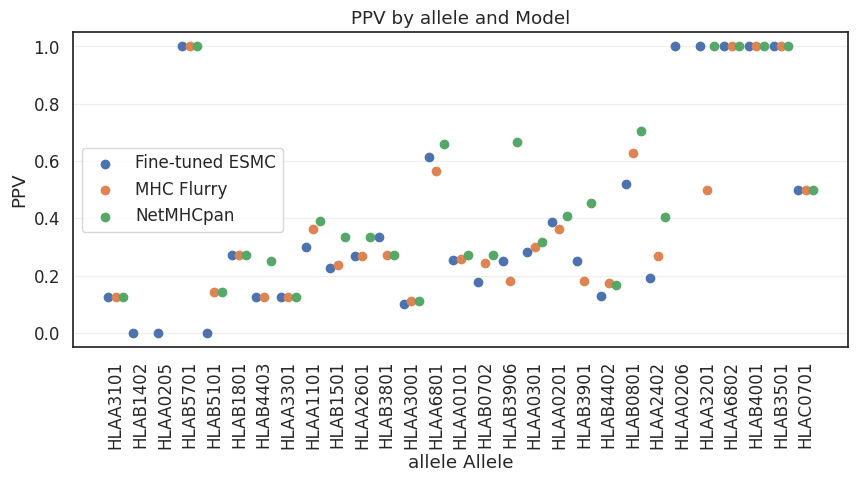

In [ ]:
def plot_ppv_side_by_side(combined_df):
    # Extract unique categories for allele and model.
    unique_allele = combined_df['allele'].unique()
    unique_models = combined_df['model'].unique()
    
    # Set up the figure size (adjust as needed).
    plt.figure(figsize=(10, 5))
    
    # We'll place each category (allele) on an integer tick: 0, 1, 2, ...
    x_positions = np.arange(len(unique_allele))
    
    # Compute horizontal offsets so each model is scattered side-by-side at each x-position.
    # For example, if there are 3 models, offsets might be [-0.2, 0.0, 0.2].
    n_models = len(unique_models)
    offsets = np.linspace(-0.3, 0.3, n_models)
    
    # Loop over each model and plot points with a distinct horizontal offset
    for offset, model in zip(offsets, unique_models):
        # Filter rows for this specific model
        subset = combined_df[combined_df['model'] == model]
        
        x_vals = []
        y_vals = []
        
        # Collect the PPV values for each allele in the correct x-position
        for i, allele in enumerate(unique_allele):
            # Subset further by allele
            allele_subset = subset[subset['allele'] == allele]
            # It's possible there are multiple rows per allele if you store replicate info differently
            # so we plot them all. If there's only one row, it will simply add one point.
            for ppv_val in allele_subset['ppv'].values:
                x_vals.append(i + offset)
                y_vals.append(ppv_val)
        
        # Plot these points for the current model
        plt.scatter(x_vals, y_vals, label=model)
    
    # Set the x-ticks to the integer positions and label them with the allele names
    plt.xticks(x_positions, unique_allele, rotation=90)
    
    # Add some spacing at the bottom if labels are long
    plt.subplots_adjust(bottom=0.25)
    
    # Add labels and title
    plt.xlabel("allele Allele")
    plt.ylabel("PPV")
    plt.title("PPV by allele and Model")
    
    # Optionally add a light grid on the y-axis for clarity
    plt.grid(axis='y', alpha=0.3)
    
    # Add a legend
    plt.legend()
    
    # Show the figure
    plt.show()

# Example usage:
plot_ppv_side_by_side(combined_df)


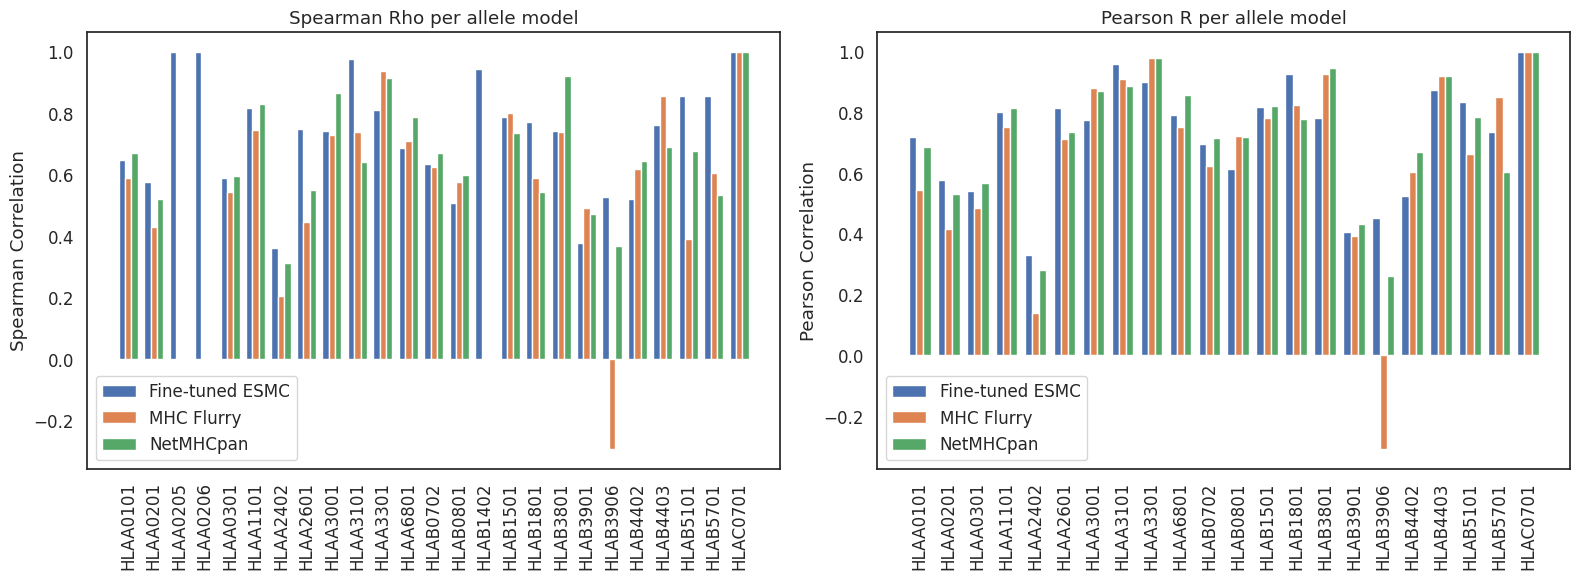

In [ ]:
# Pivot tables for correlations (no std anymore)
pivot_spearman = combined_df.pivot(index='allele', columns='model', values='spearman')
pivot_spearman = pivot_spearman[pivot_spearman['Fine-tuned ESMC'] > 0 ]
pivot_pearson  = combined_df.pivot(index='allele', columns='model', values='pearson')
pivot_pearson = pivot_pearson[pivot_pearson['Fine-tuned ESMC'] > 0 ]

pivot_pearson = pivot_pearson[pivot_pearson['NetMHCpan'].notna()]

# X-axis positions
x = np.arange(len(pivot_spearman.index))
width = 0.25  # Width of each bar

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Spearman correlations
axes[0].bar(x - width, pivot_spearman['Fine-tuned ESMC'], width, label='Fine-tuned ESMC')
axes[0].bar(x,         pivot_spearman['MHC Flurry'],      width, label='MHC Flurry')
axes[0].bar(x + width, pivot_spearman['NetMHCpan'],       width, label='NetMHCpan')

axes[0].set_xticks(x)
axes[0].set_xticklabels(pivot_spearman.index, rotation=90)
axes[0].set_ylabel('Spearman Correlation')
axes[0].set_title('Spearman Rho per allele model')
axes[0].legend()


x = np.arange(len(pivot_pearson.index))
# Plot Pearson correlations
axes[1].bar(x - width, pivot_pearson['Fine-tuned ESMC'], width, label='Fine-tuned ESMC')
axes[1].bar(x,         pivot_pearson['MHC Flurry'],      width, label='MHC Flurry')
axes[1].bar(x + width, pivot_pearson['NetMHCpan'],       width, label='NetMHCpan')

axes[1].set_xticks(x)
axes[1].set_xticklabels(pivot_pearson.index, rotation=90)
axes[1].set_ylabel('Pearson Correlation')
axes[1].set_title('Pearson R per allele model')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
model_predictions = pd.concat(merged_dfs_by_HLA.values(), ignore_index=True)

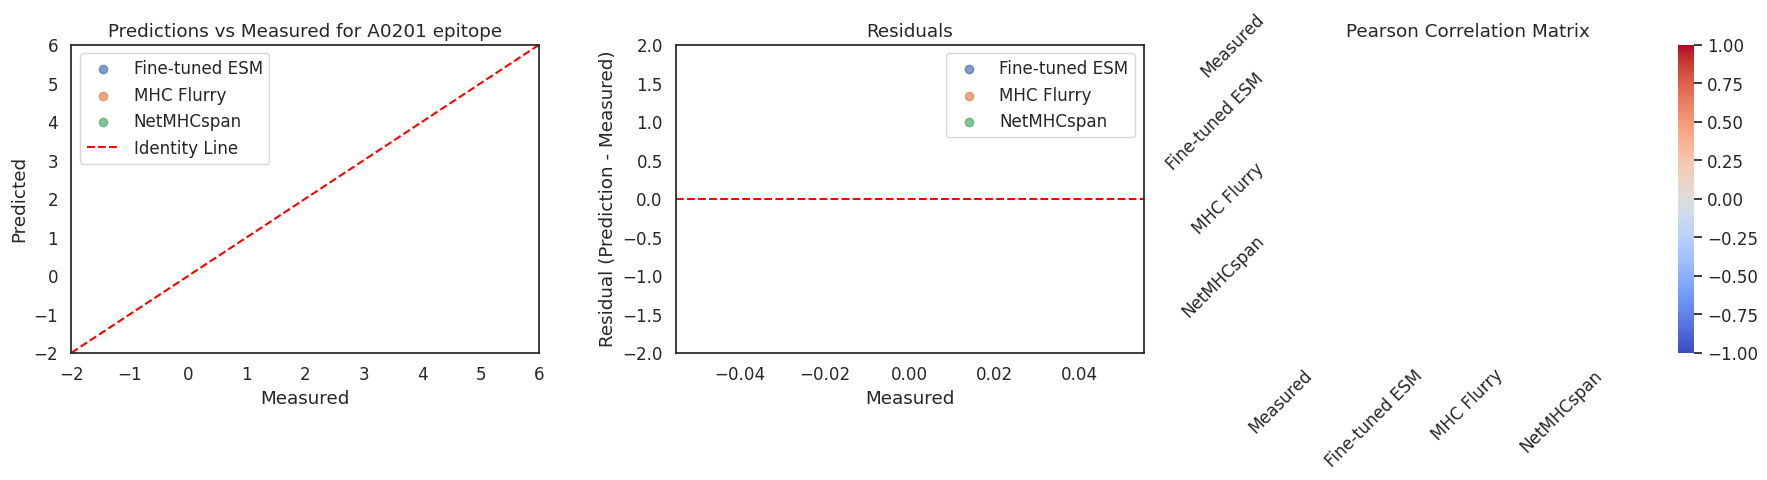

In [ ]:
allele = 'A0201 epitope' #HLAA1101
df_filtered = model_predictions[model_predictions['HLA'] == allele]
df_filtered = df_filtered[['measured', 'prediction', 'mhc_log','netmhc_log']]
df_filtered.columns = ['Measured', 'Fine-tuned ESM', 'MHC Flurry', 'NetMHCspan']

# Plotting
x = 'Measured'
ys = ['Fine-tuned ESM', 'MHC Flurry', 'NetMHCspan']


# Setup the figure with subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Scatter plot with identity line
for y_col in ys:
    axs[0].scatter(df_filtered[x], df_filtered[y_col], label=y_col, alpha=0.7)

axs[0].plot([-2, 6], [-2, 6], color='red', linestyle='--', label='Identity Line')
axs[0].set_title(f'Predictions vs Measured for {allele}')
axs[0].set_xlabel('Measured')
axs[0].set_ylabel('Predicted')
axs[0].set_xlim(-2, 6)
axs[0].set_ylim(-2, 6)
axs[0].legend()
# axs[0].grid(True)

# Plot 2: Residuals (Prediction - Measured)
for y_col in ys:
    residuals = df_filtered[y_col] - df_filtered[x]
    axs[1].scatter(df_filtered[x], residuals, label=y_col, alpha=0.7)

axs[1].axhline(0, color='red', linestyle='--')
axs[1].set_title('Residuals')
axs[1].set_xlabel('Measured')
axs[1].set_ylabel('Residual (Prediction - Measured)')
axs[1].set_ylim(-2, 2)
axs[1].legend()
# axs[1].grid(True)

correlation = df_filtered[[x] + ys].corr()
# Plot using seaborn
sns.heatmap(correlation, cmap='coolwarm', annot=True, vmin=-1, vmax=1, ax=axs[2])
axs[2].set_title('Pearson Correlation Matrix')
# Add colorbar and text labels
# fig.colorbar(im, ax=axs[2])
axs[2].set_xticks(range(len(correlation.columns)))
axs[2].set_yticks(range(len(correlation.columns)))
axs[2].set_xticklabels(correlation.columns, rotation=45)
axs[2].set_yticklabels(correlation.columns, rotation = 45)
axs[2].set_title('Pearson Correlation Matrix')

plt.tight_layout()
plt.show()



In [ ]:
combined_df

,allele,model,label,spearman,spearman_std,pearson,pearson_std,ppv,ppv_std
0,HLAA3101,Fine-tuned ESMC,HLAA3101,0.976190,0,0.960705,0,0.125,0
1,HLAA3101,MHC Flurry,HLAA3101,0.738095,0,0.910553,0,0.125,0
2,HLAA3101,NetMHCpan,HLAA3101,0.642857,0,0.888455,0,0.125,0
3,HLAB1402,Fine-tuned ESMC,HLAB1402,0.942857,0,0.694225,0,0.000,0
4,HLAA0205,Fine-tuned ESMC,HLAA0205,1.000000,0,0.998553,0,0.000,0
...,...,...,...,...,...,...,...,...,...
76,HLAB3501,MHC Flurry,HLAB3501,1.000000,0,1.000000,0,1.000,0
77,HLAB3501,NetMHCpan,HLAB3501,-1.000000,0,-1.000000,0,1.000,0
78,HLAC0701,Fine-tuned ESMC,HLAC0701,1.000000,0,1.000000,0,0.500,0
79,HLAC0701,MHC Flurry,HLAC0701,1.000000,0,1.000000,0,0.500,0


In [ ]:
# model_predictions.to_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/performances/HLAA0201_predictions.csv', index=False)

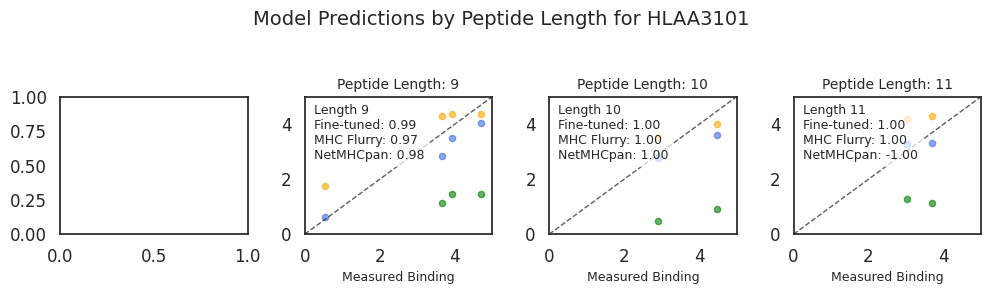

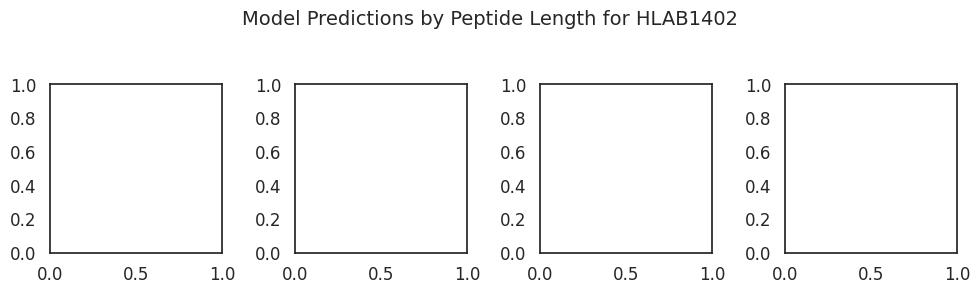

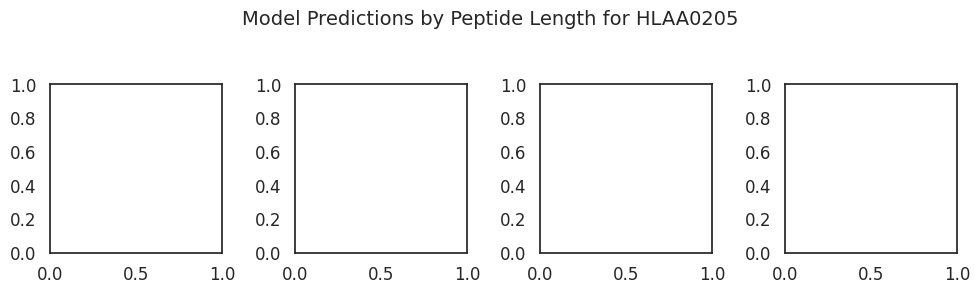

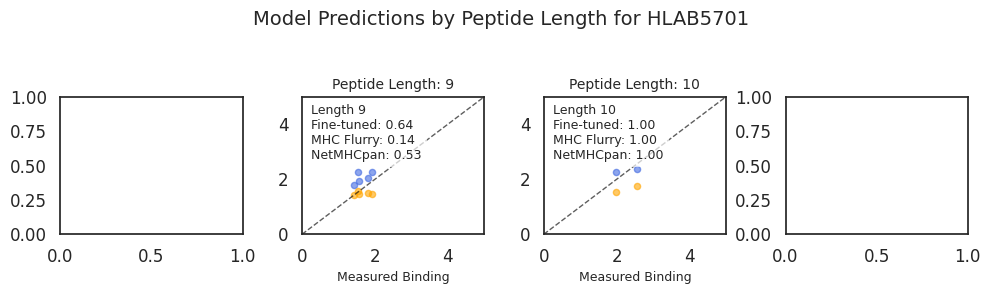

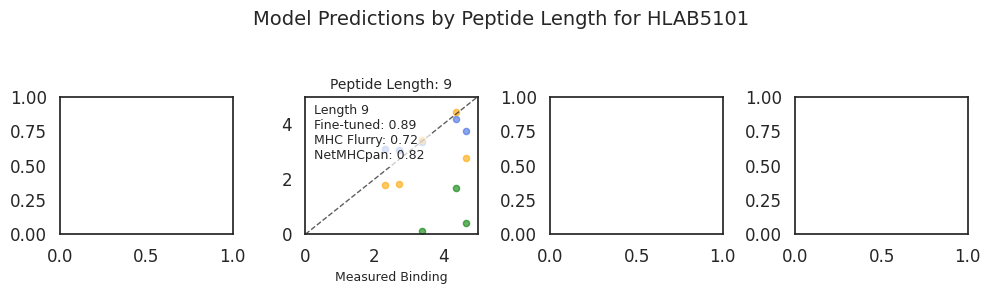

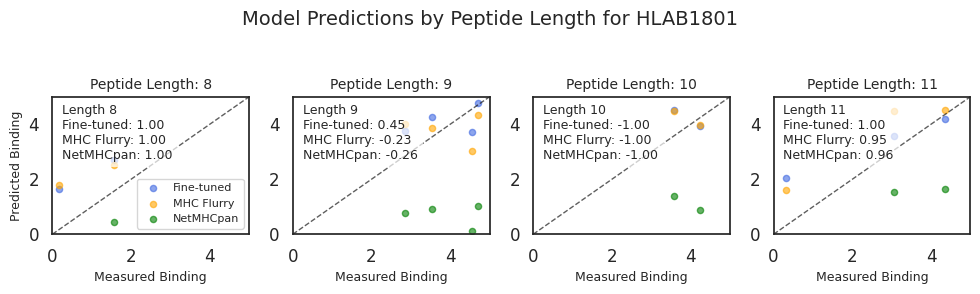

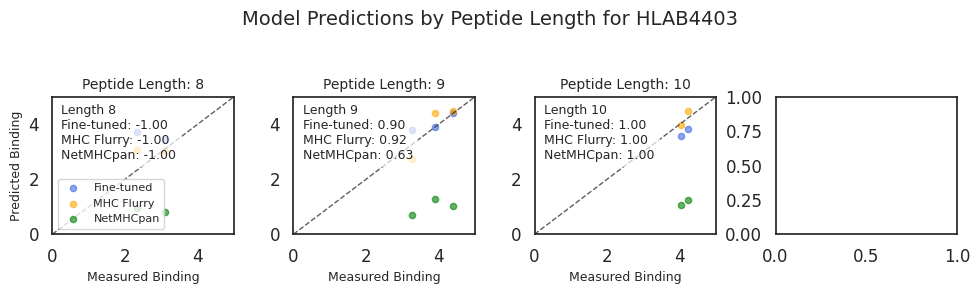

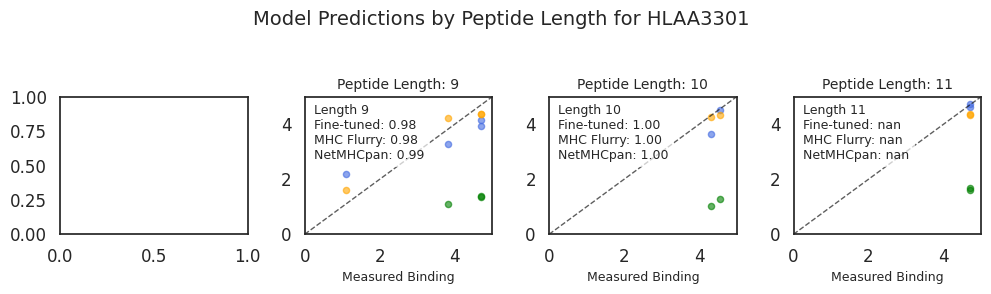

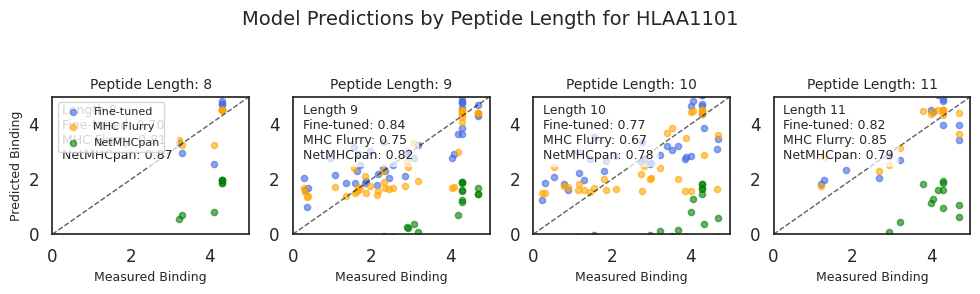

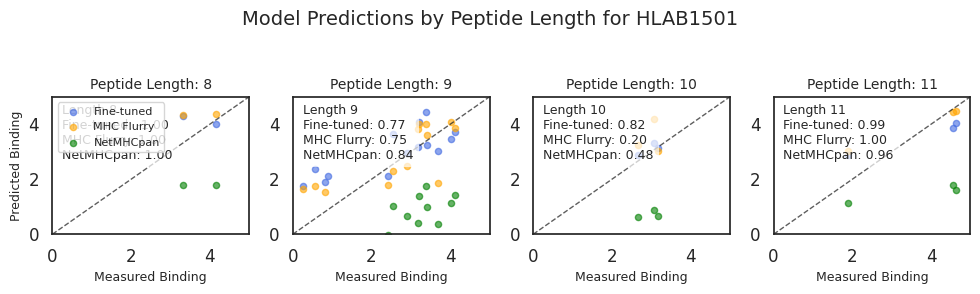

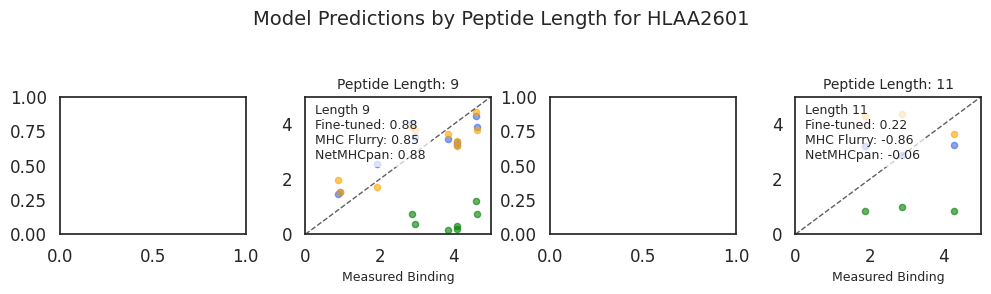

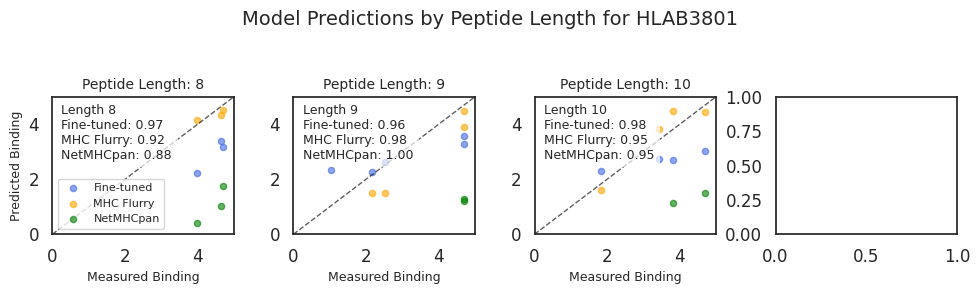

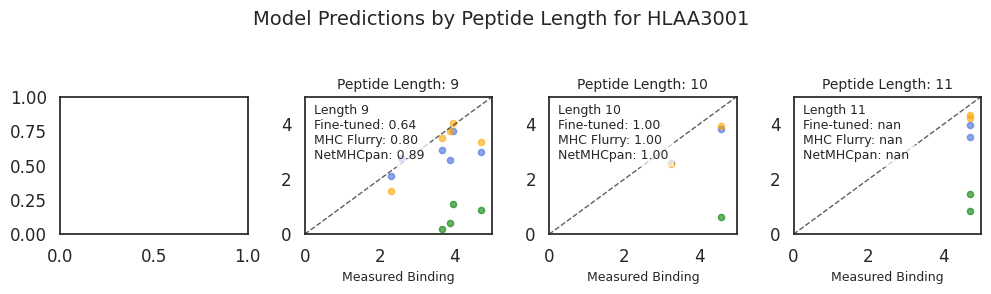

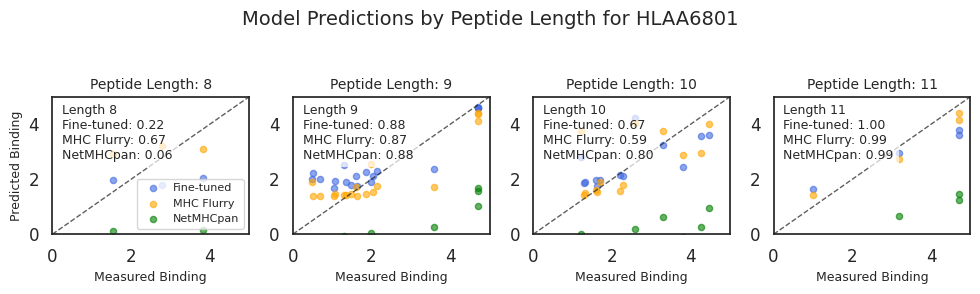

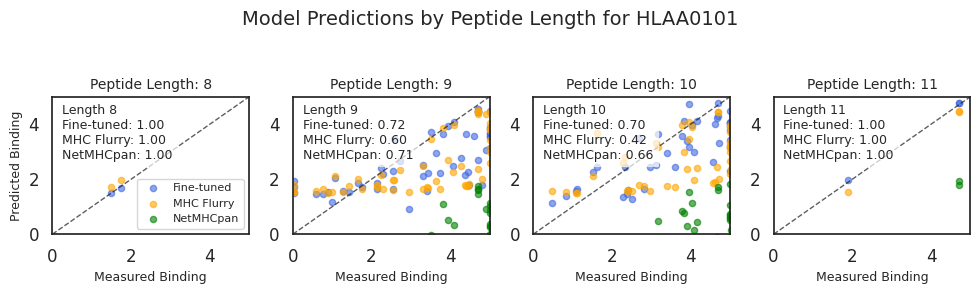

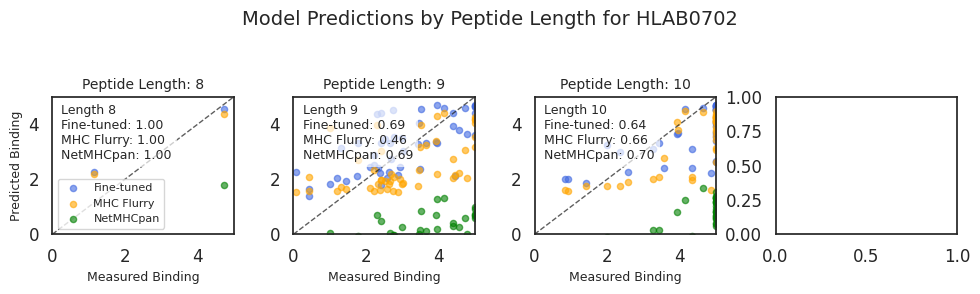

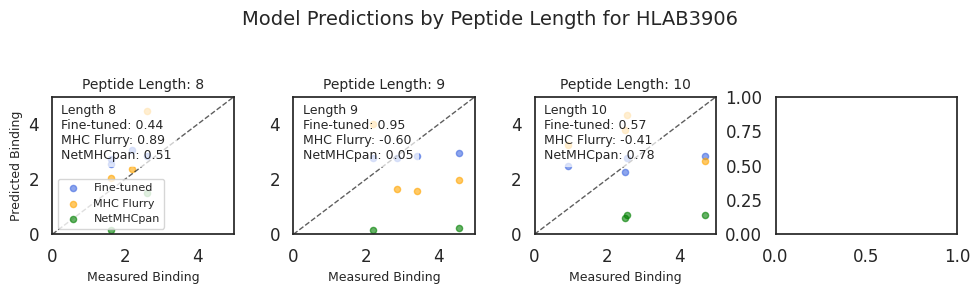

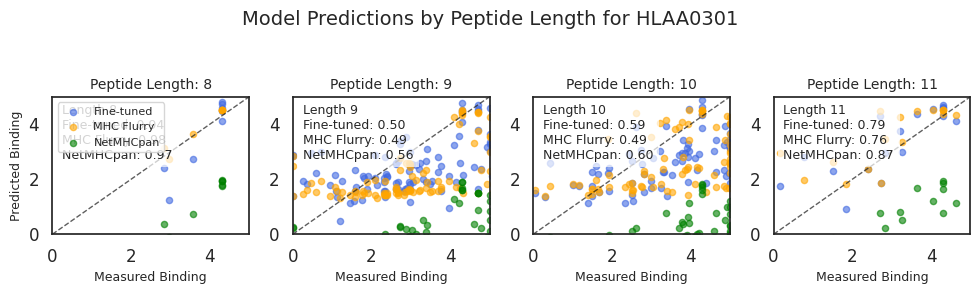

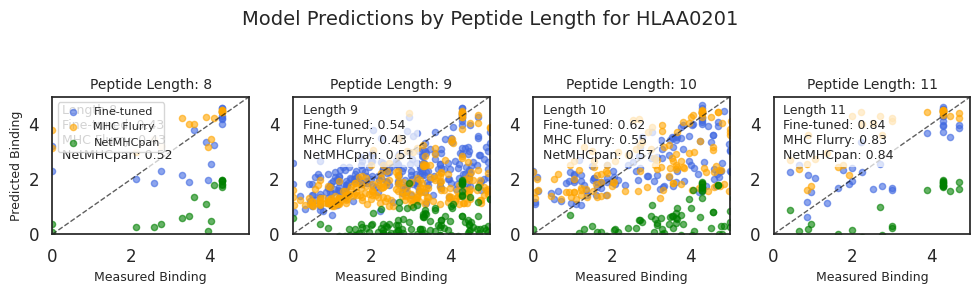

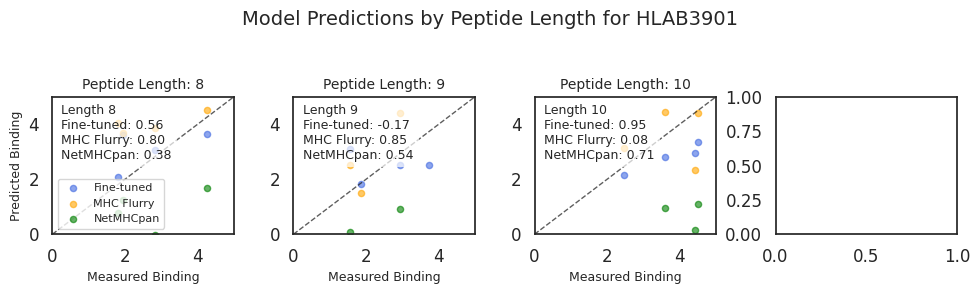

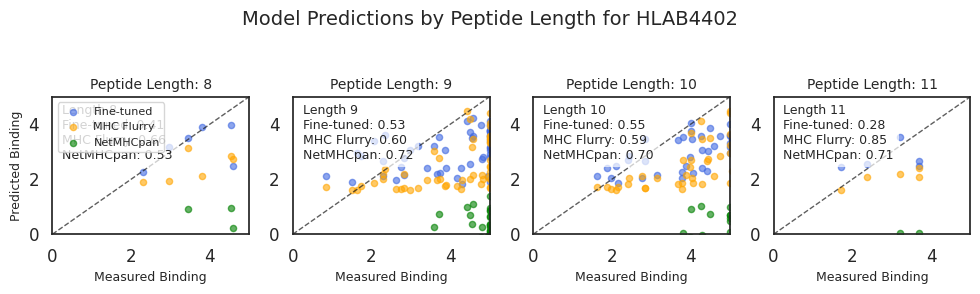

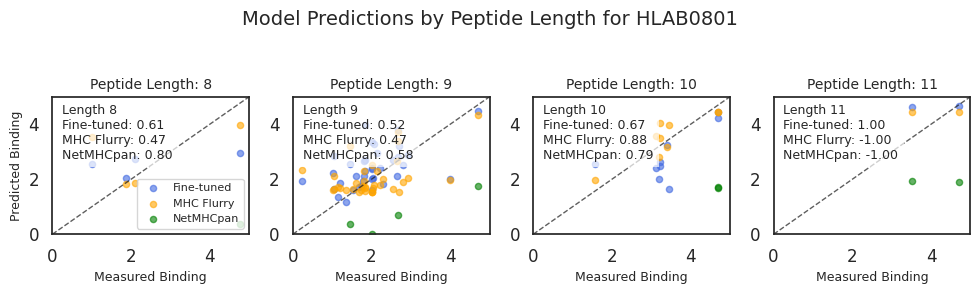

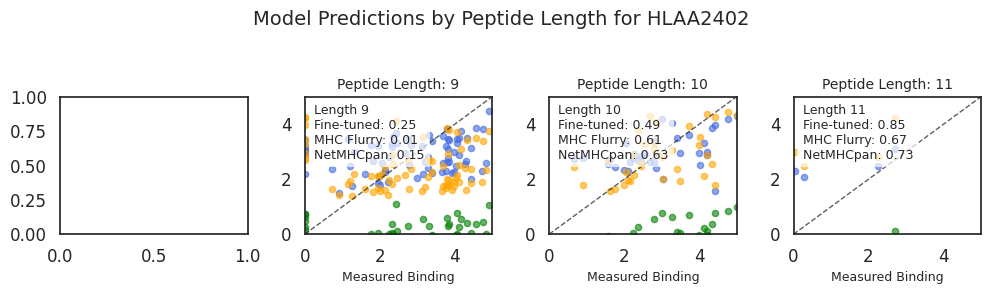

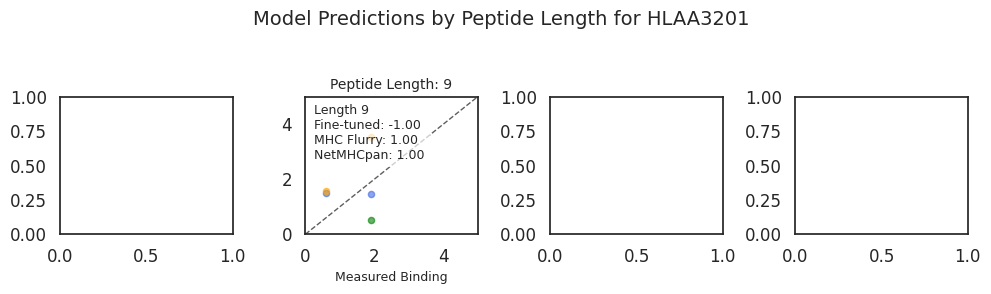

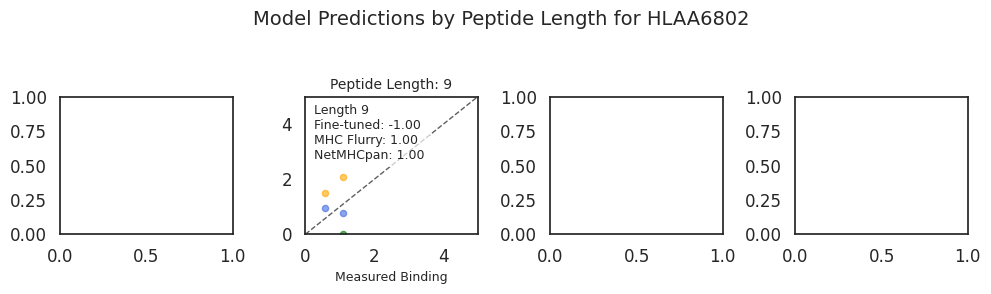

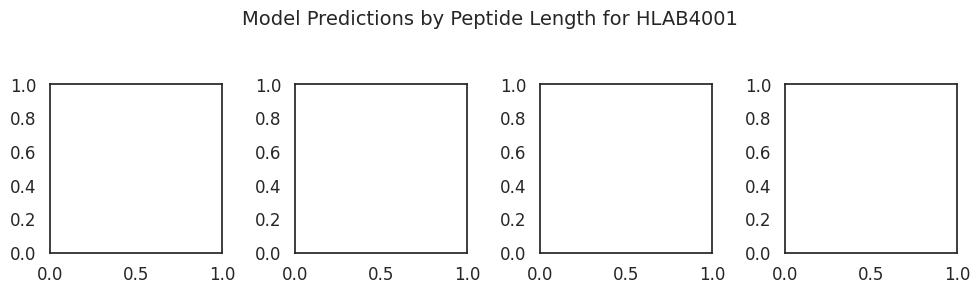

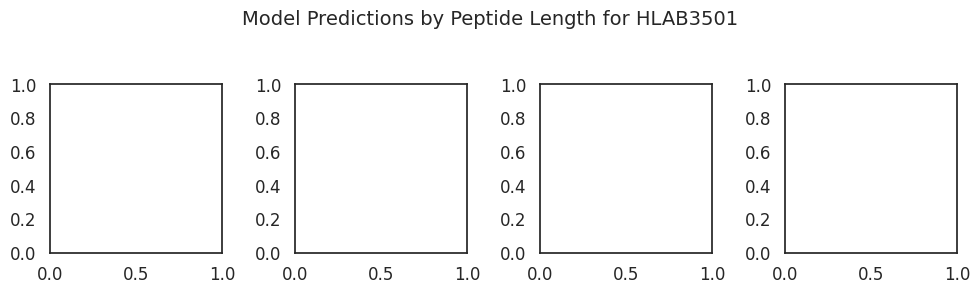

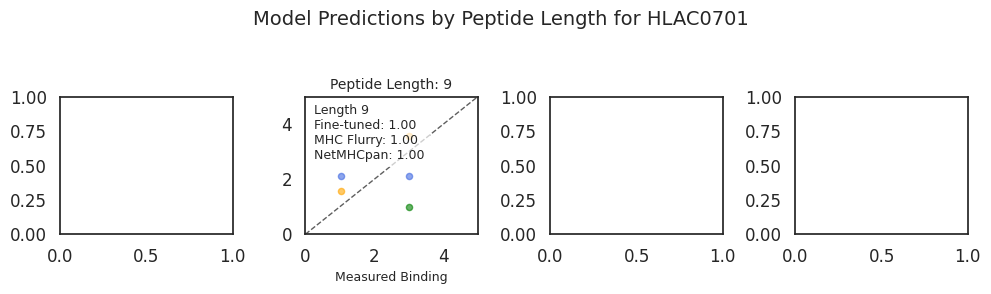

In [ ]:
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

for HLA in merged_dfs_by_HLA.keys():
    predictions = merged_dfs_by_HLA[HLA]
    predictions['length'] = predictions['sequence'].str.len()
    
    fig, axes = plt.subplots(1, 4, figsize=(10, 3), sharex=False, sharey=False)  # Slightly wider figure for 3 models
    
    # Loop over the four peptide lengths.
    for idx, L in enumerate([8, 9, 10, 11]):
        ax = axes[idx]
        preds_length = predictions[predictions['length'] == L]

        if len(preds_length) < 2:
            continue

        if preds_length.empty:
            ax.text(0.5, 0.5, f"No data for length {L}", ha='center', va='center')
            ax.set_title(f"Length {L}")
            continue
            
        if 'mhc_log' not in preds_length.columns:
            continue
        if 'netmhc_log' not in preds_length.columns:
            continue
        
        # Fine-tuned predictions
        ax.scatter(preds_length['measured'], preds_length['prediction'], 
                   color='royalblue', alpha=0.6, s=20, label='Fine-tuned')
        # MHC Flurry predictions (log-transformed)
        ax.scatter(preds_length['measured'], preds_length['mhc_log'], 
                   color='orange', alpha=0.6, s=20, label='MHC Flurry')
        # NetMHCpan predictions (log-transformed)
        ax.scatter(preds_length['measured'], preds_length['netmhc_log'], 
                   color='green', alpha=0.6, s=20, label='NetMHCpan')
        
        # Determine common limits for the x=y line.
        all_vals = np.concatenate([
            preds_length['measured'].values, 
            preds_length['prediction'].values,
            preds_length['mhc_log'].values,
            preds_length['netmhc_log'].values
        ])
        min_val, max_val = np.min(all_vals), np.max(all_vals)
        pad = (max_val - min_val) * 0.05
        lims = [min_val - pad, max_val + pad]
        ax.plot([0, 5], [0, 5], 'k--', alpha=0.7, lw=1)
        ax.set_xlim([0, 5])
        ax.set_ylim([0, 5])
        
        preds_length = preds_length[preds_length['mhc_log'].notna()]
        preds_length = preds_length[preds_length['netmhc_log'].notna()]

        # Compute Spearman correlations for each model.
        sp_finetuned, _ = pearsonr(preds_length['measured'], preds_length['prediction'])
        sp_mhc, _       = pearsonr(preds_length['measured'], preds_length['mhc_log'])
        sp_netmhc, _    = pearsonr(preds_length['measured'], preds_length['netmhc_log'])
        
        # Annotate the panel with Spearman correlation values.
        annotation = (f"Length {L}\n"
                      f"Fine-tuned: {sp_finetuned:.2f}\n"
                      f"MHC Flurry: {sp_mhc:.2f}\n"
                      f"NetMHCpan: {sp_netmhc:.2f}")
        ax.text(0.05, 0.95, annotation, transform=ax.transAxes,
                verticalalignment='top', fontsize=9,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        
        ax.set_title(f"Peptide Length: {L}", fontsize=10)
        if idx == 0:
            ax.set_ylabel("Predicted Binding", fontsize=9)
        ax.set_xlabel("Measured Binding", fontsize=9)
        if idx == 0:
            ax.legend(fontsize=8)
    
    fig.suptitle(f"Model Predictions by Peptide Length for {HLA}", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    # Save the figure with the HLA name in the specified folder.
    save_path = f'/global/scratch/users/sergiomar10/data/figures_presentation/{HLA}.png'
    # plt.savefig(save_path, dpi=300)
    # plt.close(fig)
    plt.show()

In [ ]:
combined_df = pd.concat(merged_dfs_by_HLA.values(), ignore_index=True)
combined_df.to_csv("../../performances/predictions_of_models.csv", index=False)

### Qualitative peptides benchmark

In [ ]:
IEDB_full = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/mhc_ligand_table_export_1727815227.tsv', sep = '\t', header = 0)
IEDB_full.head()

/tmp/ipykernel_982737/1962146925.py:1: DtypeWarning: Columns (6,12,13,14,19,20,21,22,23,24,25,26,27,28,29,30,34,35,36,37,38,39,40,41,42,45,46,47,48,49,50,51,52,53,54,55,56,57,60,61,62,63,64,65,66,67,68,70,71,72,73,74,75,76,79,80,81,82,83,84,85,86,87,88,89,92,95,100,101,102,103,104,105,106,109,110) have mixed types. Specify dtype option on import or set low_memory=False.
  IEDB_full = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/mhc_ligand_table_export_1727815227.tsv', sep = '\t', header = 0)


,Assay ID - IEDB IRI,Reference - IEDB IRI,Reference - Type,Reference - PMID,Reference - Submission ID,Reference - Authors,Reference - Journal,Reference - Date,Reference - Title,Epitope - Epitope IRI,...,Antigen Presenting Cell - Source Tissue,Antigen Presenting Cell - Source Tissue IRI,Antigen Presenting Cell - Name,Antigen Presenting Cell - IRI,Antigen Presenting Cell - Culture Condition,MHC Restriction - Name,MHC Restriction - IRI,MHC Restriction - Evidence Code,MHC Restriction - Evidence IRI,MHC Restriction - Class
0,http://www.iedb.org/assay/26,http://www.iedb.org/reference/274,Literature,15448372.0,NaN,Yi-Hsiang Huang; Mi-Hua Tao; Cheng-Po Hu; Wan-...,J Gen Virol,2004,Identification of novel HLA-A*0201-restricted ...,http://www.iedb.org/epitope/31803,...,NaN,NaN,NaN,NaN,NaN,HLA-A*02:01,http://purl.obolibrary.org/obo/MRO_0001007,NaN,NaN,I
1,http://www.iedb.org/assay/115,http://www.iedb.org/reference/299,Literature,15140958.0,NaN,Yue-Dan Wang; Wan-Yee Fion Sin; Guo-Bing Xu; H...,J Virol,2004,T-cell epitopes in severe acute respiratory sy...,http://www.iedb.org/epitope/36724,...,NaN,NaN,NaN,NaN,NaN,HLA-A2,http://purl.obolibrary.org/obo/MRO_0001530,NaN,NaN,I
2,http://www.iedb.org/assay/143,http://www.iedb.org/reference/304,Literature,15102821.0,NaN,Alberto Diaz-Quiñonez; Natalia Martin-Orozco; ...,Infect Immun,2004,Two Salmonella OmpC K(b)-restricted epitopes f...,http://www.iedb.org/epitope/66114,...,NaN,NaN,NaN,NaN,NaN,H2-Kb,http://purl.obolibrary.org/obo/MRO_0000991,NaN,NaN,I
3,http://www.iedb.org/assay/144,http://www.iedb.org/reference/304,Literature,15102821.0,NaN,Alberto Diaz-Quiñonez; Natalia Martin-Orozco; ...,Infect Immun,2004,Two Salmonella OmpC K(b)-restricted epitopes f...,http://www.iedb.org/epitope/55063,...,NaN,NaN,NaN,NaN,NaN,H2-Kb,http://purl.obolibrary.org/obo/MRO_0000991,NaN,NaN,I
4,http://www.iedb.org/assay/247,http://www.iedb.org/reference/329,Literature,15104671.0,NaN,C Sylvester-Hvid; M Nielsen; K Lamberth; G Rød...,Tissue Antigens,2004,"SARS CTL vaccine candidates; HLA supertype-, g...",http://www.iedb.org/epitope/14829,...,NaN,NaN,NaN,NaN,NaN,HLA-A*03:01,http://purl.obolibrary.org/obo/MRO_0001026,NaN,NaN,I


In [ ]:
pd.set_option('display.max_columns', None)  # Show all columns

In [ ]:
IEDB_full_subset = IEDB_full[IEDB_full['MHC Restriction - Name'] == 'HLA-A*02:01']
IEDB_full_subset[IEDB_full_subset['Assay - Method'].str.contains('mass spec')].head()

,Assay ID - IEDB IRI,Reference - IEDB IRI,Reference - Type,Reference - PMID,Reference - Submission ID,Reference - Authors,Reference - Journal,Reference - Date,Reference - Title,Epitope - Epitope IRI,Epitope - Object Type,Epitope - Name,Epitope - Reference Name,Epitope - Modified residues,Epitope - Modifications,Epitope - Starting Position,Epitope - Ending Position,Epitope - IRI,Epitope - Synonyms,Epitope - Source Molecule,Epitope - Source Molecule IRI,Epitope - Molecule Parent,Epitope - Molecule Parent IRI,Epitope - Source Organism,Epitope - Source Organism IRI,Epitope - Species,Epitope - Species IRI,Epitope - Comments,Related Object - Epitope Relation,Related Object - Object Type,Related Object - Name,Related Object - Starting Position,Related Object - Ending Position,Related Object - IRI,Related Object - Synonyms,Related Object - Source Molecule,Related Object - Source Molecule IRI,Related Object - Molecule Parent,Related Object - Molecule Parent IRI,Related Object - Source Organism,Related Object - Source Organism IRI,Related Object - Species,Related Object - Species IRI,Host - Name,Host - IRI,Host - Geolocation,Host - Geolocation IRI,Host - Sex,Host - Age,Host - MHC Types Present,in vivo Process - Process Type,in vivo Process - Disease,in vivo Process - Disease IRI,in vivo Process - Disease Stage,in vivo Antigen - Epitope Relation,in vivo Antigen - Object Type,in vivo Antigen - Name,in vivo Antigen - Reference Name,in vivo Antigen - Starting Position,in vivo Antigen - Ending Position,in vivo Antigen - IRI,in vivo Antigen - Source Molecule,in vivo Antigen - Source Molecule IRI,in vivo Antigen - Molecule Parent,in vivo Antigen - Molecule Parent IRI,in vivo Antigen - Source Organism,in vivo Antigen - Source Organism IRI,in vivo Antigen - Species,in vivo Antigen - Species IRI,in vivo Antigen - Adjuvants,in vivo Antigen - Route,in vivo Antigen - Dose Schedule,In vitro Process - Process Type,In vitro Process - Epitope Relation,In vitro Process - Object Type,In vitro Process - Name,In vitro Process - Reference Name,In vitro Process - Starting Position,In vitro Process - Ending Position,In vitro Process - IRI,In vitro Process - Source Molecule,In vitro Process - Source Molecule IRI,In vitro Process - Molecule Parent,In vitro Process - Molecule Parent IRI,In vitro Process - Source Organism,In vitro Process - Source Organism IRI,In vitro Process - Species,In vitro Process - Species IRI,Antigen Processing - Comments,Assay - Location of Assay Data in Reference,Assay - Method,Assay - Response measured,Assay - Units,Assay - IRI,Assay - Qualitative Measurement,Assay - Measurement Inequality,Assay - Quantitative measurement,Assay - Number of Subjects Tested,Assay - Number of Subjects Responded,Assay - Response Frequency (%),Assay - PDB ID,Assay - Comments,Antigen Presenting Cell - Source Tissue,Antigen Presenting Cell - Source Tissue IRI,Antigen Presenting Cell - Name,Antigen Presenting Cell - IRI,Antigen Presenting Cell - Culture Condition,MHC Restriction - Name,MHC Restriction - IRI,MHC Restriction - Evidence Code,MHC Restriction - Evidence IRI,MHC Restriction - Class
66,http://www.iedb.org/assay/635,http://www.iedb.org/reference/386,Literature,15116427.0,NaN,G Kageyama; S Kawano; S Kanagawa; S Kondo; M S...,Rapid Commun Mass Spectrom,2004,Effect of mutated transporters associated with...,http://www.iedb.org/epitope/37183,Linear peptide,LLDVTAAV,LLDVTAAV,NaN,NaN,NaN,NaN,NaN,NaN,"interferon, gamma-inducible protein",https://ontology.iedb.org/ontology/ONTIE_0002212,Gamma-interferon-inducible lysosomal thiol red...,http://www.uniprot.org/uniprot/P13284,Homo sapiens,http://purl.obolibrary.org/obo/NCBITaxon_9606,Homo sapiens,http://purl.obolibrary.org/obo/NCBITaxon_9606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Homo sapiens (human),http://purl.obolibrary.org/obo/NCBITaxon_9606,NaN,NaN,NaN,NaN,NaN,No immunization,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [ ]:
IEDB_test = IEDB_full[IEDB_full['MHC Restriction - Name'] == 'HLA-A*02:01']

In [ ]:
# IEDB_test[~IEDB_test['Epitope - Name'].isin(epitope_data['0'])]

In [ ]:
IEDB_full_subset[IEDB_full_subset['Assay - Method'].str.contains('fluorescence')]['Assay - Qualitative Measurement'].value_counts()

Assay - Qualitative Measurement
Negative                 7770
Positive                 4759
Positive-High            1280
Positive-Low              883
Positive-Intermediate     677
Name: count, dtype: int64

In [ ]:
IEDB_full_subset[IEDB_full_subset['Assay - Method'].str.contains('mass spectrometry')]['Assay - Qualitative Measurement'].value_counts()

Assay - Qualitative Measurement
Positive         170437
Negative             80
Positive-Low          7
Positive-High         1
Name: count, dtype: int64

In [ ]:
flank = "**********"

hla_apollo_test = pd.DataFrame(columns=['HLA', 'peptide', 'n_flank', 'c_flank']) 
    
for HLA in combined_df['HLA'].unique():
    formatted_HLA = HLA[0] + '*' + HLA[1:3] + ':' + HLA[3:]
    # print(formatted_HLA)

    peptides = combined_df[combined_df['HLA'] == HLA]['sequence'].unique()

    #make new dataframe with formatted HLA and peptides
    hla_apollo_test = pd.concat([hla_apollo_test, pd.DataFrame({
        'HLA': [formatted_HLA] * len(peptides),
        'peptide': [p  for p in peptides]
    })], ignore_index=True)

    hla_apollo_test['n_flank'] = flank
    hla_apollo_test['c_flank'] = flank

hla_apollo_test.to_csv(f'/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/data/HLA_APOLLO/HLA_APOLLO_TEST_final.csv', index=False)

print("HLA APOLLO test files created successfully!")

HLA APOLLO test files created successfully!


In [ ]:
hla_results = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/data/SENSITIVIYTYH_HLAPOLLO.csv')
hla_results

#z-score the vallues from mhc_pred_0 

hla_results['z_score'] = (hla_results['mhc_pred_0'] - hla_results['mhc_pred_0'].mean()) / hla_results['mhc_pred_0'].std()
hla_results['z_score']  = hla_results['z_score']  * -1

hlathena = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/data/predictions_20250527.072827.tsv',  sep='\t', header=0)
hlathena.head()

In [ ]:
hla_results = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/data/SENSITIVIYTYH_HLAPOLLO.csv')
hla_results

#z-score the vallues from mhc_pred_0 

hla_results['z_score'] = (hla_results['mhc_pred_0'] - hla_results['mhc_pred_0'].mean()) / hla_results['mhc_pred_0'].std()
hla_results['z_score']  = hla_results['z_score']  * -1

hlathena = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/data/predictions_20250527.072827.tsv',  sep='\t', header=0)
hlathena.head()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the HLA types
hla_list = ['HLA-A*03:01', 'HLA-A*11:01', 'HLA-A*24:02', 'HLA-A*02:01']

# List to store the processed data for each HLA type
all_data = []

# Loop through each HLA type to process the data
for hla in hla_list:
    # Clean the HLA name for column matching
    hla_clean = hla.replace('*', '').replace(':', '').replace('HLA-', '')

    # Subset the IEDB data for the current HLA
    IEDB_full_subset = IEDB_full[IEDB_full['MHC Restriction - Name'] == hla]
    IEDB_full_subset = IEDB_full_subset[['Epitope - Name', 'Assay - Qualitative Measurement']]
    labeled_combined = pd.merge(
        left=combined_df[combined_df['HLA'] == hla_clean],
        right=IEDB_full_subset,
        left_on='sequence',
        right_on='Epitope - Name'
    )

    # Merge with hla_results for z_score
    labeled_combined = pd.merge(
        left=labeled_combined,
        right=hla_results[['peptide', 'z_score']],
        left_on='sequence',
        right_on='peptide',
        how='left'
    )

    # Process HLAthena data and compute standardized scores
    filtered_hlathena = hlathena[['pep', f'MSi_{hla_clean}']]
    filtered_hlathena[f'MSi_{hla_clean}'] = (
        (filtered_hlathena[f'MSi_{hla_clean}'] - filtered_hlathena[f'MSi_{hla_clean}'].mean()) /
        filtered_hlathena[f'MSi_{hla_clean}'].std()
    )
    filtered_hlathena[f'MSi_{hla_clean}'] = filtered_hlathena[f'MSi_{hla_clean}'] * -1

    # Merge HLAthena data with labeled_combined
    labeled_combined = pd.merge(
        left=labeled_combined,
        right=filtered_hlathena[['pep', f'MSi_{hla_clean}']],
        left_on='sequence',
        right_on='pep',
        how='left'
    )

    # Remove duplicates
    labeled_combined = labeled_combined.drop_duplicates(subset=['sequence'])

    # Melt the dataframe for plotting
    df_melted = pd.melt(
        labeled_combined,
        id_vars=['Assay - Qualitative Measurement'],
        value_vars=['prediction', 'mhc_log', 'netmhc_log', 'z_score', f'MSi_{hla_clean}'],
        var_name='Measurement Type',
        value_name='Score'
    )

    # Append to the list of data
    all_data.append(df_melted)

# Concatenate all data into a single DataFrame
combined_data = pd.concat(all_data, ignore_index=True)

# Map the measurement types to their display names, standardizing MSi_ as HLA_Athena
measurement_mapping = {
    'prediction': 'ESMCBA',
    'mhc_log': 'MHC Flurry',
    'netmhc_log': 'NetMHCspan',
    'z_score': 'HLA-Apollo'
}
# Replace measurement types, and handle MSi_ columns dynamically
combined_data['Measurement Type'] = combined_data['Measurement Type'].apply(
    lambda x: 'HLA_Athena' if x.startswith('MSi_') else measurement_mapping.get(x, x)
)

# Define the desired order for qualitative measurements
qualitative_order = ['Negative', 'Positive', 'Positive-Low', 'Positive-Intermediate', 'Positive-High']

# Ensure the Assay - Qualitative Measurement column follows the specified order
combined_data['Assay - Qualitative Measurement'] = pd.Categorical(
    combined_data['Assay - Qualitative Measurement'],
    categories=qualitative_order,
    ordered=True
)

# Create a single violin plot
plt.figure(figsize=(8,6))
sns.violinplot(
    data=combined_data,
    x='Measurement Type',
    y='Score',
    hue='Assay - Qualitative Measurement',
    hue_order=qualitative_order,  # Explicitly set the hue order
    split=False,
    palette='Set1',
    dodge=True,  # Separate violins for each hue category
    inner='quartile'  # Show quartiles inside the violins
)

# Add a title
# plt.title("Predictions with Qualitative Labels for All HLA Types", fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, size = 10)
plt.yticks(size=10)
plt.ylabel('Score', size=15)
plt.xlabel('')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
# ##S$ave the figure with the HLA name in the specified folder (uncomment to use)
out_dir = Path('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures_manuscript/')
out_dir.mkdir(parents=True, exist_ok=True)      
save_path = out_dir / f"fig2_sensitivity.pdf"
fig = plt.gcf()
fig.savefig(save_path, dpi=300, bbox_inches="tight")
plt.close(fig)

plt.show()

/tmp/ipykernel_982737/1356060506.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hlathena[f'MSi_{hla_clean}'] = (
/tmp/ipykernel_982737/1356060506.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hlathena[f'MSi_{hla_clean}'] = filtered_hlathena[f'MSi_{hla_clean}'] * -1
/tmp/ipykernel_982737/1356060506.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the doc

/tmp/ipykernel_863486/3304754044.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hlathena[f'MSi_{hla_clean}'] =  (filtered_hlathena[f'MSi_{hla_clean}'] - filtered_hlathena[f'MSi_{hla_clean}'].mean()) / filtered_hlathena[f'MSi_{hla_clean}'].std()
/tmp/ipykernel_863486/3304754044.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hlathena[f'MSi_{hla_clean}'] =  filtered_hlathena[f'MSi_{hla_clean}'] * - 1


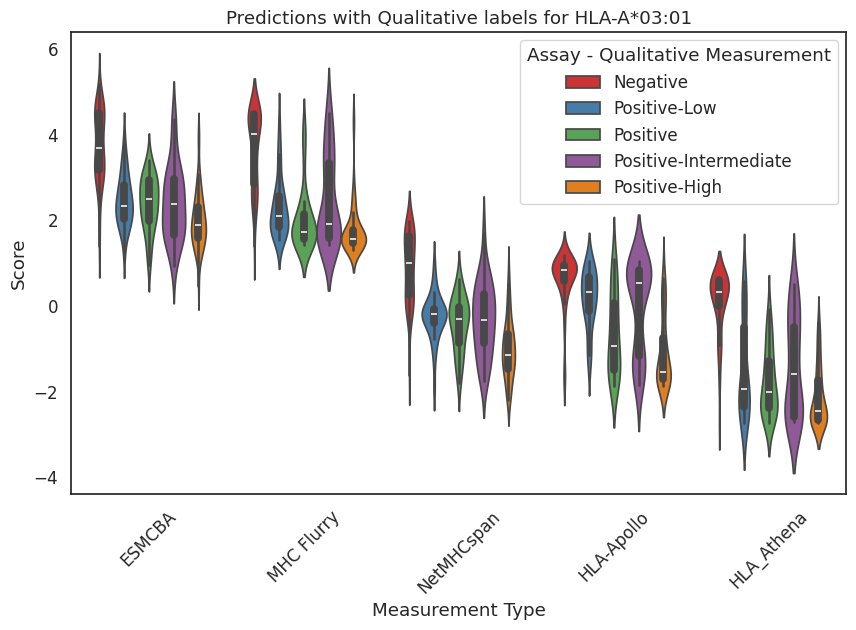

/tmp/ipykernel_863486/3304754044.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hlathena[f'MSi_{hla_clean}'] =  (filtered_hlathena[f'MSi_{hla_clean}'] - filtered_hlathena[f'MSi_{hla_clean}'].mean()) / filtered_hlathena[f'MSi_{hla_clean}'].std()
/tmp/ipykernel_863486/3304754044.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hlathena[f'MSi_{hla_clean}'] =  filtered_hlathena[f'MSi_{hla_clean}'] * - 1


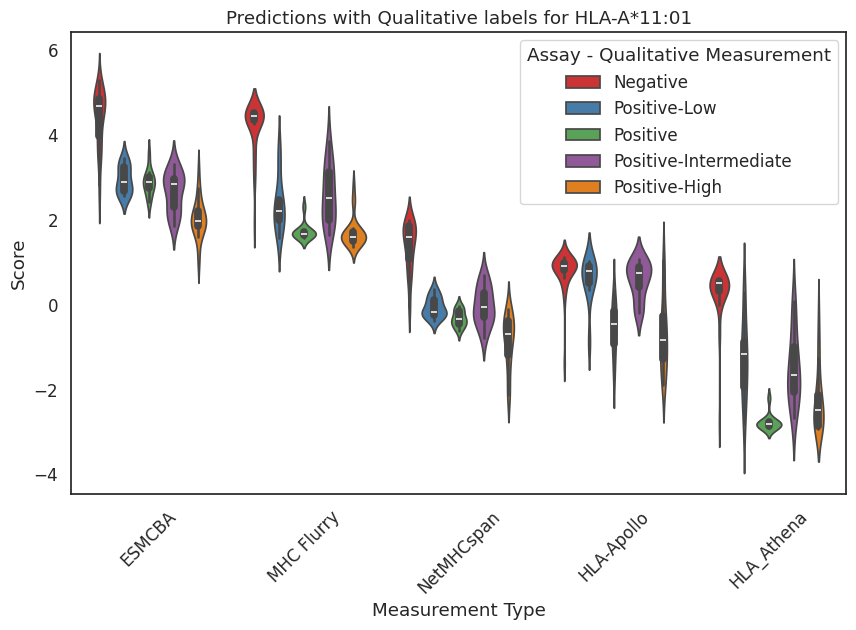

/tmp/ipykernel_863486/3304754044.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hlathena[f'MSi_{hla_clean}'] =  (filtered_hlathena[f'MSi_{hla_clean}'] - filtered_hlathena[f'MSi_{hla_clean}'].mean()) / filtered_hlathena[f'MSi_{hla_clean}'].std()
/tmp/ipykernel_863486/3304754044.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hlathena[f'MSi_{hla_clean}'] =  filtered_hlathena[f'MSi_{hla_clean}'] * - 1


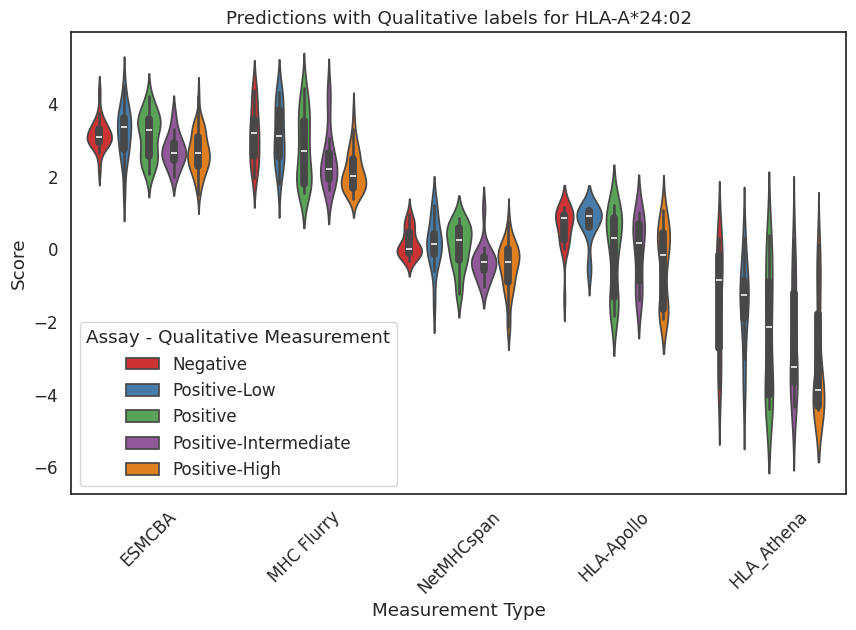

/tmp/ipykernel_863486/3304754044.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hlathena[f'MSi_{hla_clean}'] =  (filtered_hlathena[f'MSi_{hla_clean}'] - filtered_hlathena[f'MSi_{hla_clean}'].mean()) / filtered_hlathena[f'MSi_{hla_clean}'].std()
/tmp/ipykernel_863486/3304754044.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hlathena[f'MSi_{hla_clean}'] =  filtered_hlathena[f'MSi_{hla_clean}'] * - 1


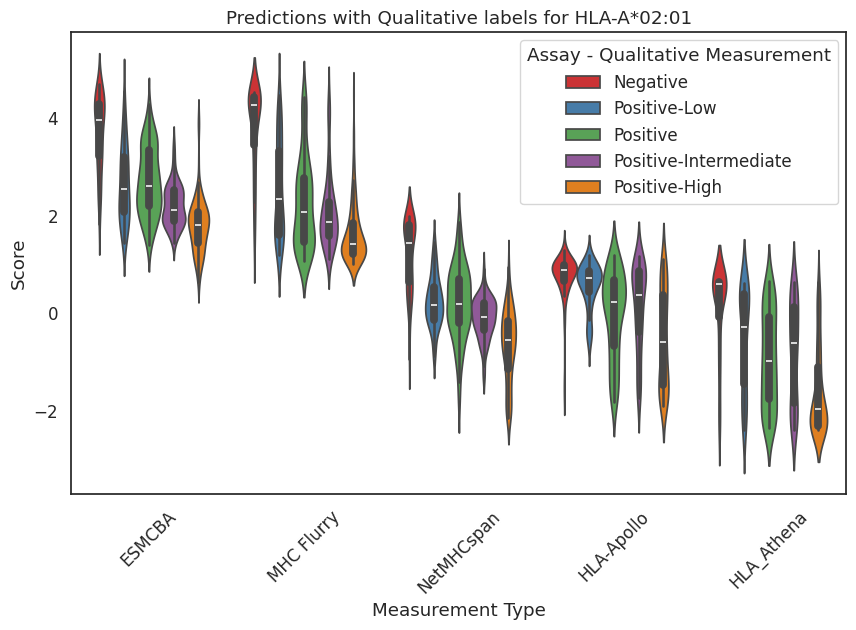

In [ ]:
for hla in [ 'HLA-A*03:01', 'HLA-A*11:01', 'HLA-A*24:02','HLA-A*02:01']:

    hla_clean = hla.replace('*', '').replace(':', '').replace('HLA-', '')

    IEDB_full_subset = IEDB_full[IEDB_full['MHC Restriction - Name'] == hla]
    IEDB_full_subset = IEDB_full_subset[['Epitope - Name', 'Assay - Qualitative Measurement']]
    labeled_combined = pd.merge(left = combined_df[combined_df['HLA'] == hla_clean], right = IEDB_full_subset, left_on='sequence', right_on ='Epitope - Name')

    # Compute the Z scores per HLA 
    # hla_results_subset = hla_results['z_score'] = (hla_results['mhc_pred_0'] - hla_results['mhc_pred_0'].mean()) / hla_results['mhc_pred_0'].std()
    # hla_results_subset['z_score']  = hla_results['z_score']  * -1

    labeled_combined = pd.merge(
        left=labeled_combined,
        right=hla_results[['peptide', 'z_score']],
        left_on='sequence',
        right_on='peptide',
        how='left'
    )

    filtered_hlathena = hlathena[['pep',f'MSi_{hla_clean}']]
    
    filtered_hlathena[f'MSi_{hla_clean}'] =  (filtered_hlathena[f'MSi_{hla_clean}'] - filtered_hlathena[f'MSi_{hla_clean}'].mean()) / filtered_hlathena[f'MSi_{hla_clean}'].std()
    filtered_hlathena[f'MSi_{hla_clean}'] =  filtered_hlathena[f'MSi_{hla_clean}'] * - 1

    labeled_combined = pd.merge(
        left=labeled_combined,
        right=filtered_hlathena[['pep', f'MSi_{hla_clean}']],
        left_on='sequence',
        right_on='pep',
        how='left'
    )

    labeled_combined = labeled_combined.drop_duplicates(subset=['sequence'])

    df_melted = pd.melt(
        labeled_combined,
        id_vars=['Assay - Qualitative Measurement'],
        value_vars=['prediction', 'mhc_log', 'netmhc_log', 'z_score', f'MSi_{hla_clean}'],
        var_name='Measurement Type',
        value_name='Score'
    )

    # Create violinplot
    plt.figure(figsize=(10, 6))
    sns.violinplot(
        data=df_melted,
        x='Measurement Type',
        y='Score',
        hue='Assay - Qualitative Measurement',
        hue_order= ['Negative', 'Positive-Low', 'Positive', 'Positive-Intermediate', 'Positive-High'],
        split=False,  # optional: split violins if there are only 2 hue levels,
        palette='Set1' #or 
    )
    plt.xticks([0, 1, 2, 3, 4],labels=['ESMCBA', 'MHC Flurry', 'NetMHCspan',  'HLA-Apollo', 'HLA_Athena'], rotation=45)
    plt.title(f"Predictions with Qualitative labels for {hla}")
    plt.show()

/tmp/ipykernel_863486/579848039.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_863486/579848039.py:8: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


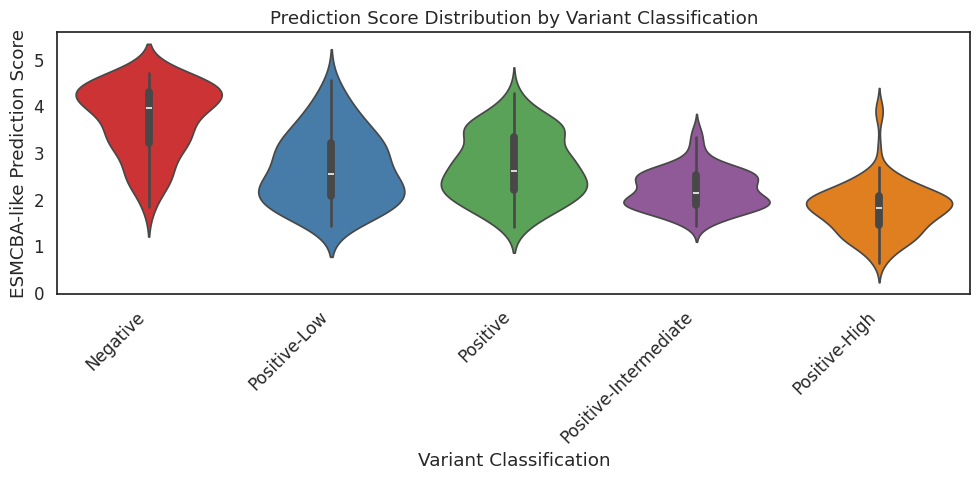

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [ ]:
df_filtered = df_melted[df_melted['Measurement Type'] == 'prediction']

# Sort assay classes if needed (optional: replace with actual desired order)
assay_order = ['Negative', 'Positive-Low', 'Positive', 'Positive-Intermediate', 'Positive-High']

# Plot
plt.figure(figsize=(10, 5))
sns.violinplot(
    data=df_filtered,
    x='Assay - Qualitative Measurement',
    y='Score',
    order=assay_order if set(assay_order).issubset(df_filtered['Assay - Qualitative Measurement'].unique()) else None,
    inner='box',
    scale='width',
    palette='Set1'
)

plt.xticks(rotation=45, ha='right')
plt.xlabel('Variant Classification')
plt.ylabel('ESMCBA-like Prediction Score')
plt.title('Prediction Score Distribution by Variant Classification')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

/tmp/ipykernel_863486/996514036.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hlathena[f'MSi_{hla_clean}'] =  (filtered_hlathena[f'MSi_{hla_clean}'] - filtered_hlathena[f'MSi_{hla_clean}'].mean()) / filtered_hlathena[f'MSi_{hla_clean}'].std()
/tmp/ipykernel_863486/996514036.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hlathena[f'MSi_{hla_clean}'] =  filtered_hlathena[f'MSi_{hla_clean}'] * - 1
/tmp/ipykernel_863486/996514036.py:36: SettingWithCopyWarning: 
A value is trying t

/tmp/ipykernel_863486/996514036.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hlathena[f'MSi_{hla_clean}'] =  (filtered_hlathena[f'MSi_{hla_clean}'] - filtered_hlathena[f'MSi_{hla_clean}'].mean()) / filtered_hlathena[f'MSi_{hla_clean}'].std()
/tmp/ipykernel_863486/996514036.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hlathena[f'MSi_{hla_clean}'] =  filtered_hlathena[f'MSi_{hla_clean}'] * - 1


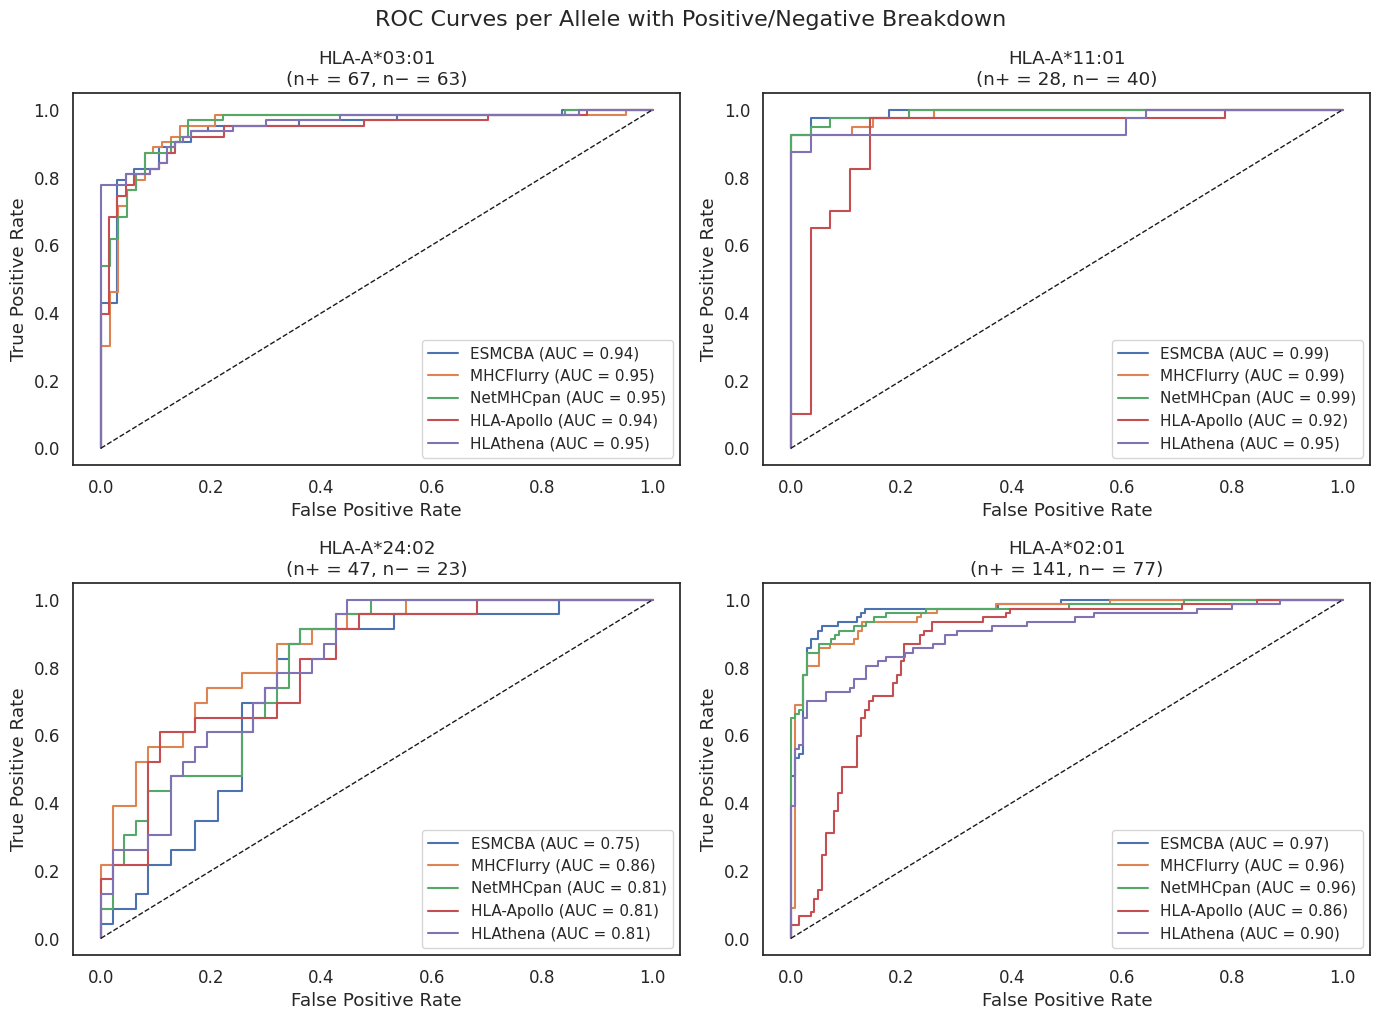

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

alleles = ['HLA-A*03:01', 'HLA-A*11:01', 'HLA-A*24:02', 'HLA-A*02:01']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, hla in enumerate(alleles):
    hla_clean = hla.replace('*', '').replace(':', '').replace('HLA-', '')

    IEDB_full_subset = IEDB_full[IEDB_full['MHC Restriction - Name'] == hla]
    IEDB_full_subset = IEDB_full_subset[['Epitope - Name', 'Assay - Qualitative Measurement']]
    
    # Merge with combined predictions
    labeled_combined = pd.merge(
        left=combined_df[combined_df['HLA'] == hla_clean],
        right=IEDB_full_subset,
        left_on='sequence',
        right_on='Epitope - Name'
    )
    
    # Add z_score (HLA-Apollo)
    labeled_combined = pd.merge(
        labeled_combined,
        hla_results[['peptide', 'z_score']],
        left_on='sequence',
        right_on='peptide',
        how='left'
    )
    

    filtered_hlathena = hlathena[['pep',f'MSi_{hla_clean}']]
    
    filtered_hlathena[f'MSi_{hla_clean}'] =  (filtered_hlathena[f'MSi_{hla_clean}'] - filtered_hlathena[f'MSi_{hla_clean}'].mean()) / filtered_hlathena[f'MSi_{hla_clean}'].std()
    filtered_hlathena[f'MSi_{hla_clean}'] =  filtered_hlathena[f'MSi_{hla_clean}'] * - 1


    labeled_combined = pd.merge(
        labeled_combined,
        filtered_hlathena[['pep', f'MSi_{hla_clean}']],
        left_on='sequence',
        right_on='pep',
        how='left'
    )

    # Binarize qualitative label: 1 = Negative, 0 = Positive
    labeled_combined = labeled_combined[labeled_combined['Assay - Qualitative Measurement'].str.contains('Positive-High|Negative')]

    labeled_combined['binary_label'] = labeled_combined['Assay - Qualitative Measurement'].str.contains('Negative').astype(int)

    labeled_combined = labeled_combined.drop_duplicates('sequence')
    
    # Count breakdown
    n_neg = labeled_combined['binary_label'].sum()
    n_pos = len(labeled_combined) - n_neg
    

    # Plot ROC curves
    ax = axes[idx]
    predictors = {
        'ESMCBA': labeled_combined['prediction'],
        'MHCFlurry': labeled_combined['mhc_log'],
        'NetMHCpan': labeled_combined['netmhc_log'],
        'HLA-Apollo': labeled_combined['z_score'],
        'HLAthena': labeled_combined[f'MSi_{hla_clean}']
    }

    for name, scores in predictors.items():
        valid = ~scores.isna()
        if valid.sum() > 0:
            fpr, tpr, _ = roc_curve(labeled_combined.loc[valid, 'binary_label'], scores[valid])
            auc_val = auc(fpr, tpr)
            ax.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.2f})")

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(f"{hla}\n(n+ = {n_pos}, n− = {n_neg})")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc='lower right', fontsize='small')

plt.tight_layout()
plt.suptitle("ROC Curves per Allele with Positive/Negative Breakdown", y=1.02, fontsize=16)
plt.show()


/tmp/ipykernel_863486/4009618248.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hlathena[f'MSi_{hla_clean}'] = (filtered_hlathena[f'MSi_{hla_clean}'] - filtered_hlathena[f'MSi_{hla_clean}'].mean()) / filtered_hlathena[f'MSi_{hla_clean}'].std()
/tmp/ipykernel_863486/4009618248.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hlathena[f'MSi_{hla_clean}'] *= -1


/tmp/ipykernel_863486/4009618248.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hlathena[f'MSi_{hla_clean}'] = (filtered_hlathena[f'MSi_{hla_clean}'] - filtered_hlathena[f'MSi_{hla_clean}'].mean()) / filtered_hlathena[f'MSi_{hla_clean}'].std()
/tmp/ipykernel_863486/4009618248.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hlathena[f'MSi_{hla_clean}'] *= -1
/tmp/ipykernel_863486/4009618248.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

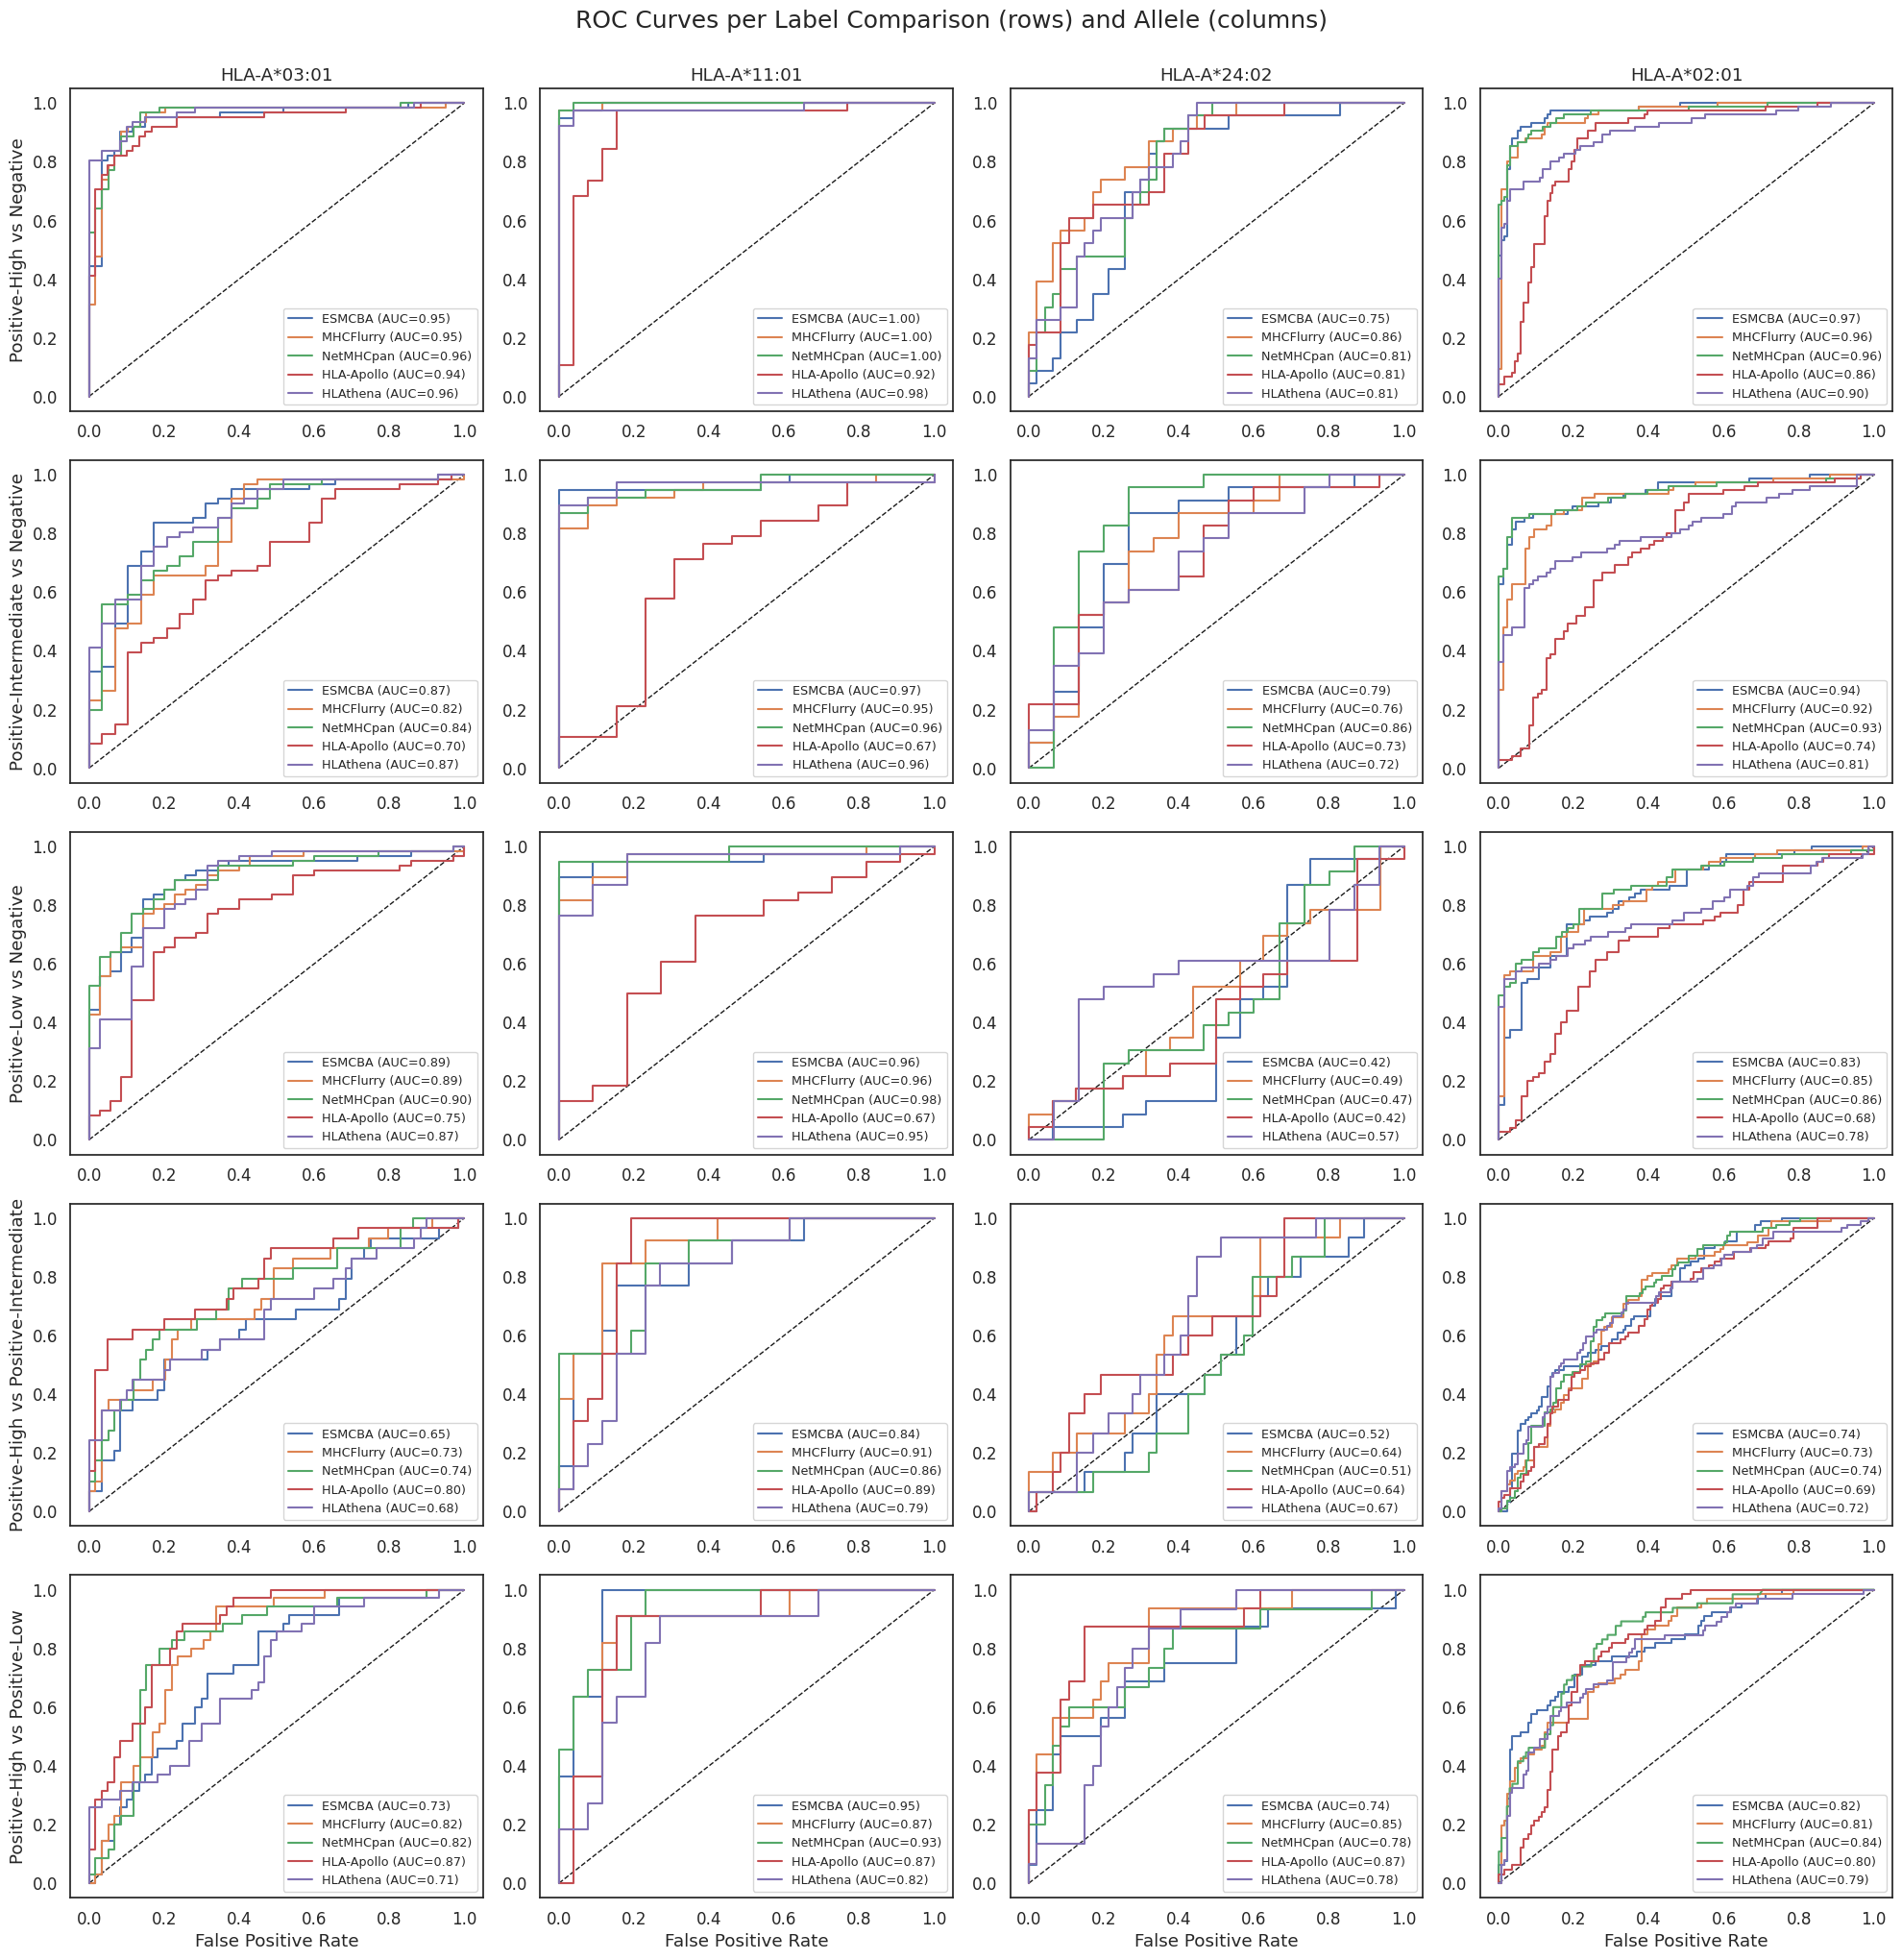

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

import numpy as np

roc_results = []

label_pairs = [
    ('Positive-High', 'Negative'),
    ('Positive-Intermediate', 'Negative'),
    ('Positive-Low', 'Negative'),
    ('Positive-High', 'Positive-Intermediate'),
    ('Positive-High', 'Positive-Low'),
]

alleles = ['HLA-A*03:01', 'HLA-A*11:01', 'HLA-A*24:02', 'HLA-A*02:01']
n_rows = len(label_pairs)
n_cols = len(alleles)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

for col_idx, hla in enumerate(alleles):
    hla_clean = hla.replace('*', '').replace(':', '').replace('HLA-', '')

    # Prepare and merge like before
    IEDB_full_subset = IEDB_full[IEDB_full['MHC Restriction - Name'] == hla]
    IEDB_full_subset = IEDB_full_subset[['Epitope - Name', 'Assay - Qualitative Measurement']]
    
    labeled_combined = pd.merge(
        left=combined_df[combined_df['HLA'] == hla_clean],
        right=IEDB_full_subset,
        left_on='sequence',
        right_on='Epitope - Name'
    )
    labeled_combined = pd.merge(
        labeled_combined,
        hla_results[['peptide', 'z_score']],
        left_on='sequence',
        right_on='peptide',
        how='left'
    )
    
    filtered_hlathena = hlathena[['pep', f'MSi_{hla_clean}']]
    filtered_hlathena[f'MSi_{hla_clean}'] = (filtered_hlathena[f'MSi_{hla_clean}'] - filtered_hlathena[f'MSi_{hla_clean}'].mean()) / filtered_hlathena[f'MSi_{hla_clean}'].std()
    filtered_hlathena[f'MSi_{hla_clean}'] *= -1

    labeled_combined = pd.merge(
        labeled_combined,
        filtered_hlathena[['pep', f'MSi_{hla_clean}']],
        left_on='sequence',
        right_on='pep',
        how='left'
    )

    labeled_combined = labeled_combined.drop_duplicates('sequence')
    labeled_combined = labeled_combined[labeled_combined['Assay - Qualitative Measurement'].notna()]

    predictors = {
        'ESMCBA': labeled_combined['prediction'],
        'MHCFlurry': labeled_combined['mhc_log'],
        'NetMHCpan': labeled_combined['netmhc_log'],
        'HLA-Apollo': labeled_combined['z_score'],
        'HLAthena': labeled_combined[f'MSi_{hla_clean}']
    }

    for row_idx, (pos_label, neg_label) in enumerate(label_pairs):
        ax = axes[row_idx][col_idx]
        ax.plot([0, 1], [0, 1], 'k--', lw=1)

        subset = labeled_combined[
            labeled_combined['Assay - Qualitative Measurement'].isin([pos_label, neg_label])
        ].copy()
        if subset.shape[0] < 10:
            ax.set_title(hla if row_idx == 0 else "")
            ax.set_xticks([]); ax.set_yticks([])
            ax.text(0.5, 0.5, "Too few peptides", ha='center', va='center', fontsize=10)
            continue

        y_true = (subset['Assay - Qualitative Measurement'] == neg_label).astype(int)

        for name, scores in predictors.items():
            valid = ~subset[scores.name].isna()
            if valid.sum() < 10:
                continue
            fpr, tpr, _ = roc_curve(y_true[valid], subset.loc[valid, scores.name])
            auc_val = auc(fpr, tpr)
            ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.2f})")

        if col_idx == 0:
            ax.set_ylabel(f"{pos_label} vs {neg_label}")
        if row_idx == 0:
            ax.set_title(hla)
        if row_idx == n_rows - 1:
            ax.set_xlabel("False Positive Rate")
        # if col_idx == n_cols - 1:
        ax.legend(loc='lower right', fontsize='x-small')
        
        roc_results.append({
    'Predictor': name,
    'LabelPair': f"{pos_label} vs {neg_label}",
    'Allele': hla,
    'AUC': auc_val
})


plt.tight_layout()
plt.suptitle("ROC Curves per Label Comparison (rows) and Allele (columns)", fontsize=18, y=1.02)
plt.show()


/tmp/ipykernel_863486/1225918681.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hlathena[f'MSi_{hla_clean}'] = (filtered_hlathena[f'MSi_{hla_clean}'] - filtered_hlathena[f'MSi_{hla_clean}'].mean()) / filtered_hlathena[f'MSi_{hla_clean}'].std()
/tmp/ipykernel_863486/1225918681.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hlathena[f'MSi_{hla_clean}'] *= -1
/tmp/ipykernel_863486/1225918681.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

/tmp/ipykernel_863486/1225918681.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hlathena[f'MSi_{hla_clean}'] = (filtered_hlathena[f'MSi_{hla_clean}'] - filtered_hlathena[f'MSi_{hla_clean}'].mean()) / filtered_hlathena[f'MSi_{hla_clean}'].std()
/tmp/ipykernel_863486/1225918681.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_hlathena[f'MSi_{hla_clean}'] *= -1
/tmp/ipykernel_863486/1225918681.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

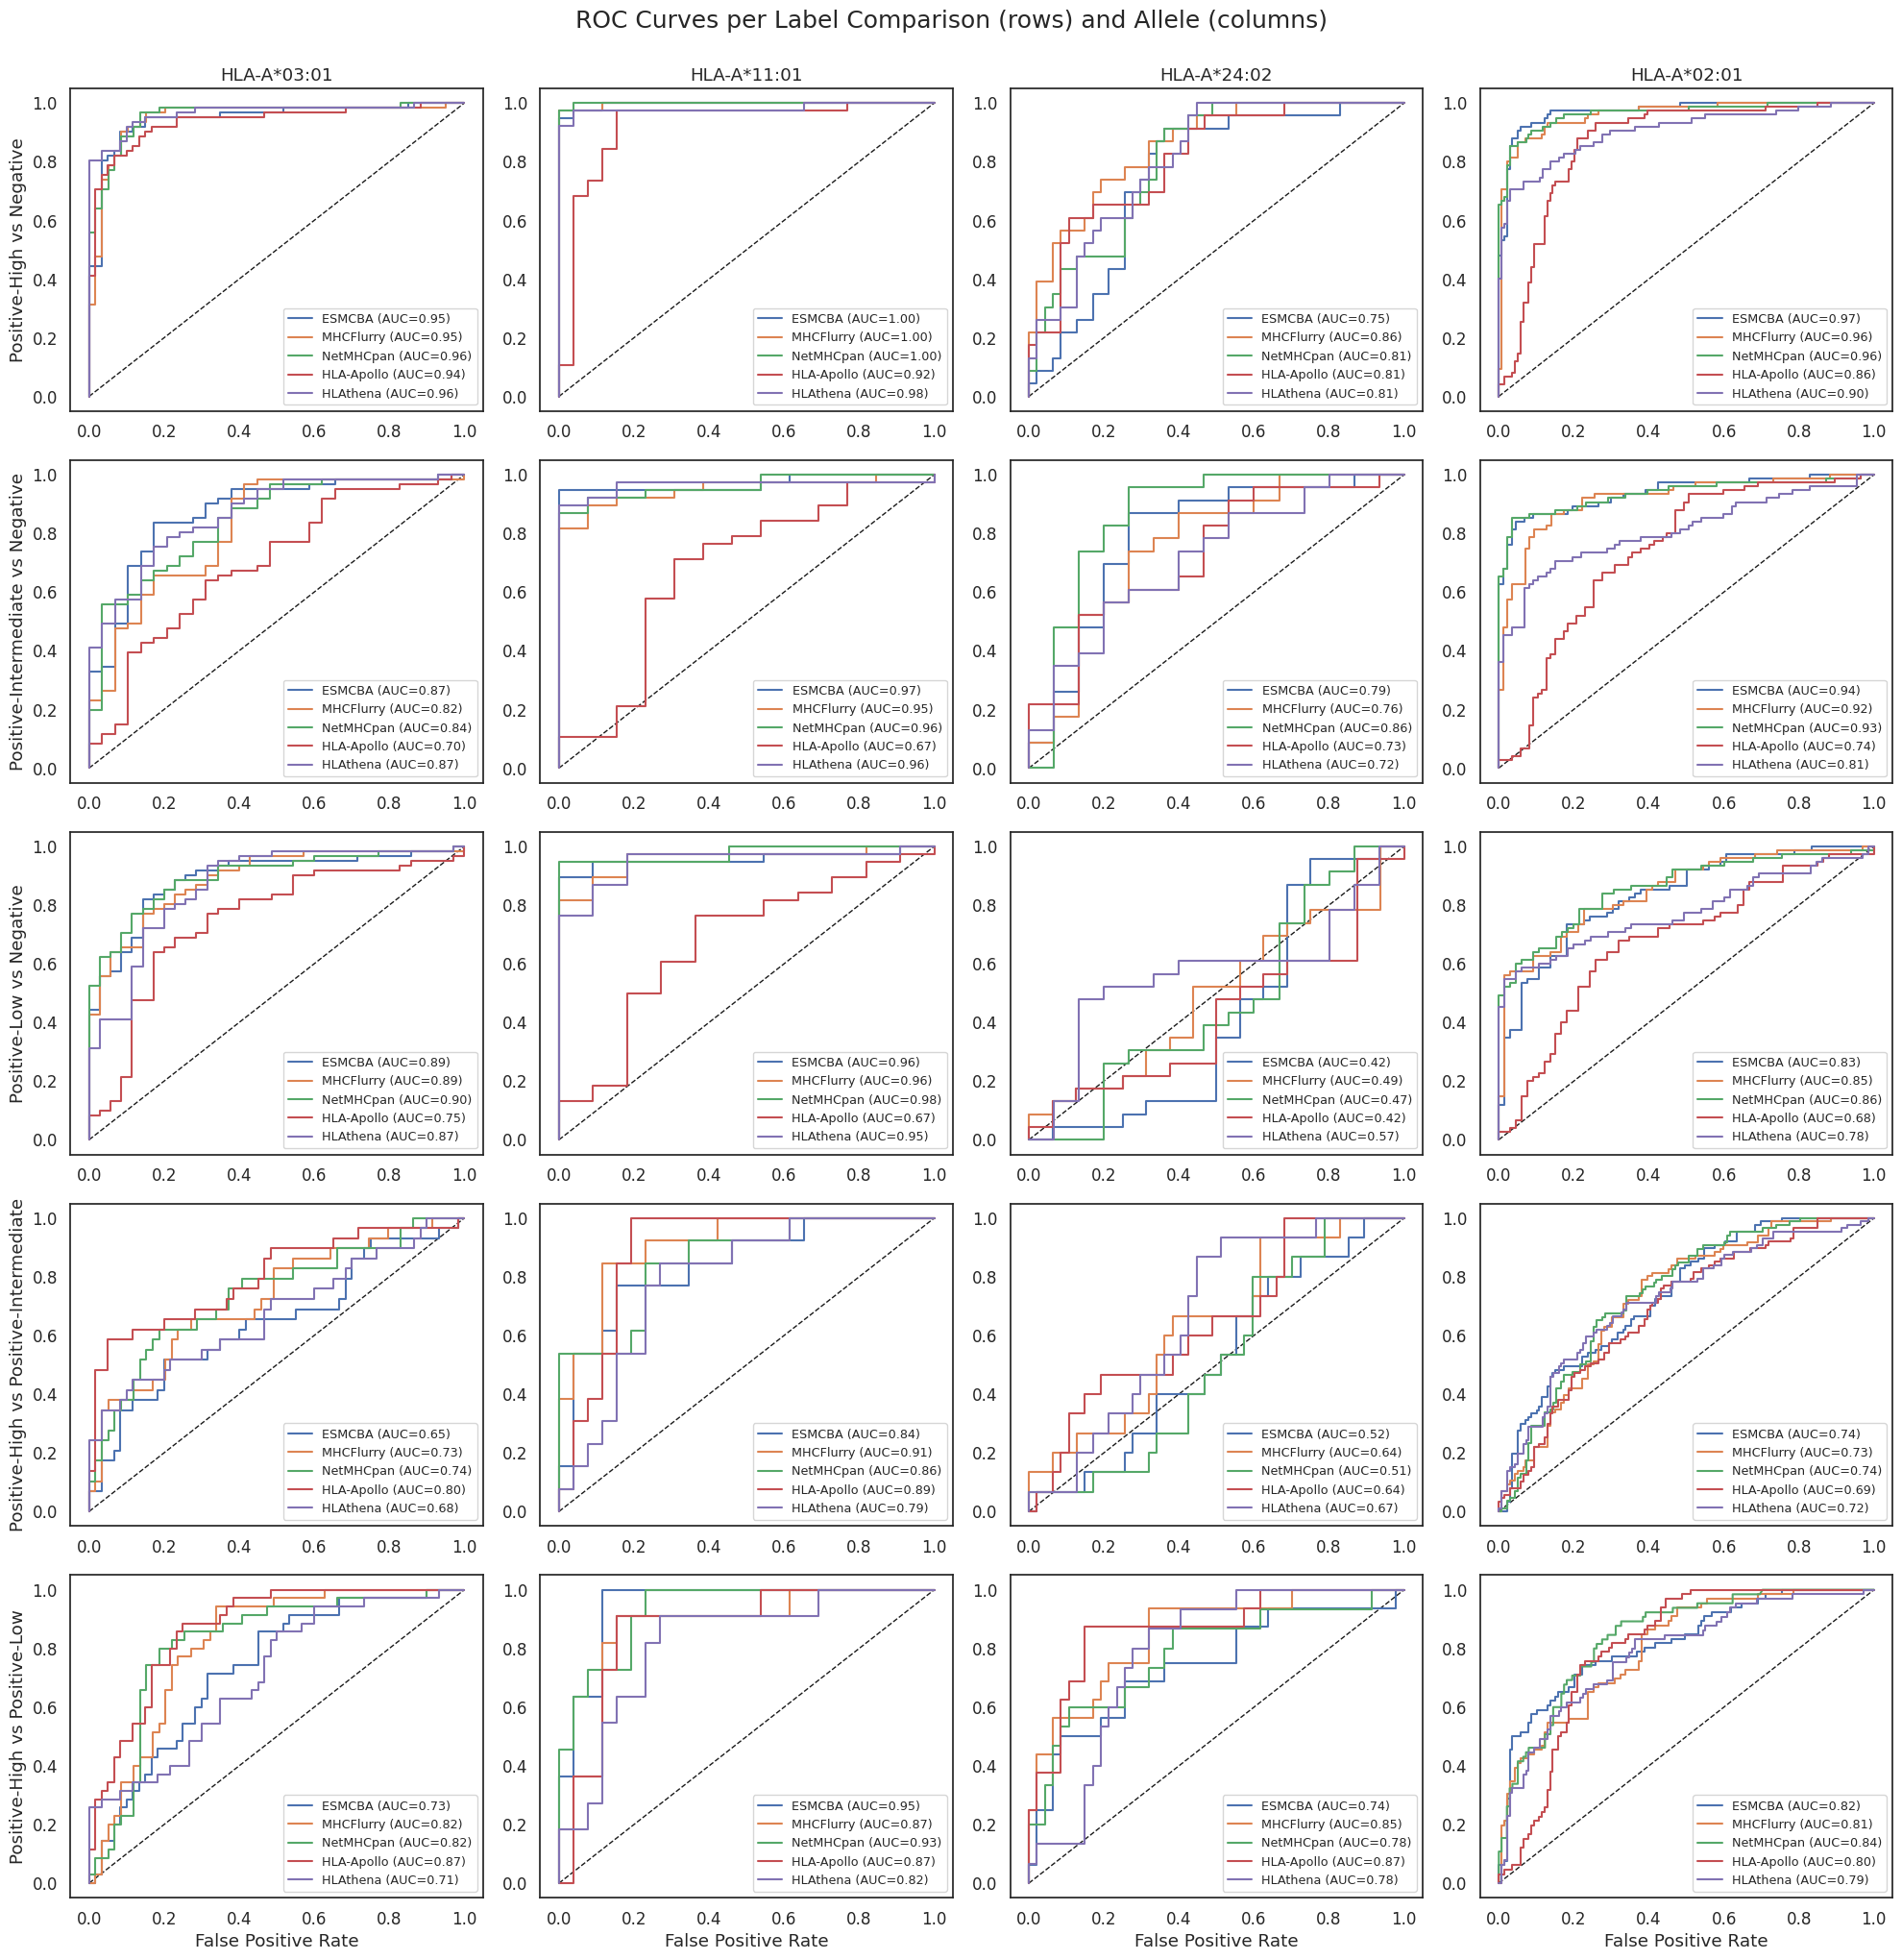

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

import numpy as np

roc_results = []

label_pairs = [
    ('Positive-High', 'Negative'),
    ('Positive-Intermediate', 'Negative'),
    ('Positive-Low', 'Negative'),
    ('Positive-High', 'Positive-Intermediate'),
    ('Positive-High', 'Positive-Low'),
]

alleles = ['HLA-A*03:01', 'HLA-A*11:01', 'HLA-A*24:02', 'HLA-A*02:01']
n_rows = len(label_pairs)
n_cols = len(alleles)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

for col_idx, hla in enumerate(alleles):
    hla_clean = hla.replace('*', '').replace(':', '').replace('HLA-', '')

    # Prepare and merge like before
    IEDB_full_subset = IEDB_full[IEDB_full['MHC Restriction - Name'] == hla]
    IEDB_full_subset = IEDB_full_subset[['Epitope - Name', 'Assay - Qualitative Measurement']]
    
    labeled_combined = pd.merge(
        left=combined_df[combined_df['HLA'] == hla_clean],
        right=IEDB_full_subset,
        left_on='sequence',
        right_on='Epitope - Name'
    )
    labeled_combined = pd.merge(
        labeled_combined,
        hla_results[['peptide', 'z_score']],
        left_on='sequence',
        right_on='peptide',
        how='left'
    )
    
    filtered_hlathena = hlathena[['pep', f'MSi_{hla_clean}']]
    filtered_hlathena[f'MSi_{hla_clean}'] = (filtered_hlathena[f'MSi_{hla_clean}'] - filtered_hlathena[f'MSi_{hla_clean}'].mean()) / filtered_hlathena[f'MSi_{hla_clean}'].std()
    filtered_hlathena[f'MSi_{hla_clean}'] *= -1

    labeled_combined = pd.merge(
        labeled_combined,
        filtered_hlathena[['pep', f'MSi_{hla_clean}']],
        left_on='sequence',
        right_on='pep',
        how='left'
    )

    labeled_combined = labeled_combined.drop_duplicates('sequence')
    labeled_combined = labeled_combined[labeled_combined['Assay - Qualitative Measurement'].notna()]

    predictors = {
        'ESMCBA': labeled_combined['prediction'],
        'MHCFlurry': labeled_combined['mhc_log'],
        'NetMHCpan': labeled_combined['netmhc_log'],
        'HLA-Apollo': labeled_combined['z_score'],
        'HLAthena': labeled_combined[f'MSi_{hla_clean}']
    }

    for row_idx, (pos_label, neg_label) in enumerate(label_pairs):
        ax = axes[row_idx][col_idx]
        ax.plot([0, 1], [0, 1], 'k--', lw=1)

        subset = labeled_combined[
            labeled_combined['Assay - Qualitative Measurement'].isin([pos_label, neg_label])
        ].copy()
        if subset.shape[0] < 10:
            ax.set_title(hla if row_idx == 0 else "")
            ax.set_xticks([]); ax.set_yticks([])
            ax.text(0.5, 0.5, "Too few peptides", ha='center', va='center', fontsize=10)
            continue

        y_true = (subset['Assay - Qualitative Measurement'] == neg_label).astype(int)

        for name, scores in predictors.items():
            valid = ~subset[scores.name].isna()
            if valid.sum() < 10:
                continue
            fpr, tpr, _ = roc_curve(y_true[valid], subset.loc[valid, scores.name])
            auc_val = auc(fpr, tpr)
            ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.2f})")
            roc_results.append({
    'Predictor': name,
    'LabelPair': f"{pos_label} vs {neg_label}",
    'Allele': hla,
    'AUC': auc_val
})

        if col_idx == 0:
            ax.set_ylabel(f"{pos_label} vs {neg_label}")
        if row_idx == 0:
            ax.set_title(hla)
        if row_idx == n_rows - 1:
            ax.set_xlabel("False Positive Rate")
        # if col_idx == n_cols - 1:
        ax.legend(loc='lower right', fontsize='x-small')
        


plt.tight_layout()
plt.suptitle("ROC Curves per Label Comparison (rows) and Allele (columns)", fontsize=18, y=1.02)
plt.show()

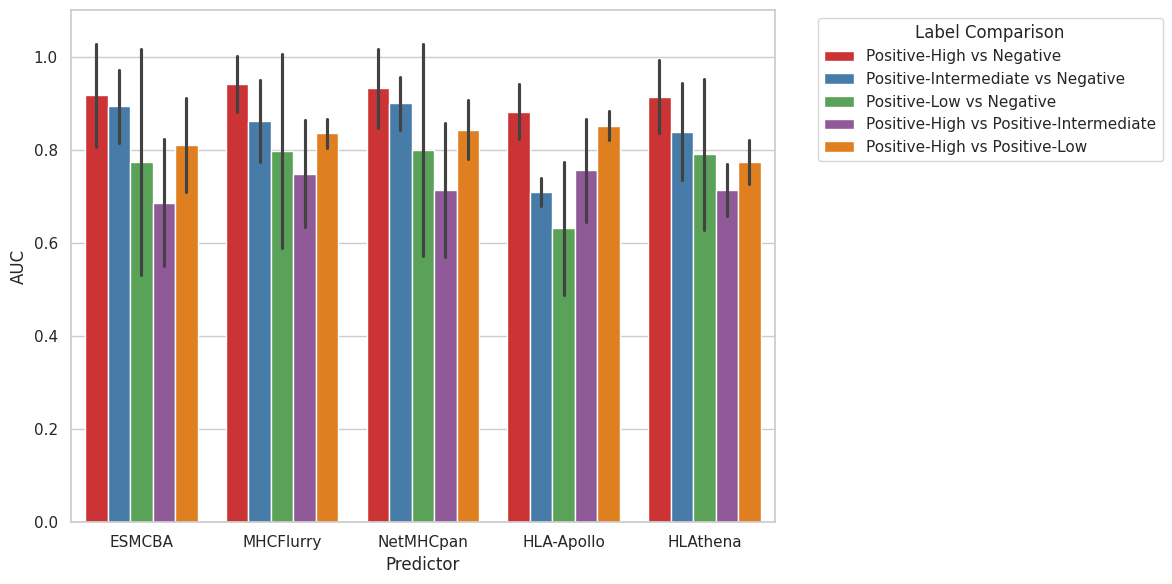

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to DataFrame
df_roc = pd.DataFrame(roc_results)

# Set plot style
sns.set(style="whitegrid")

# Plot mean AUCs with SD error bars per predictor per label pair
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_roc,
    x='Predictor',
    y='AUC',
    hue='LabelPair',
    errorbar='sd',
    palette='Set1',
)
# plt.title("Mean AUC per Predictor with Std Dev Across Alleles")
plt.ylabel("AUC")
plt.ylim(0, 1.1)
plt.legend(title="Label Comparison", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
